In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("./../data/clean_diamonds.br")
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
index,,,,,,,,,,,,,
0,1638147,CUSHION,0.549805,SI2,E,EX,EX,VG,N,1378.650024,5.050781,4.351562,2.939453
1,1630155,CUSHION,0.500000,VVS1,FANCY,EX,EX,VG,F,1379.739990,4.601562,4.308594,2.919922
2,1612606,CUSHION,0.509766,VS2,H,EX,EX,VG,N,1380.189941,4.710938,4.351562,2.939453
3,1638140,CUSHION,0.500000,VS2,H,EX,EX,VG,N,1380.609985,4.910156,4.261719,2.880859
4,1536093,CUSHION,0.529785,SI1,D,EX,VG,VG,N,1383.130005,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6332,1751206,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.000000,5.039062,3.179688
6333,1773024,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.031250,5.058594,3.160156
6336,1789435,ROUND,0.500000,VS2,D,VG,EX,VG,N,2453.199951,4.929688,4.960938,3.189453


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5991 entries, 0 to 6338
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Id            5991 non-null   object  
 1   Shape         5991 non-null   category
 2   Weight        5991 non-null   float32 
 3   Clarity       5991 non-null   category
 4   Colour        5991 non-null   category
 5   Cut           5991 non-null   category
 6   Polish        5991 non-null   category
 7   Symmetry      5991 non-null   category
 8   Fluorescence  5991 non-null   category
 9   Price         5991 non-null   float32 
 10  Length        5991 non-null   float32 
 11  Width         5991 non-null   float32 
 12  Depth         5991 non-null   float32 
dtypes: category(7), float32(5), object(1)
memory usage: 254.0+ KB


In [4]:
def describe_numerical(df):
    stats = df.describe()
    stats.loc['var'] = df.var().tolist()
    stats.loc['skew'] = df.skew().tolist()
    stats.loc['kurtosis'] = df.kurtosis().tolist()
    stats.loc['range'] = stats.loc['max'] - stats.loc['min']
    stats.loc['IOR'] = stats.loc['75%'] - stats.loc['25%']
    stats.loc['lower_bound'] = stats.loc['25%'] - 1.5 * stats.loc['IOR']
    stats.loc['upper_bound'] = stats.loc['75%'] + 1.5 * stats.loc['IOR']
    outliers = (df < stats.loc['lower_bound']) | (df > stats.loc['upper_bound'])
    outliers_count = outliers.sum()
    stats.loc['outliers'] = outliers_count.tolist()
    return stats

In [5]:
describe_numerical(df.select_dtypes(include=np.number))

,Weight,Price,Length,Width,Depth
count,5991.000000,5.991000e+03,5991.000000,5991.000000,5991.000000
mean,0.632957,2.482217e+03,5.357271,4.771036,3.525825
std,0.392322,4.147261e+03,1.178498,0.784624,5.266929
min,0.180054,6.832200e+02,1.000000,0.620117,0.529785
25%,0.449951,1.282925e+03,4.671875,4.328125,2.740234
50%,0.500000,1.870830e+03,5.109375,4.851562,3.119141
75%,0.750000,2.259220e+03,5.871094,5.160156,3.349609
max,6.019531,7.614768e+04,9.992188,9.851562,94.500000
var,0.153917,1.719977e+07,1.388857,0.615635,27.740540
skew,3.915490,1.042610e+01,0.732775,0.569460,13.065566


In [6]:
def plot_graph_numerical(data):
    f, (ax_box,ax_violin, ax_hist) = plt.subplots(3, sharex=True)

    sns.boxplot(x=data, ax = ax_box, palette='viridis')
    _setup(ax_box, 'Box Plot', data)
    sns.violinplot(x=data, ax = ax_violin, palette='viridis')
    _setup(ax_violin, 'Violin Plot', data)
    sns.histplot(x=data, kde=True, ax = ax_hist, color='#21918c')
    _setup(
        ax_hist, 'Histogram + Density Plot', data
    )
    f.suptitle(f'Univariate Analysis of the {data.name} Variable')

    f.set_figwidth(20)
    f.set_figheight(10)
    plt.tight_layout()
    plt.show()


def _setup(ax, title, data):
    ax.set_title(title)
    ax.set_xlabel(f'{data.name}')
    ax.set_ylabel('Value')

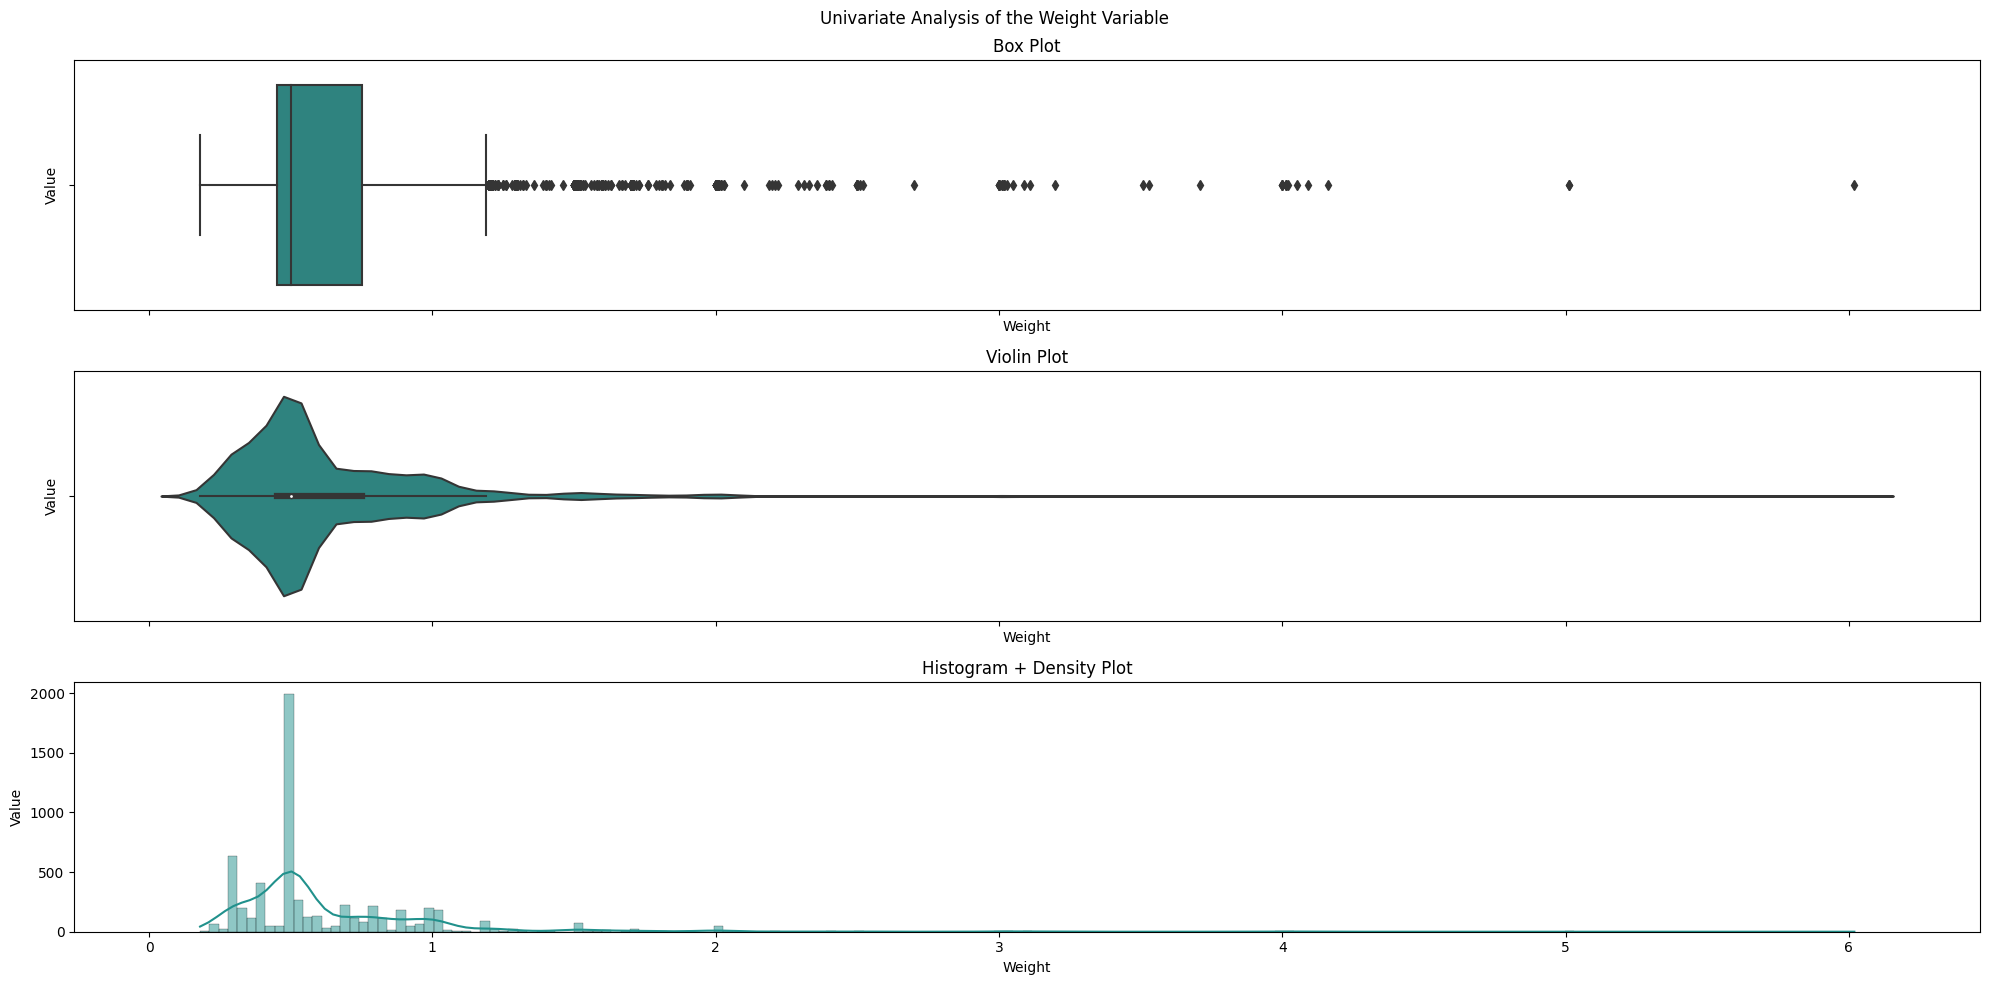

In [7]:
plot_graph_numerical(df["Weight"])

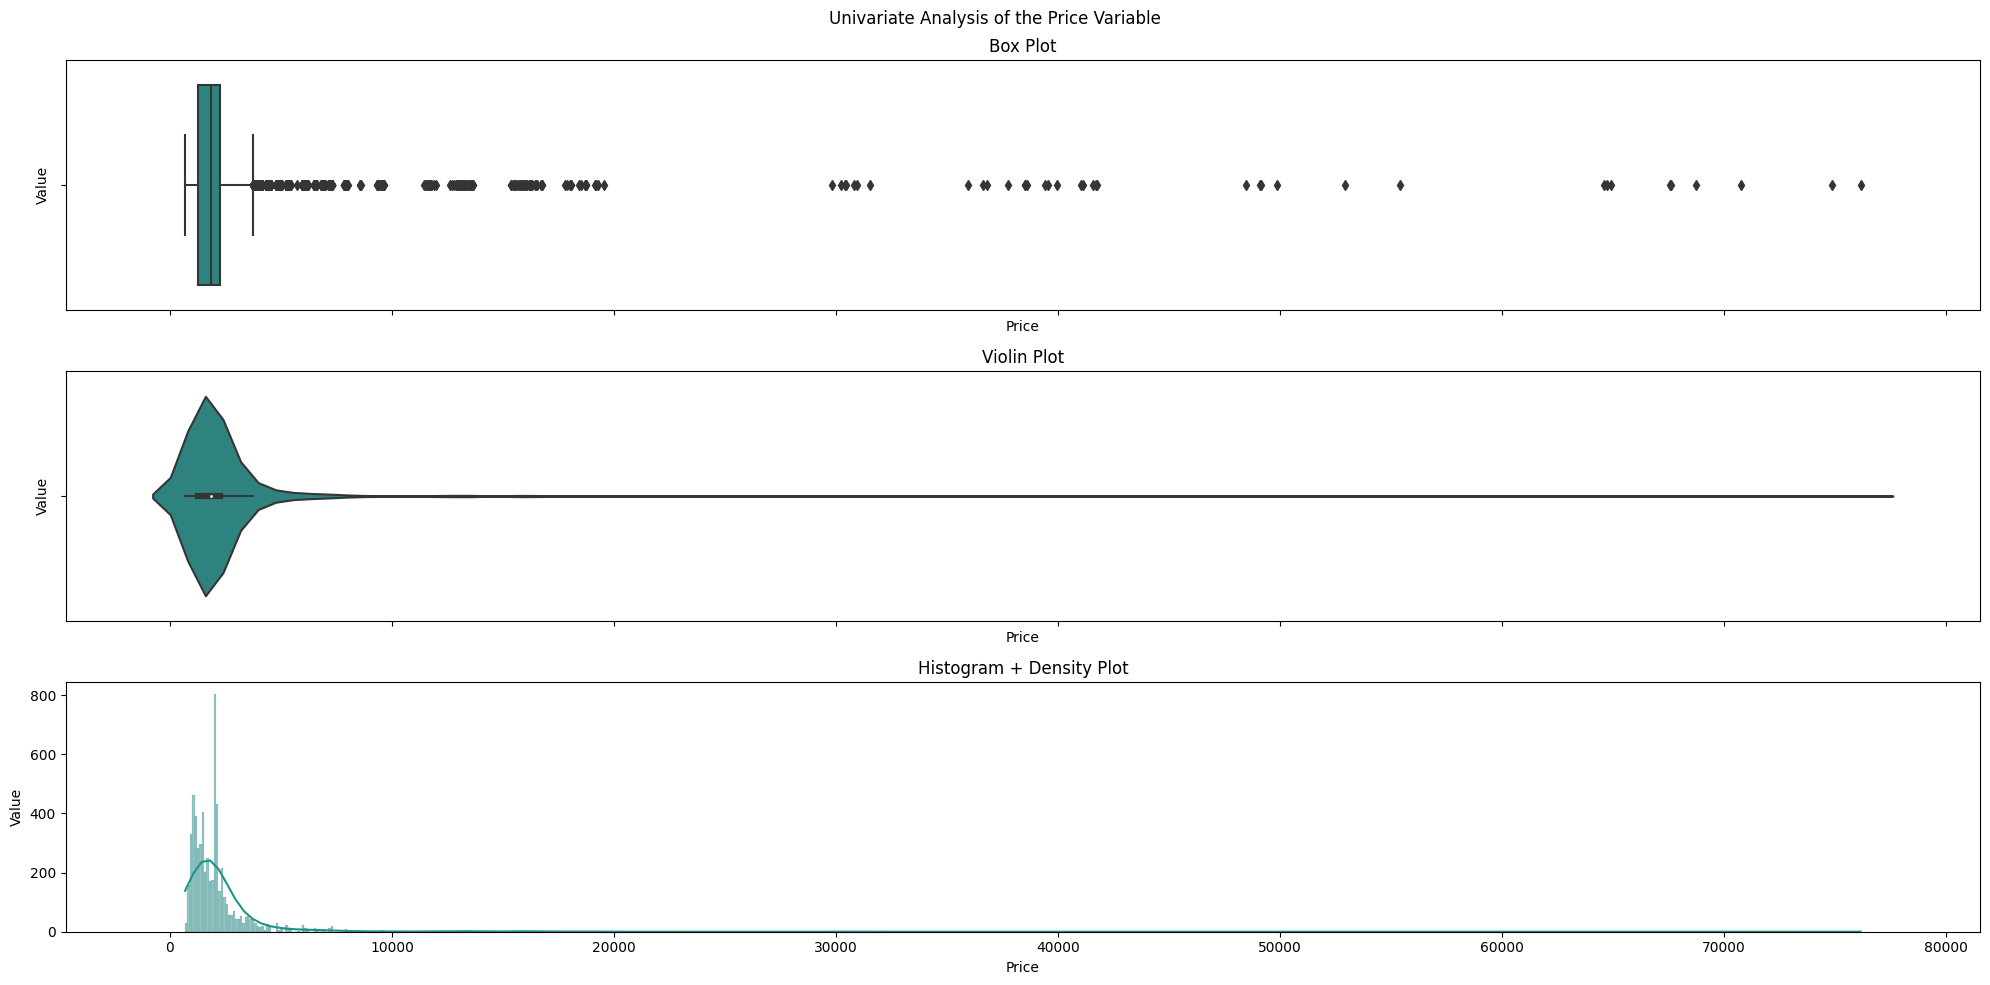

In [8]:
plot_graph_numerical(df["Price"])

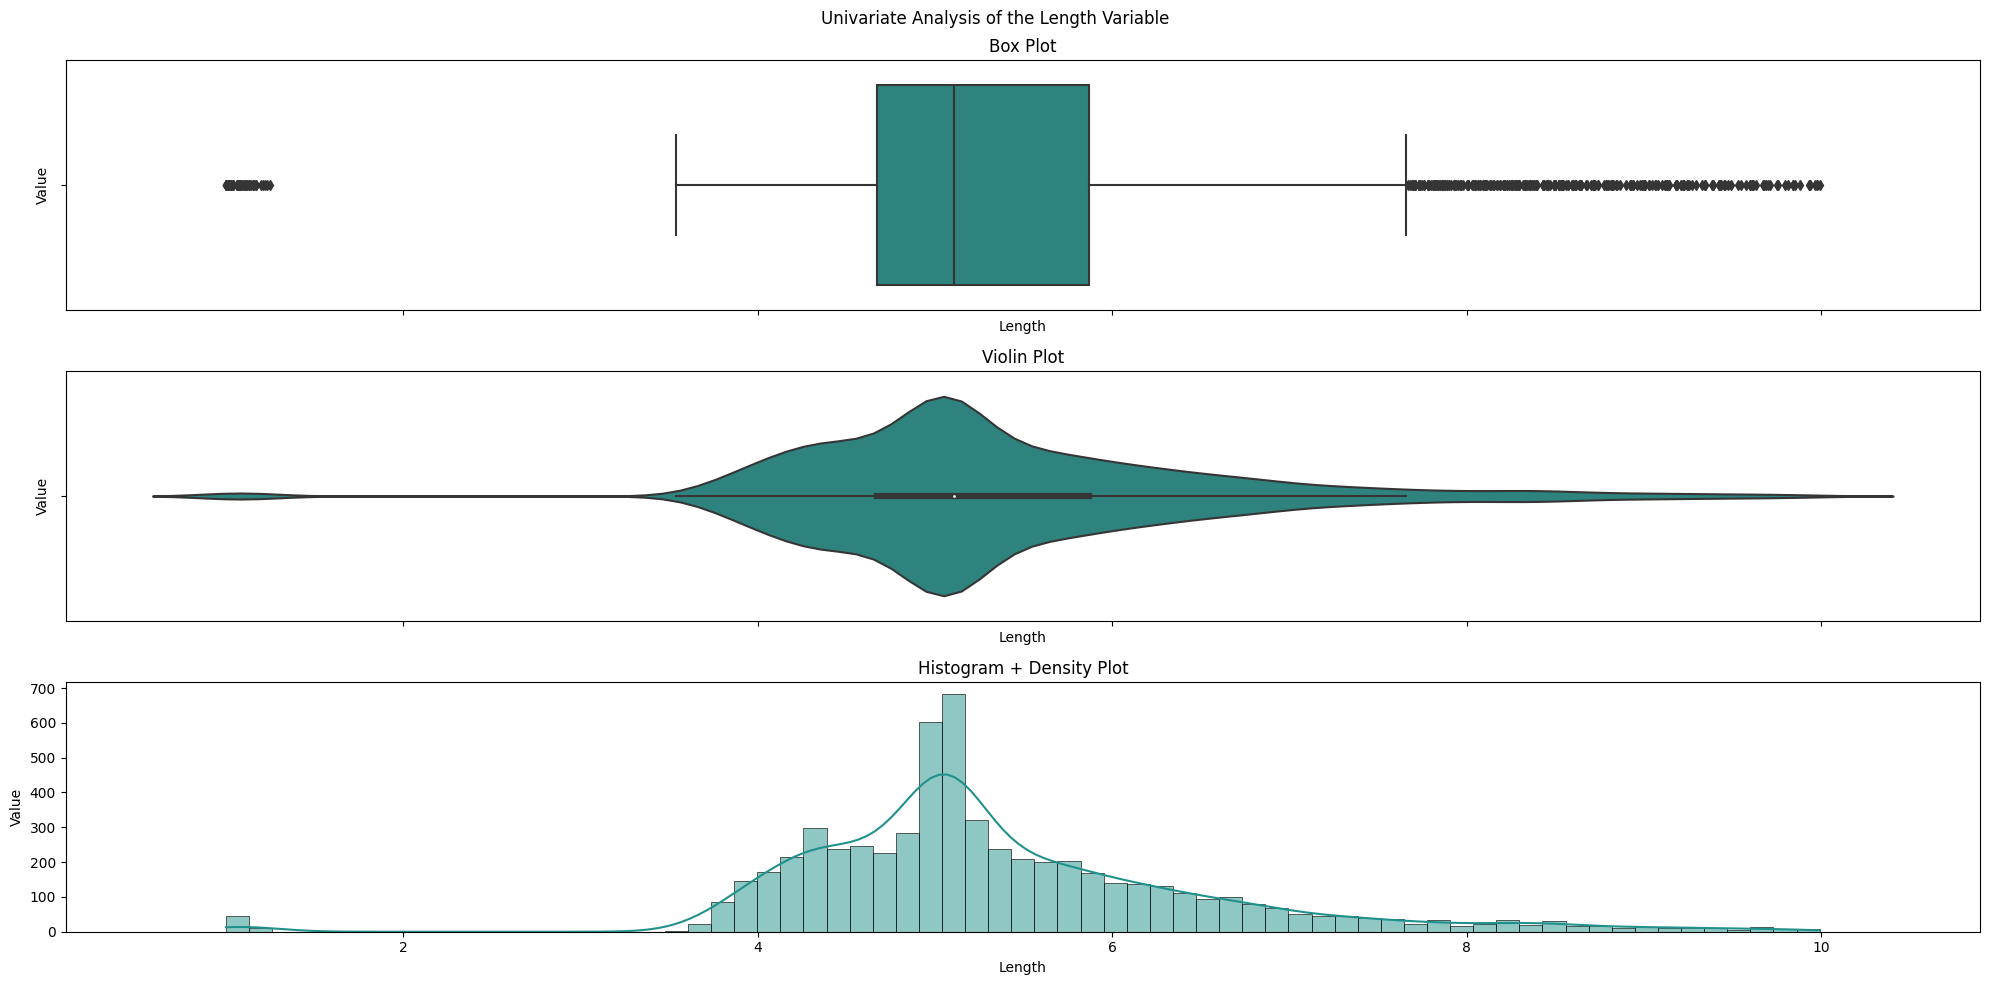

In [9]:
plot_graph_numerical(df["Length"])

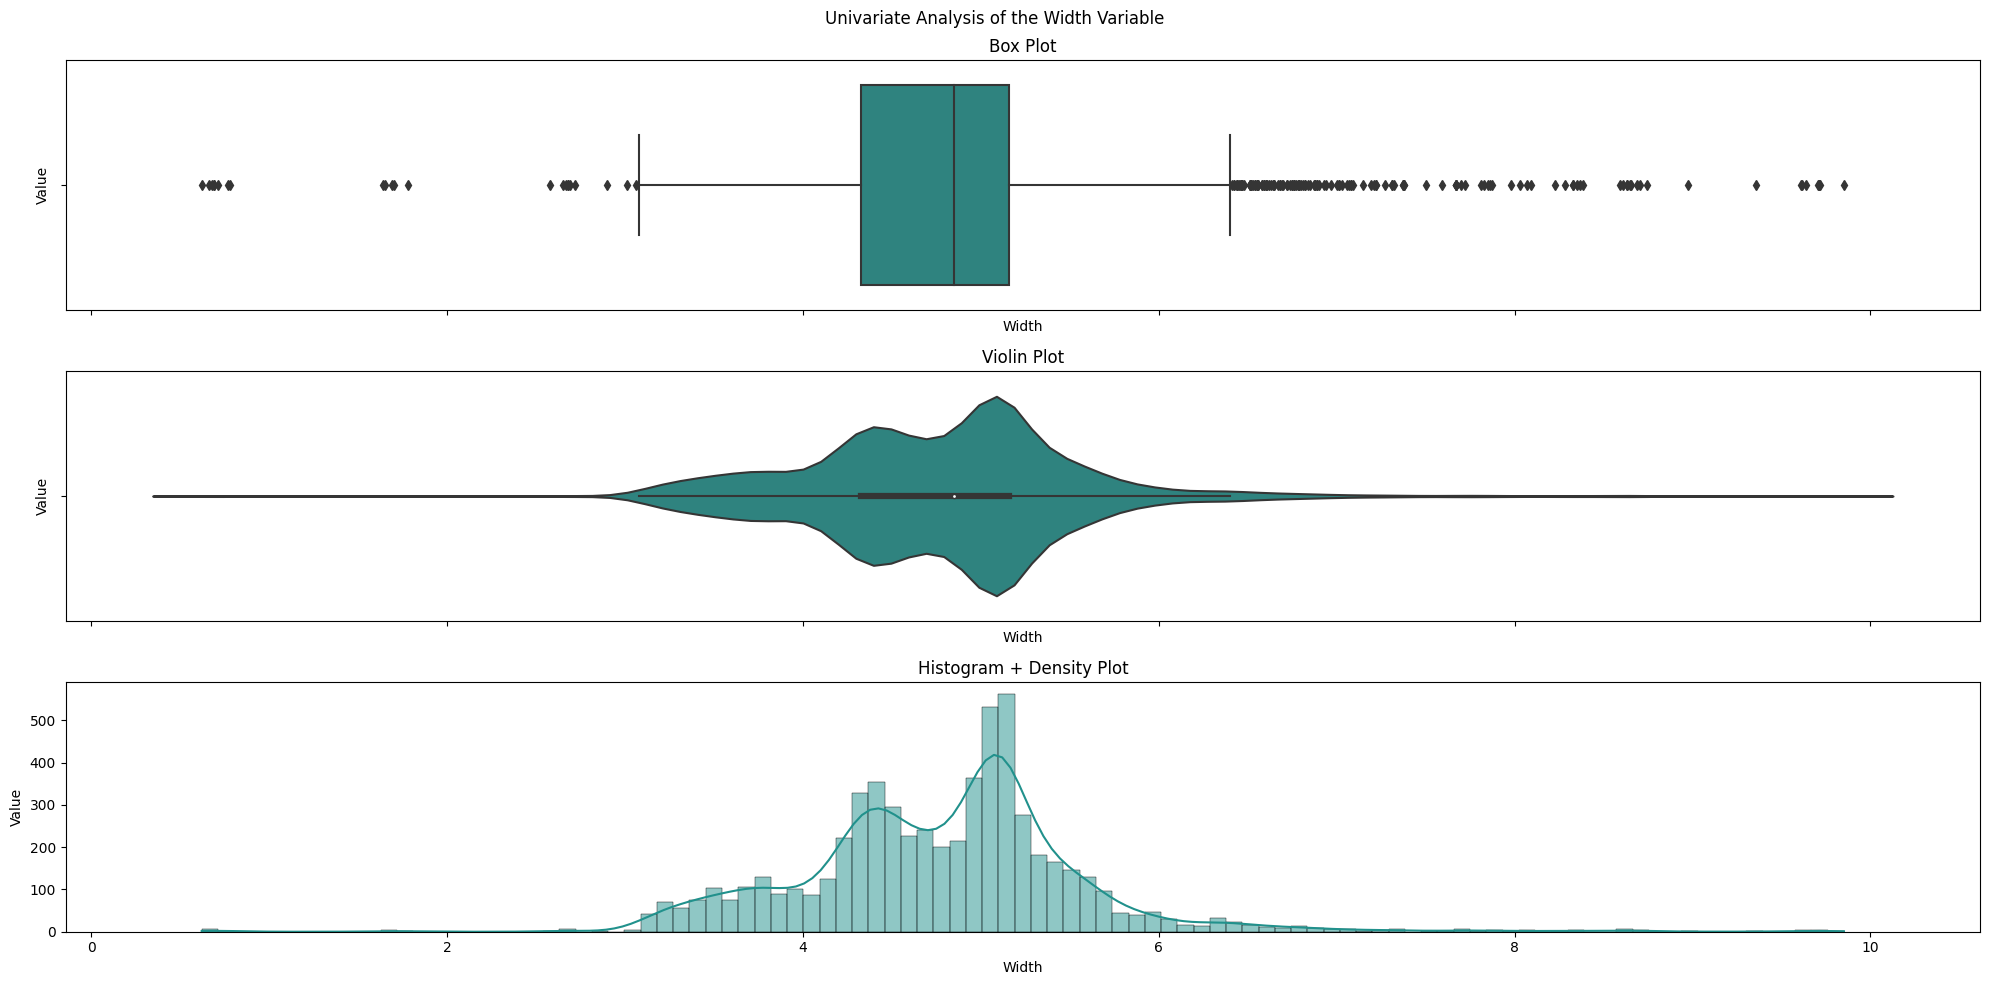

In [10]:
plot_graph_numerical(df["Width"])

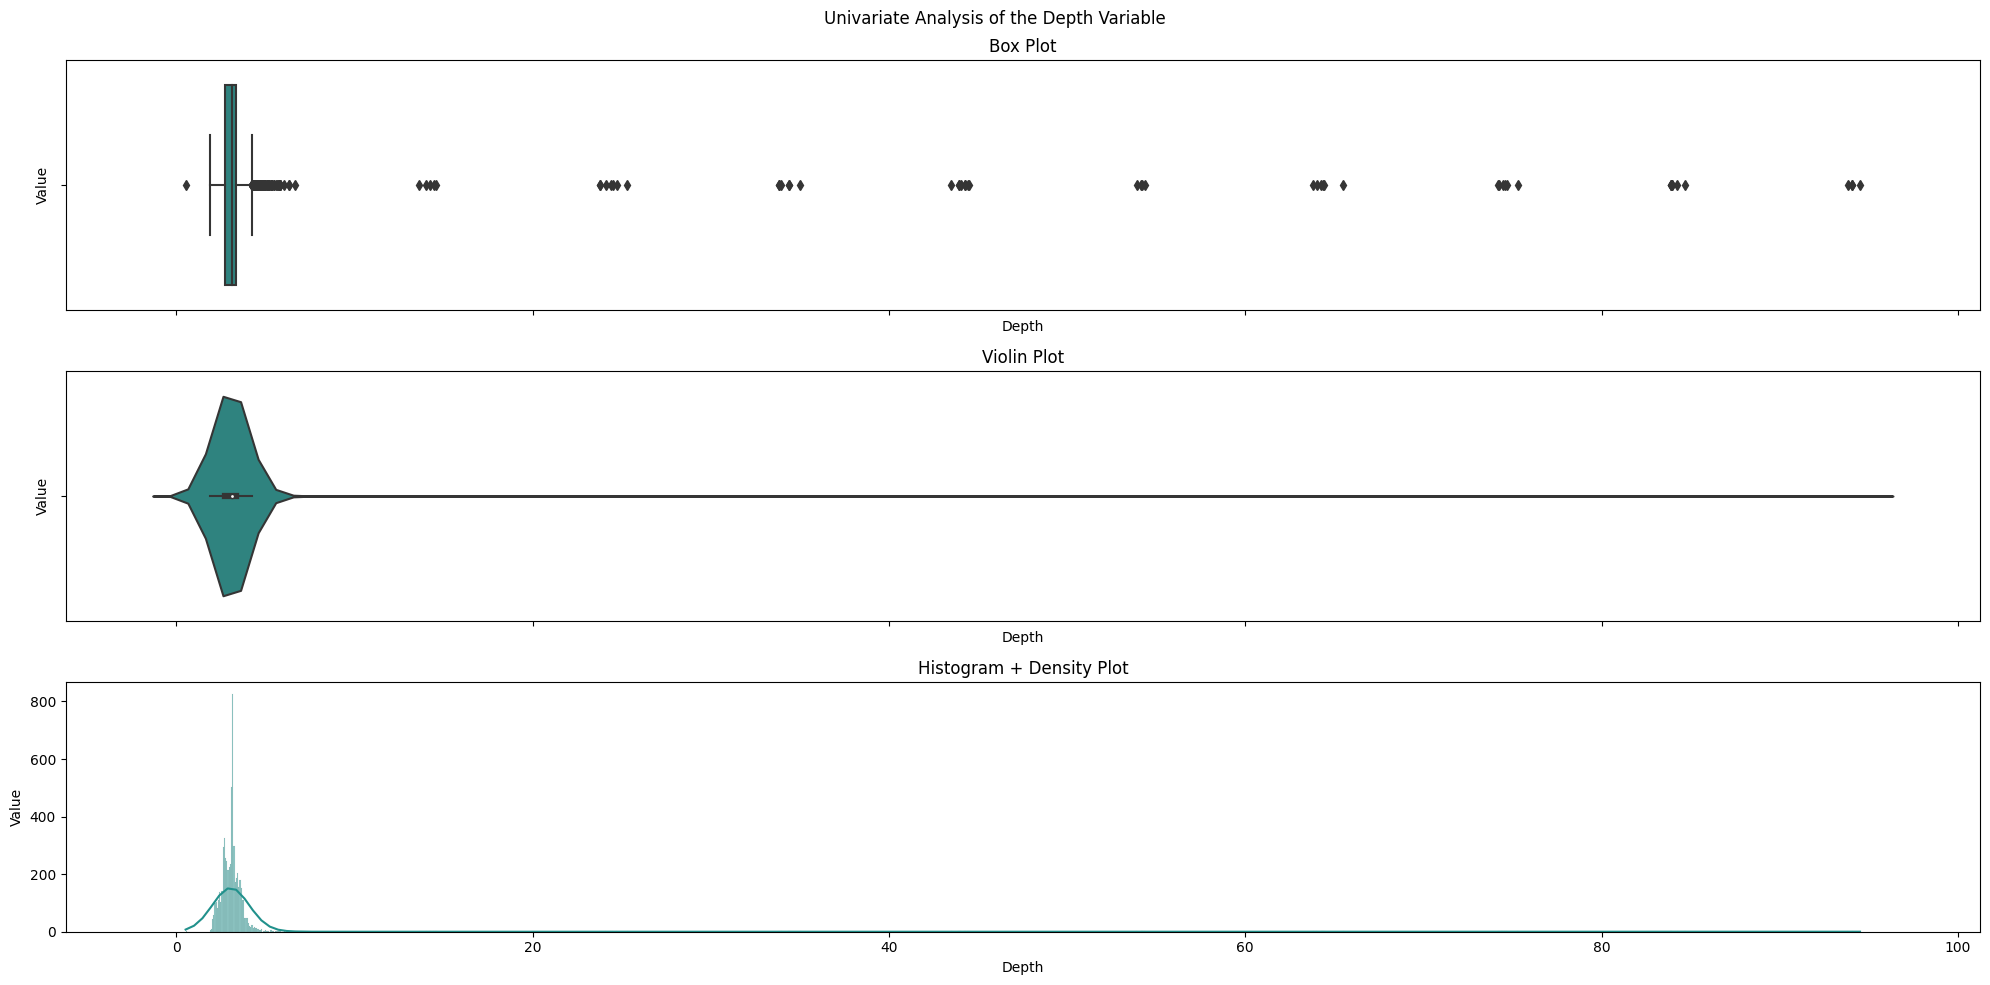

In [11]:
plot_graph_numerical(df["Depth"])

In [12]:
def describe_categorical(df, columns=None, n=25, include_missing=True):
    if columns is None:
        columns = df.select_dtypes(include=['category']).columns.tolist()
    stats = pd.DataFrame(columns=['count', 'percentage'])
    total = df.shape[0]
    for col in columns:
        if include_missing:
            values, counts = df[col].value_counts(dropna=False).index.tolist(), df[col].value_counts(dropna=False).values.tolist()
        else:
            values, counts = df[col].value_counts().index.tolist(), df[col].value_counts().values.tolist()
        if n is not None:
            values = values[:n]
            counts = counts[:n]
        stats_col = pd.DataFrame({'column': col, 'value': values, 'count': counts})
        stats_col['percentage'] = stats_col['count'] / total * 100
        stats = pd.concat([stats, stats_col], ignore_index=False)
    stats.set_index(['column', 'value','count', 'percentage'], inplace=True)
    return stats.sort_index()


In [13]:
describe_categorical(df)

Empty DataFrame
Columns: []
Index: [(Clarity, FL, 1, 0.016691704223001168), (Clarity, I1, 40, 0.6676681689200467), (Clarity, I2, 7, 0.11684192956100817), (Clarity, I3, 1, 0.016691704223001168), (Clarity, IF, 83, 1.385411450509097), (Clarity, SI1, 1424, 23.768986813553663), (Clarity, SI2, 996, 16.624937406109165), (Clarity, VS1, 1099, 18.344182941078284), (Clarity, VS2, 1303, 21.74929060257052), (Clarity, VVS1, 438, 7.310966449674512), (Clarity, VVS2, 599, 9.9983308295777), (Colour, D, 748, 12.485394758804874), (Colour, E, 901, 15.039225504924053), (Colour, F, 924, 15.42313470205308), (Colour, FANCY, 256, 4.273076281088299), (Colour, G, 701, 11.700884660323819), (Colour, H, 562, 9.380737773326658), (Colour, I, 653, 10.899682857619764), (Colour, J, 515, 8.596227674845602), (Colour, K, 309, 5.157736604907361), (Colour, L, 172, 2.8709731263562013), (Colour, M, 88, 1.4688699716241027), (Colour, N, 46, 0.7678183942580538), (Colour, O, 1, 0.016691704223001168), (Colour, O-P, 12, 0.20030045067601399), (Colour, Q-R, 6, 0.10015022533800699), (Colour, S-T, 15, 0.25037556334501754), (Colour, U-V, 35, 0.5842096478050409), (Colour, W, 1, 0.016691704223001168), (Colour, W-X, 34, 0.5675179435820397), (Colour, Y-Z, 12, 0.20030045067601399), (Cut, EX, 4380, 73.10966449674513), (Cut, F, 17, 0.28375897179101983), (Cut, GD, 302, 5.040894675346353), (Cut, VG, 1292, 21.56568185611751), (Fluorescence, F, 1117, 18.644633617092303), (Fluorescence, M, 456, 7.611417125688533), (Fluorescence, N, 4141, 69.12034718744783), (Fluorescence, SL, 6, 0.10015022533800699), (Fluorescence, ST, 243, 4.056084126189284), (Fluorescence, VS, 19, 0.3171423802370222), (Fluorescence, VSL, 9, 0.15022533800701052), (Polish, EX, 4781, 79.80303789016858), (Polish, F, 1, 0.016691704223001168), (Polish, GD, 63, 1.0515773660490735), (Polish, VG, 1146, 19.128693039559337), (Shape, CUSHION, 1662, 27.74161241862794), (Shape, EMERALD, 550, 9.180437322650642), (Shape, HEART, 345, 5.758637956935403), (Shape, MARQUISE, 68, 1.1350358871640793), (Shape, OVAL, 678, 11.316975463194792), (Shape, PEAR, 302, 5.040894675346353), (Shape, PRINCESS, 624, 10.41562343515273), (Shape, ROUND, 1762, 29.410782840928057), (Symmetry, EX, 1698, 28.342513770655987), (Symmetry, FR, 54, 0.9013520280420632), (Symmetry, GD, 1056, 17.626439659489236), (Symmetry, VG, 3183, 53.129694541812725)]

In [14]:
def plot_graph_categorical(data):
    
    values, counts = np.unique(data, return_counts=True)
    sorted_idx = np.argsort(-counts)
    values = values[sorted_idx]
    counts = counts[sorted_idx]
    
    f, (ax_bar,ax_pie) = plt.subplots(1,2)
    
    sns.countplot(x=data, ax=ax_bar,order = data.value_counts().index, palette="viridis")
    ax_bar.set(xlabel=data.name, ylabel='Count', title=f'Count of Diamonds by {data.name}')
    for i in ax_bar.containers:
        ax_bar.bar_label(i,)
    
    color_palette = sns.color_palette("viridis", len(values)).as_hex()
    
    plt.title(f'Distribution of Diamonds by {data.name}')
    ax_pie = plt.pie(counts, labels=values, startangle=90, counterclock=False, autopct='%.0f%%', colors=color_palette, textprops={"color": "#bbbbbb"})


    f.suptitle(f'Univariate Analysis of the {data.name} Variable')

    f.set_figwidth(20)
    f.set_figheight(10)
    plt.tight_layout()
    plt.show()

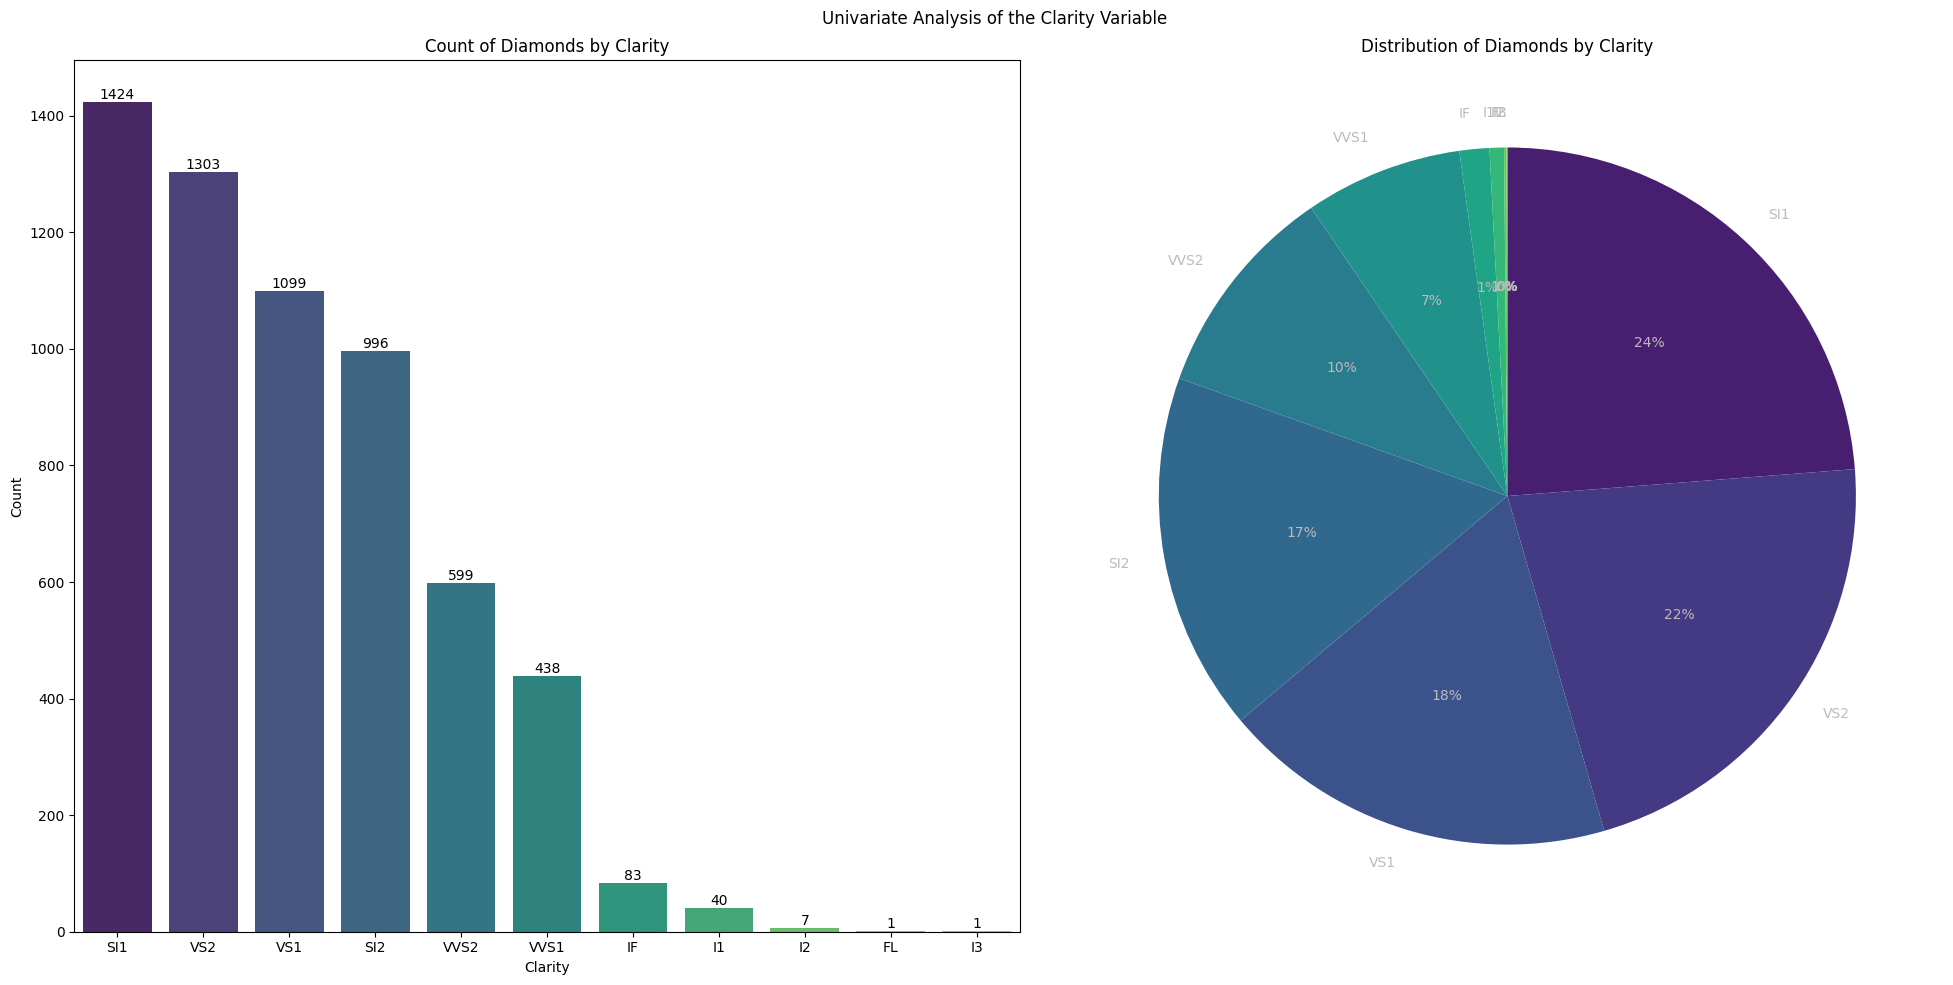

In [15]:
plot_graph_categorical(df['Clarity'])

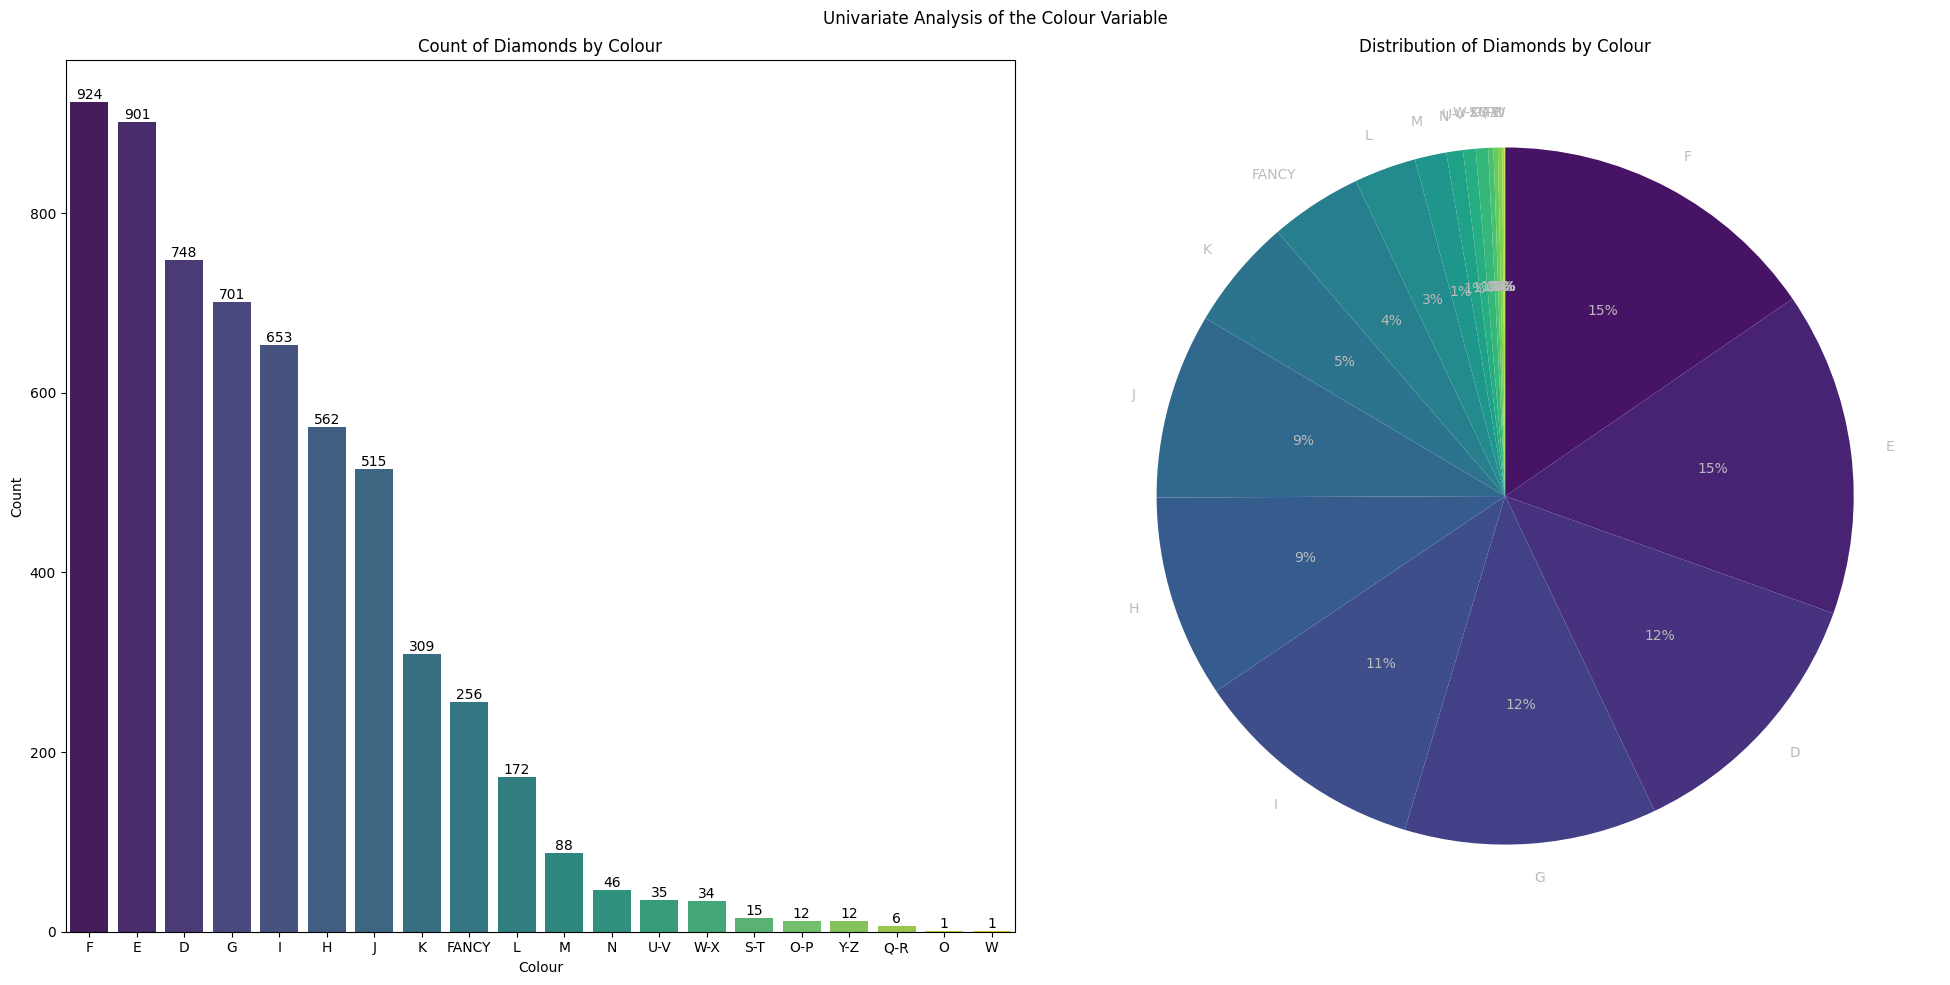

In [16]:
plot_graph_categorical(df['Colour'])

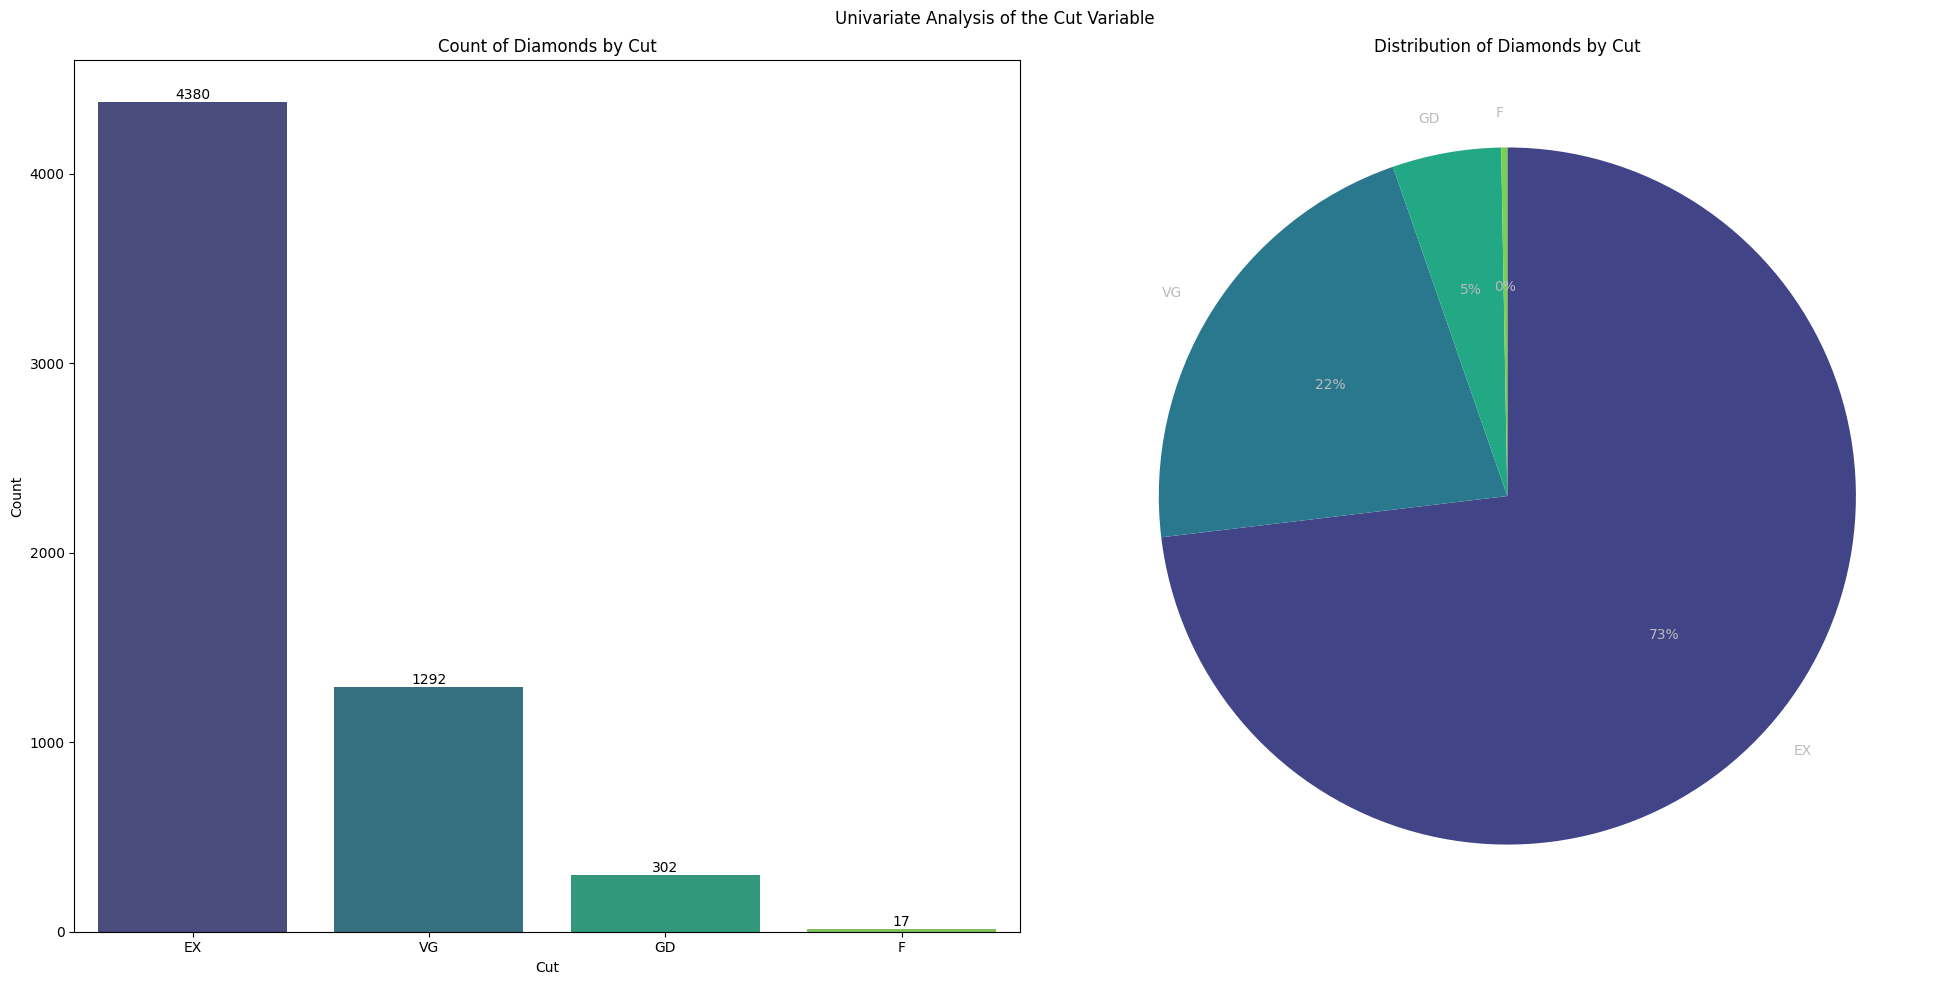

In [17]:
plot_graph_categorical(df['Cut'])

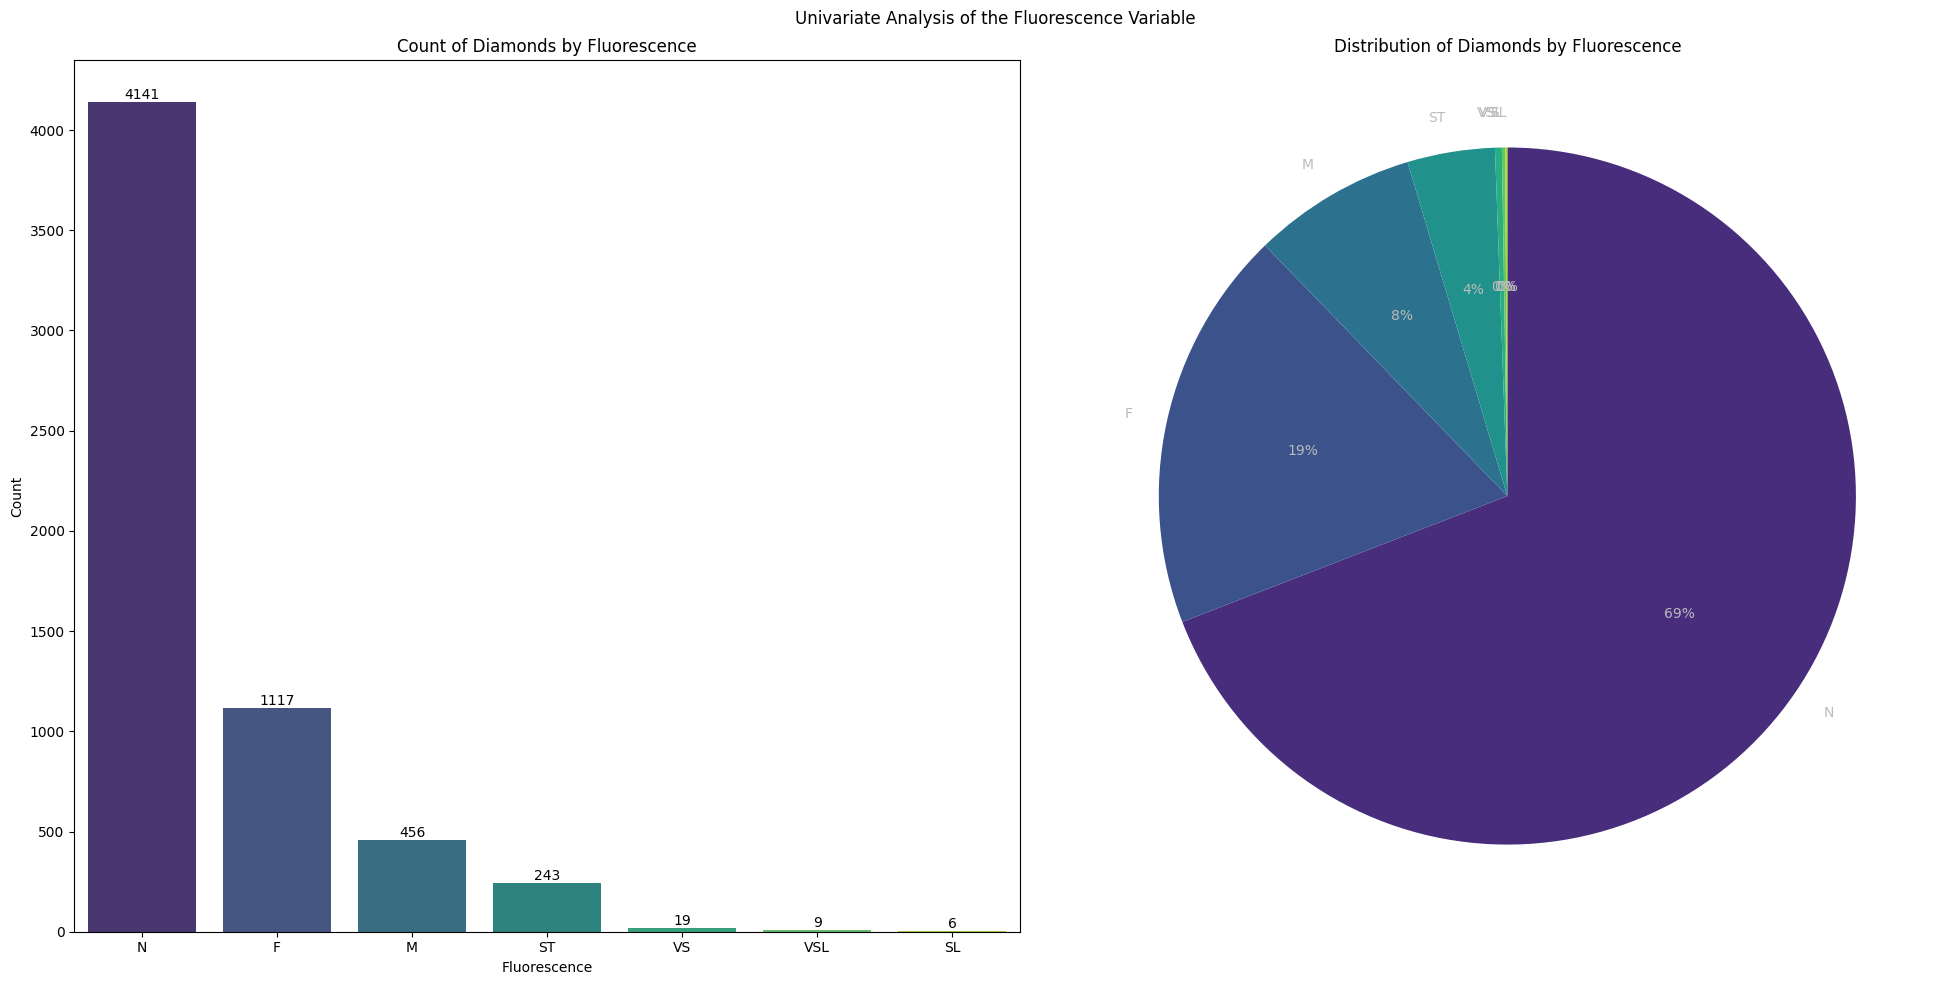

In [18]:
plot_graph_categorical(df['Fluorescence'])

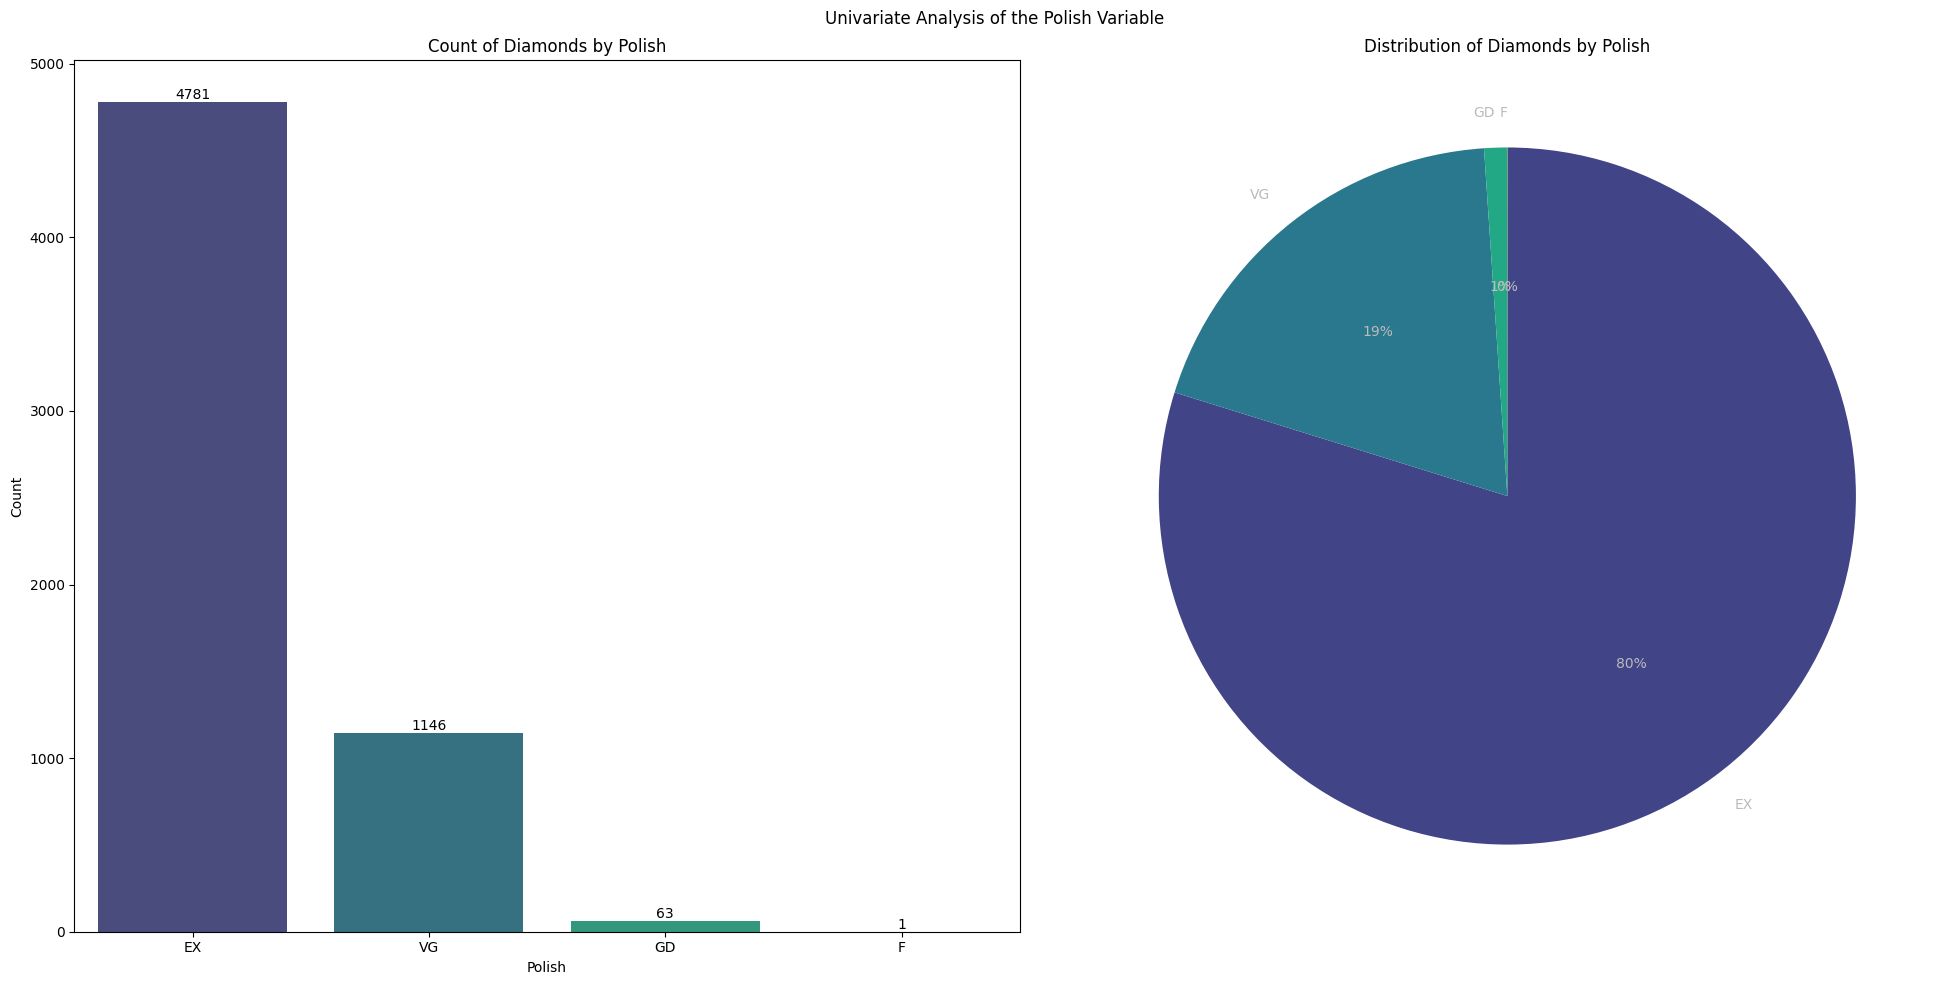

In [19]:
plot_graph_categorical(df['Polish'])

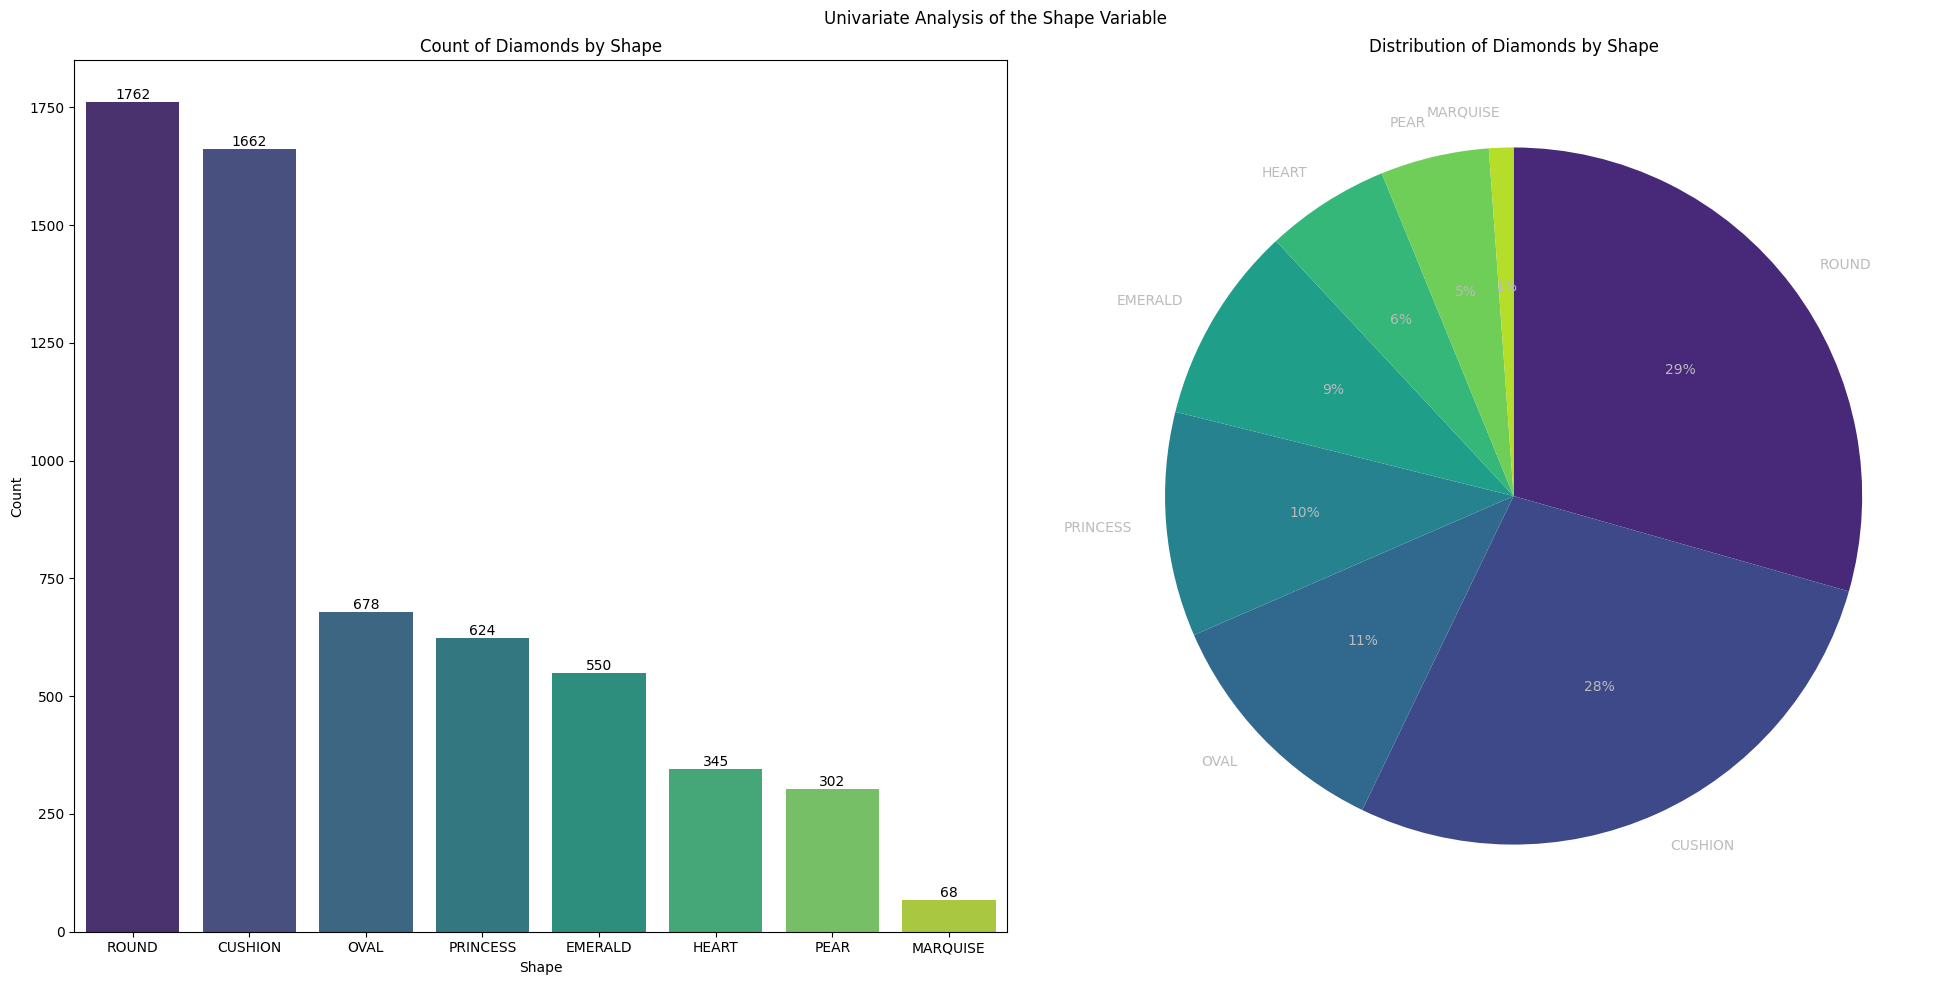

In [20]:
plot_graph_categorical(df['Shape'])

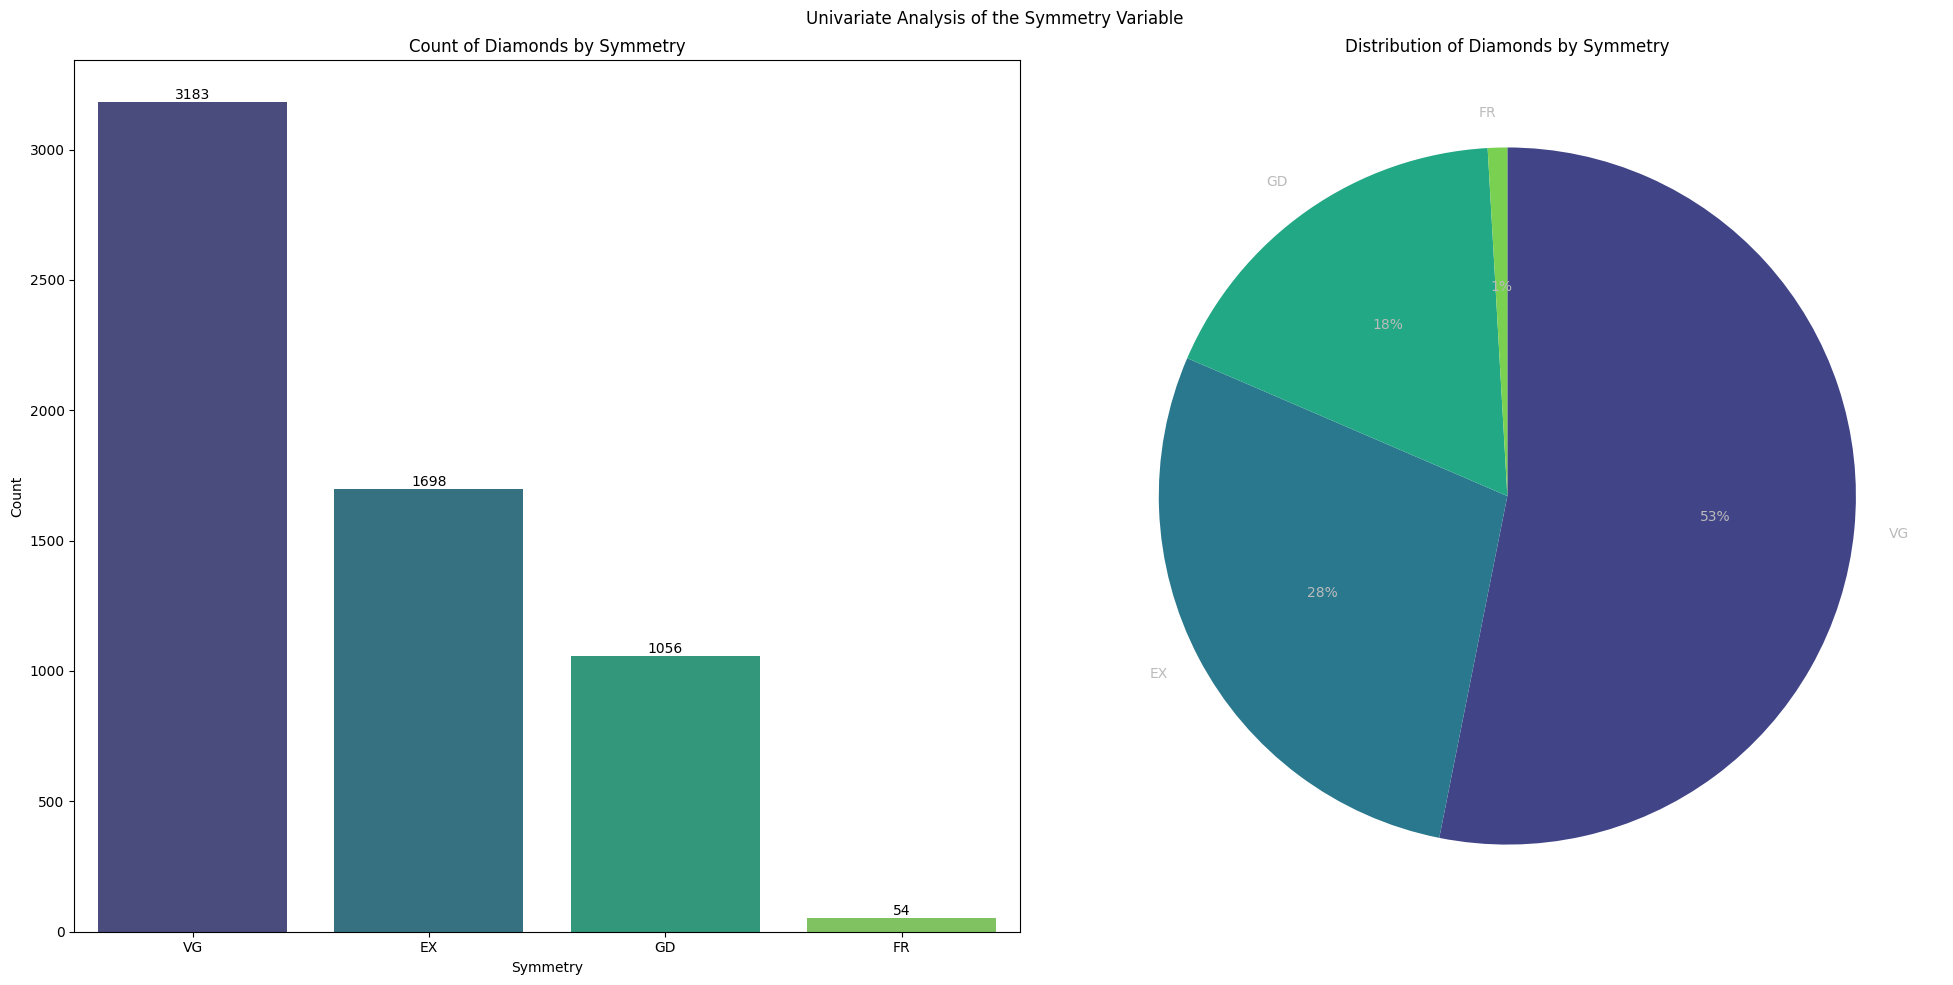

In [21]:
plot_graph_categorical(df['Symmetry'])

In [22]:
def groupby_violinplot(df, x, y, hue=None, order=None):
    plt.figure(figsize=(15,8))
    sns.violinplot(data=df, x=x, y=y, hue=hue, order=order, palette="viridis")
    plt.title(f'Distribution of {y} by {x}')
    plt.show()

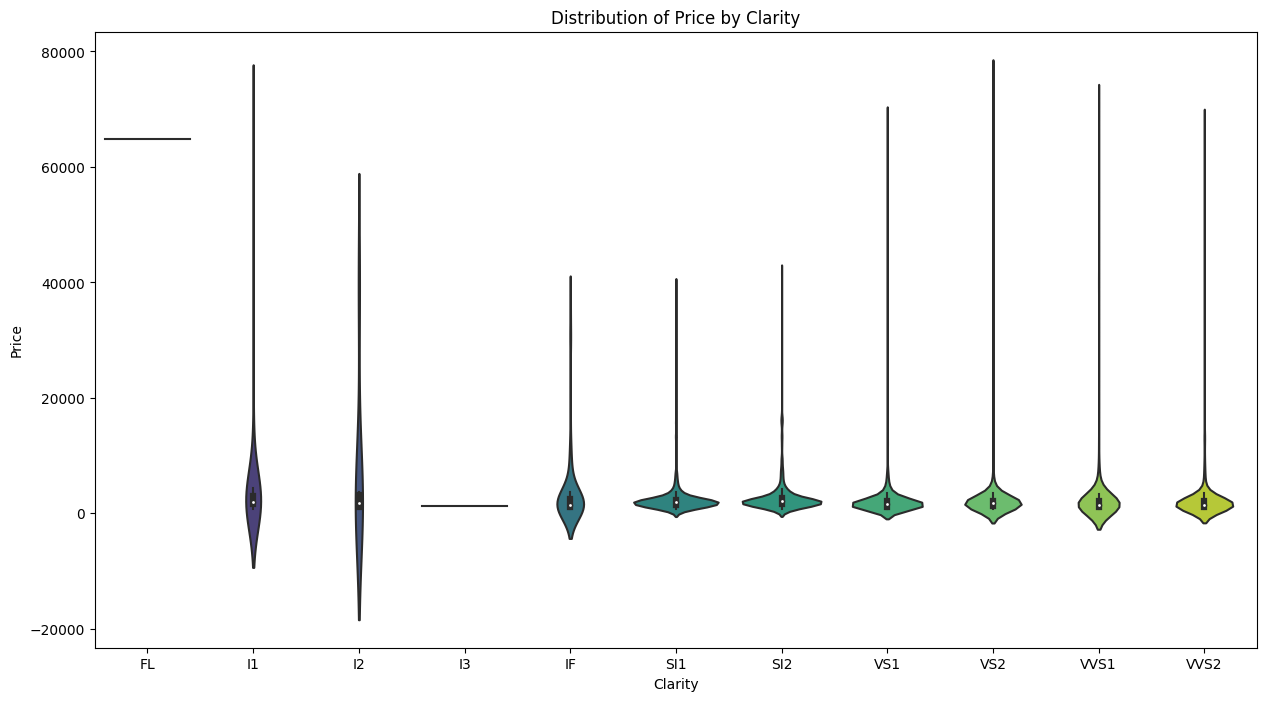

In [23]:
groupby_violinplot(df, "Clarity", "Price")

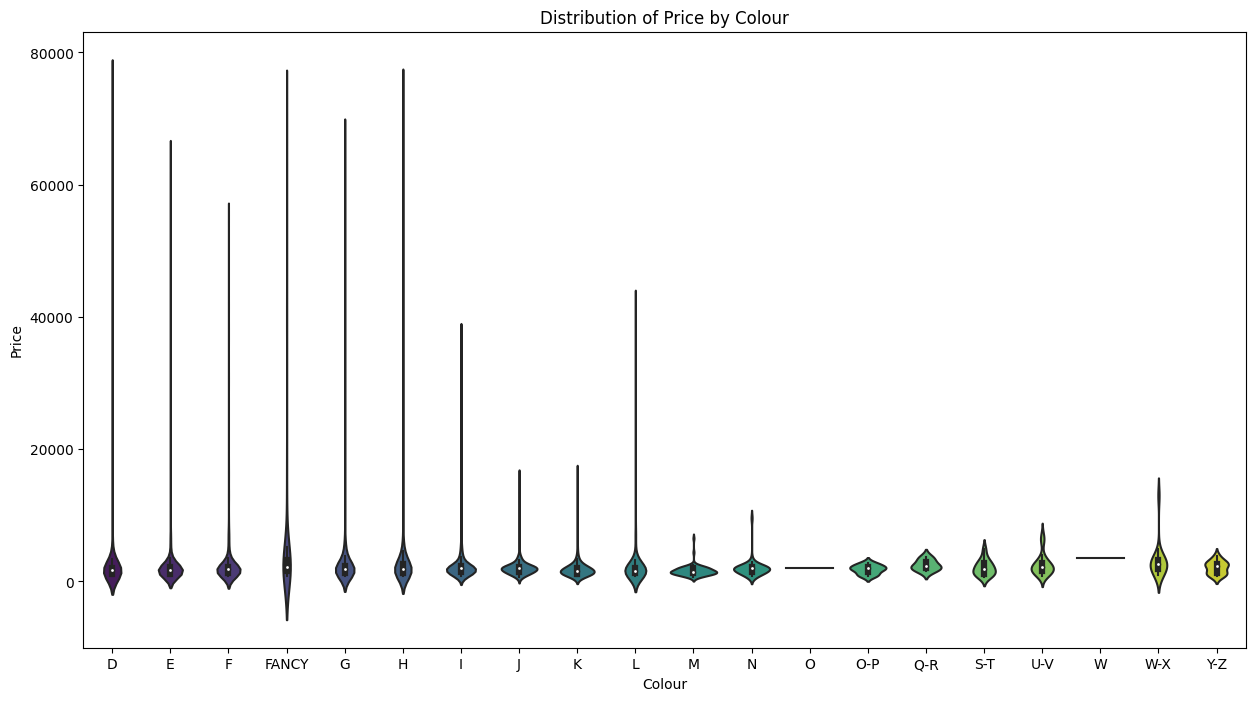

In [24]:
groupby_violinplot(df, "Colour", "Price")

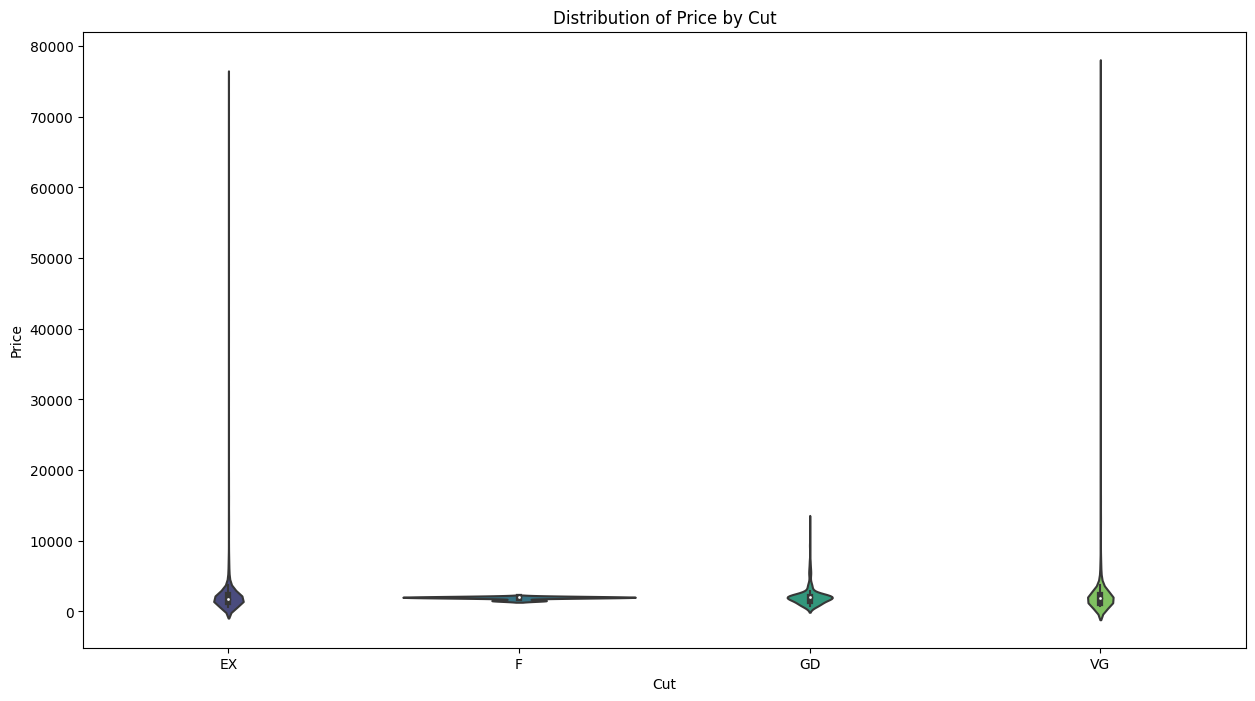

In [25]:
groupby_violinplot(df, "Cut", "Price")

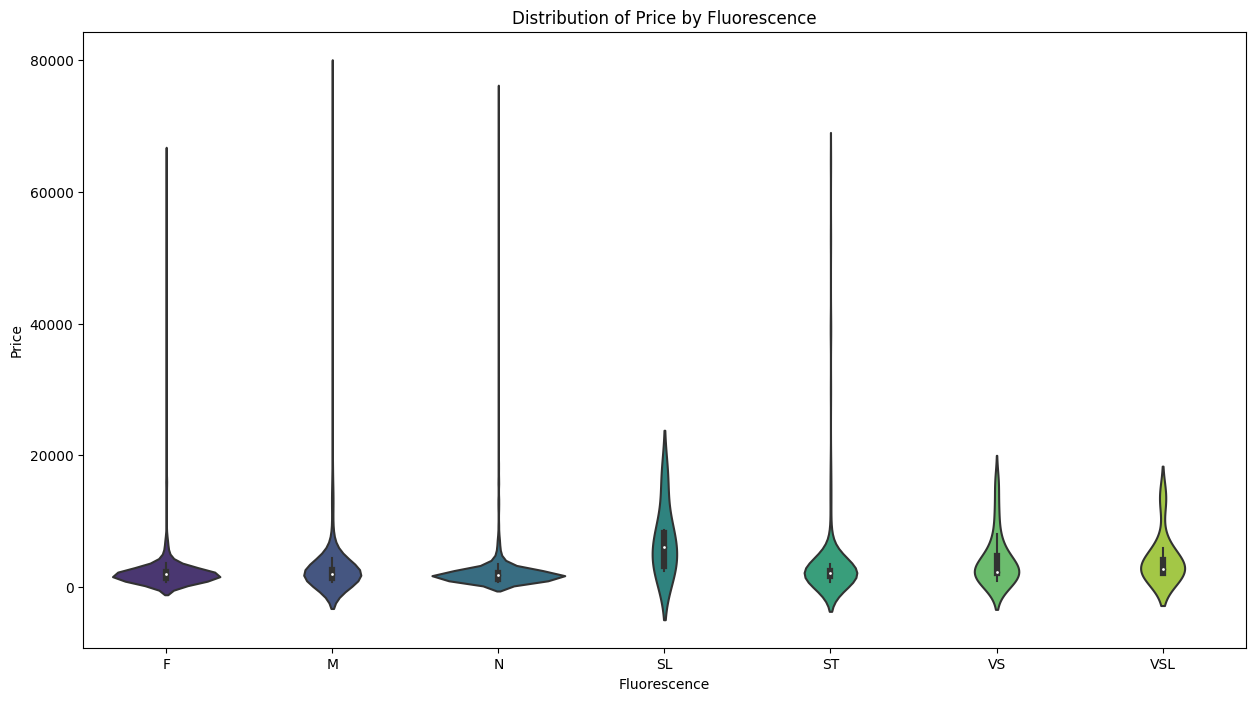

In [26]:
groupby_violinplot(df, "Fluorescence", "Price")

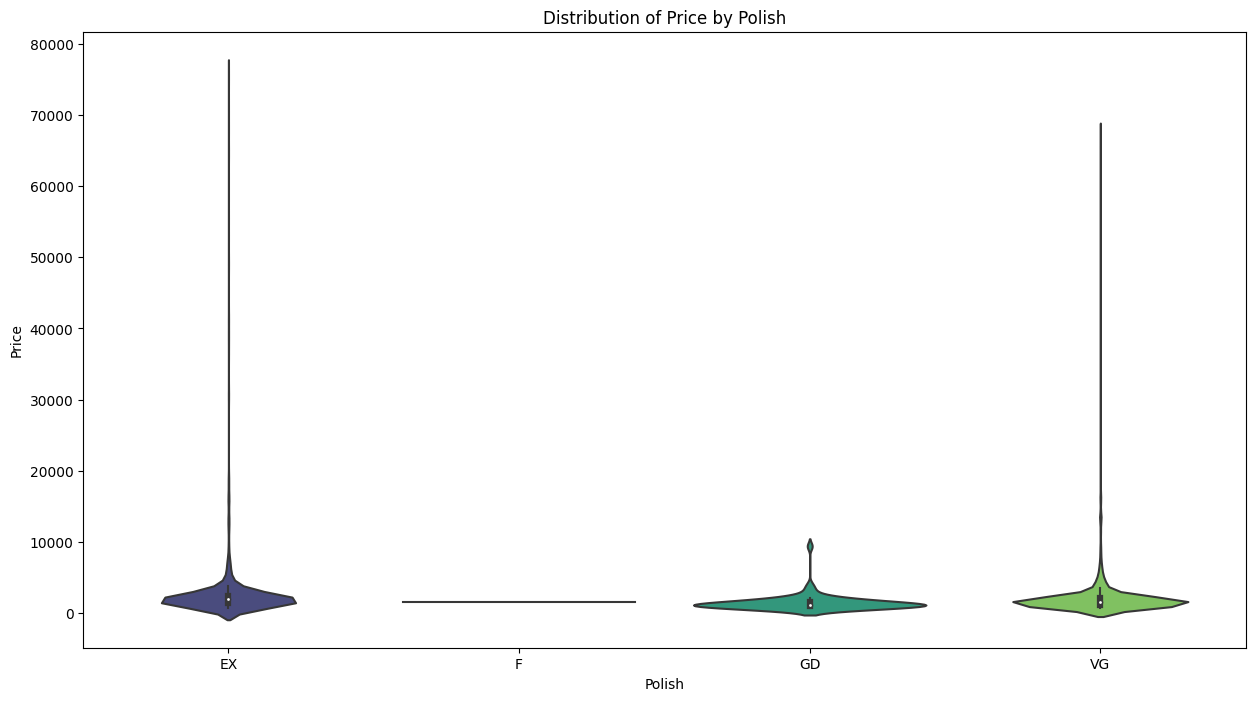

In [27]:
groupby_violinplot(df, "Polish", "Price")

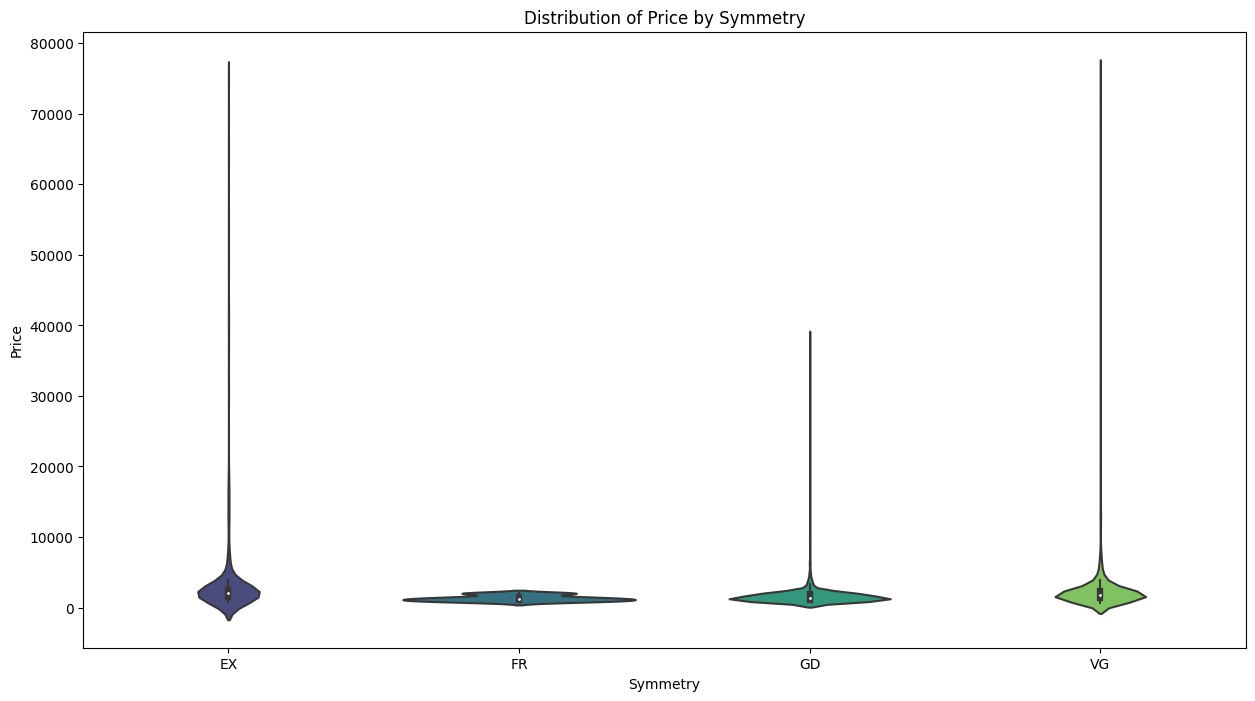

In [28]:
groupby_violinplot(df, "Symmetry", "Price")

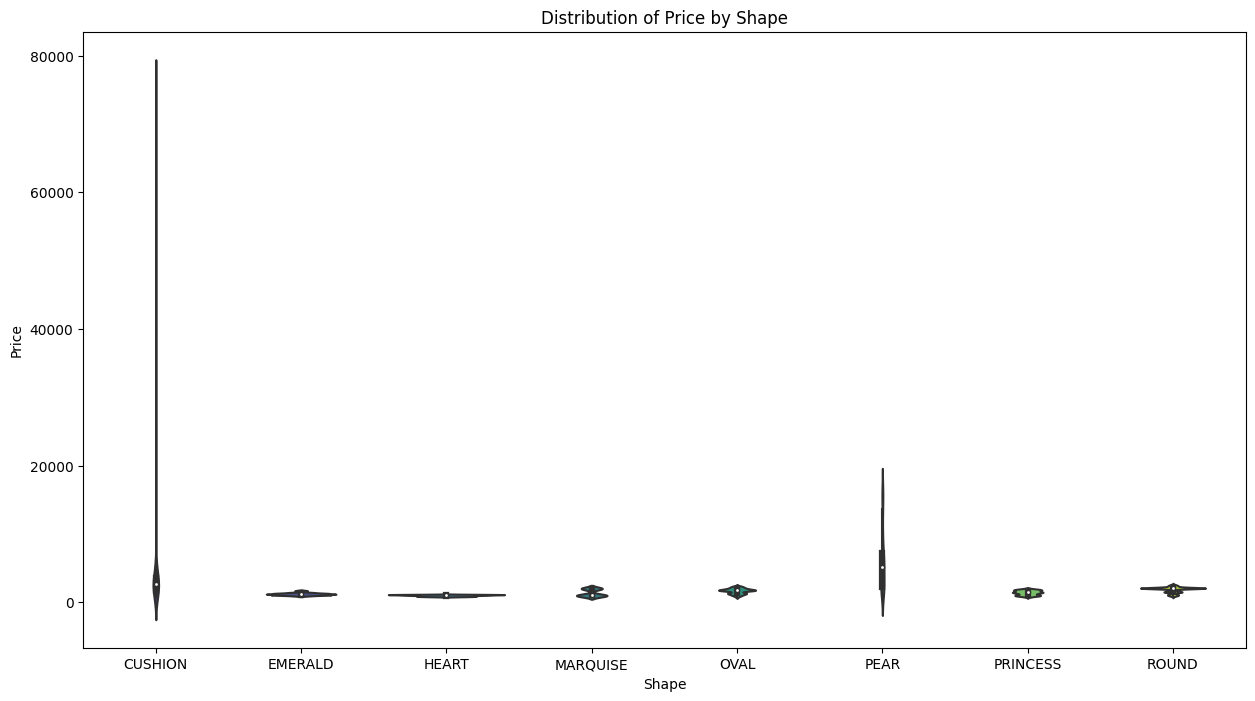

In [29]:
groupby_violinplot(df, "Shape", "Price")

In [30]:
filtered_df = df.query('Price <= 10000')
filtered_df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
index,,,,,,,,,,,,,
0,1638147,CUSHION,0.549805,SI2,E,EX,EX,VG,N,1378.650024,5.050781,4.351562,2.939453
1,1630155,CUSHION,0.500000,VVS1,FANCY,EX,EX,VG,F,1379.739990,4.601562,4.308594,2.919922
2,1612606,CUSHION,0.509766,VS2,H,EX,EX,VG,N,1380.189941,4.710938,4.351562,2.939453
3,1638140,CUSHION,0.500000,VS2,H,EX,EX,VG,N,1380.609985,4.910156,4.261719,2.880859
4,1536093,CUSHION,0.529785,SI1,D,EX,VG,VG,N,1383.130005,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6332,1751206,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.000000,5.039062,3.179688
6333,1773024,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.031250,5.058594,3.160156
6336,1789435,ROUND,0.500000,VS2,D,VG,EX,VG,N,2453.199951,4.929688,4.960938,3.189453


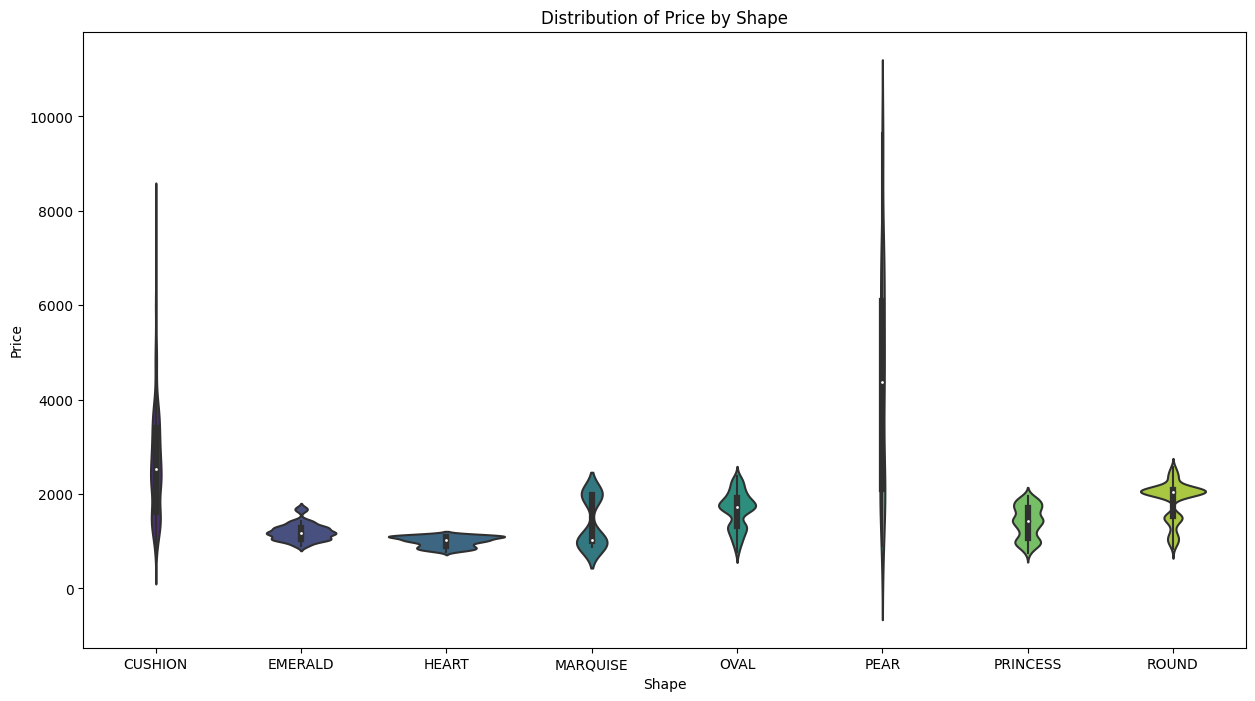

In [31]:
groupby_violinplot(filtered_df, "Shape", "Price")

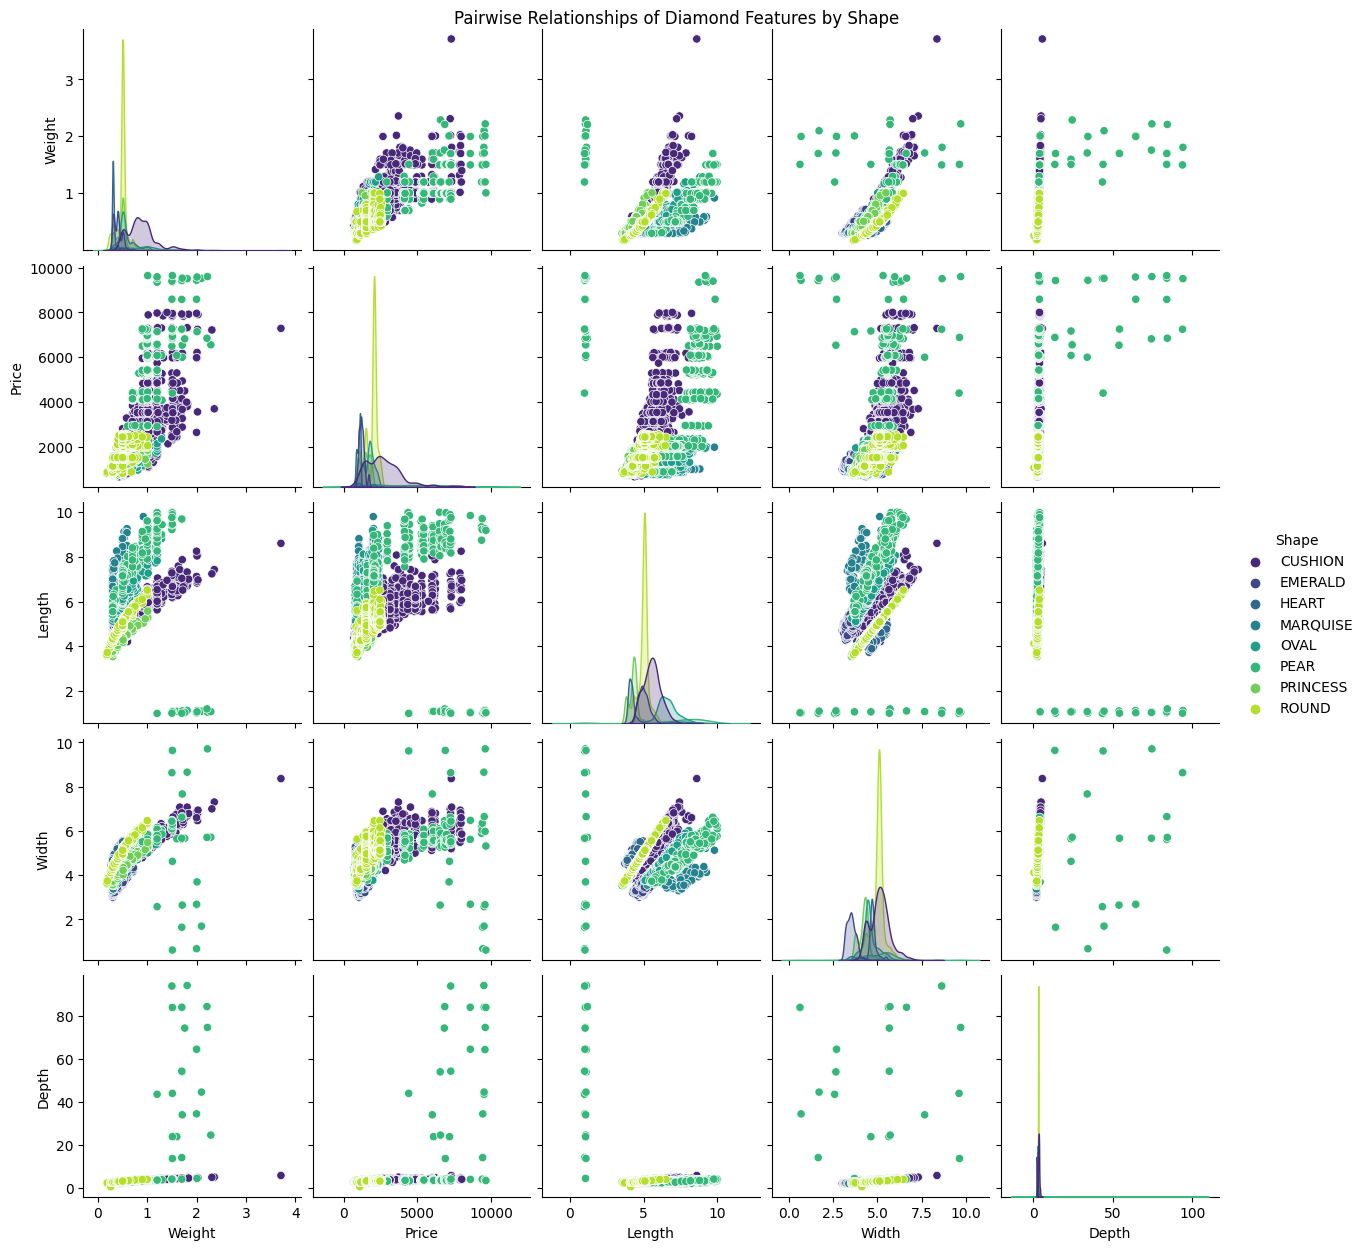

In [32]:
# sns.pairplot(df)
sns.pairplot(filtered_df, hue='Shape', palette="viridis")
plt.suptitle('Pairwise Relationships of Diamond Features by Shape', y=1)
plt.show()

In [33]:
filtered_df.query('Length <= 2')

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
index,,,,,,,,,,,,,
3371,211132-77,PEAR,1.509766,VS2,M,EX,EX,VG,F,4408.700195,1.000000,9.617188,43.906250
3406,201241-87,PEAR,1.700195,SI2,E,EX,EX,EX,N,9421.620117,1.009766,1.650391,14.046875
3407,200606-47,PEAR,2.000000,SI2,F,VG,VG,VG,N,9433.000000,1.019531,0.680176,34.375000
3408,200793-1466,PEAR,1.809570,SI2,G,EX,EX,EX,N,9504.070312,1.129883,8.656250,94.062500
3409,210414-830,PEAR,1.200195,VVS2,H,EX,EX,EX,F,9518.209961,1.000000,2.580078,43.500000
3410,Eco Diamond LG200554,PEAR,2.099609,VVS2,H,EX,EX,EX,N,9519.610352,1.099609,1.700195,44.500000
3411,200672-1235,PEAR,1.709961,I1,F,EX,EX,VG,N,9527.469727,1.110352,6.648438,83.937500
3412,210329-31,PEAR,2.009766,SI2,L,EX,VG,VG,M,9578.570312,1.129883,2.669922,64.250000
3414,210241-20,PEAR,2.220703,VVS1,N,VG,EX,EX,M,9598.230469,1.059570,9.710938,74.562500


In [34]:
filtered_df = filtered_df.query('Length > 2')

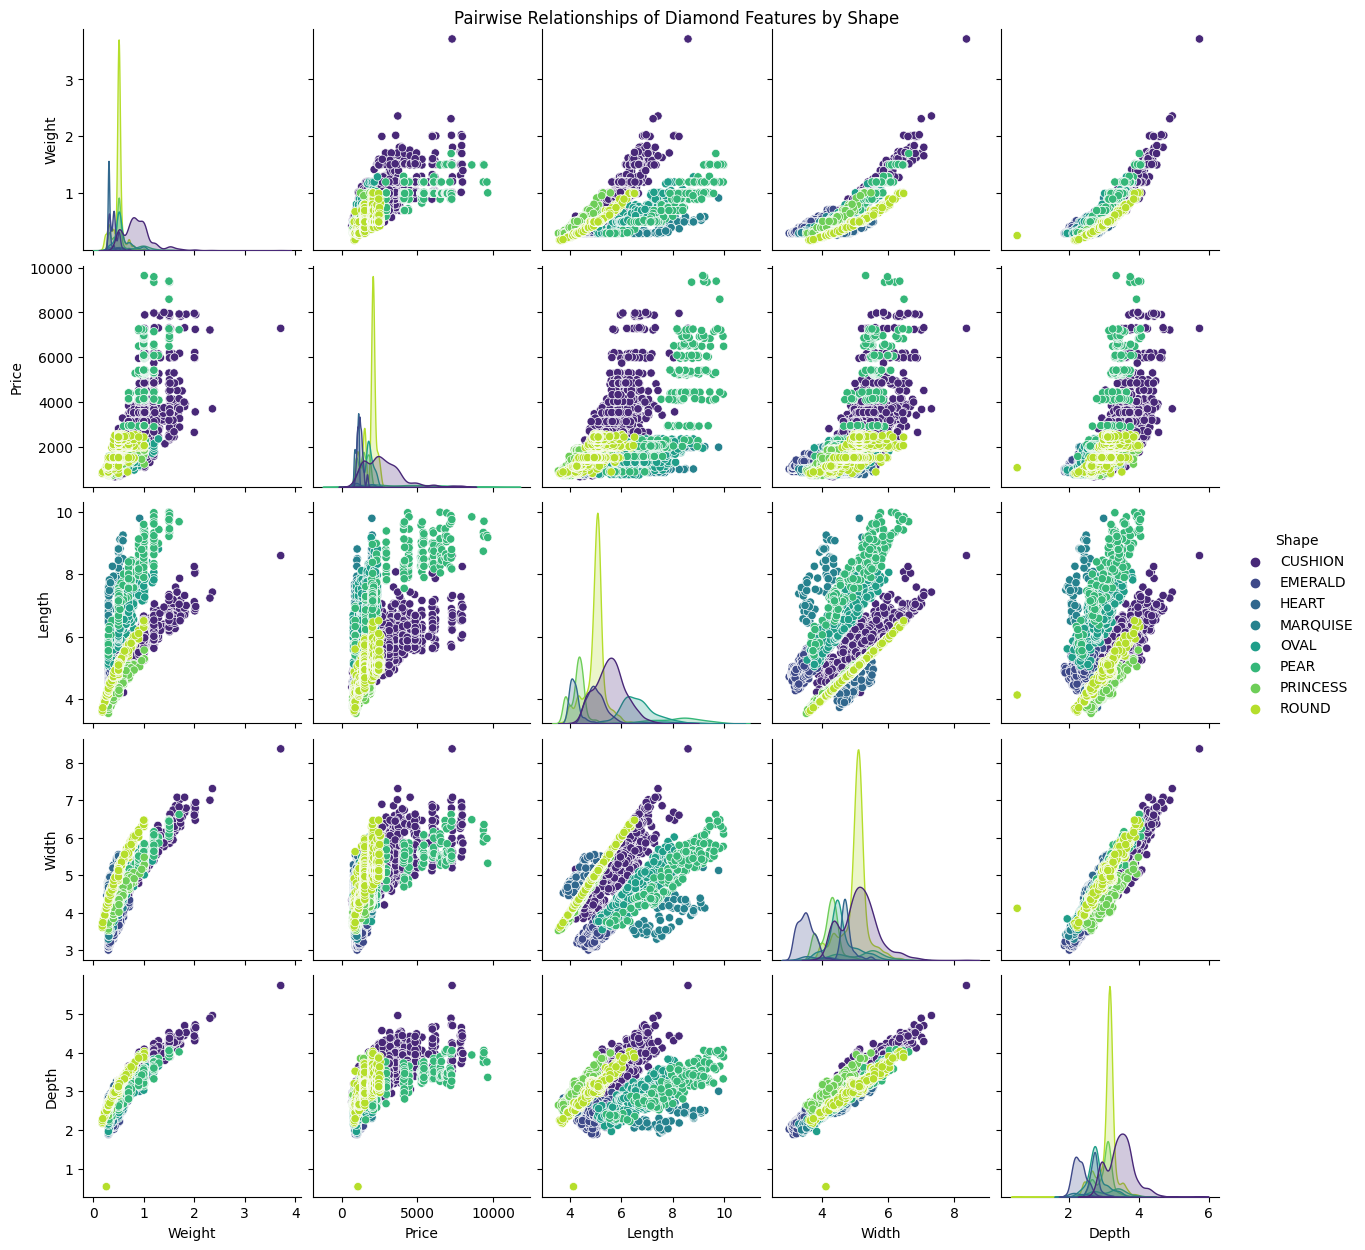

In [35]:
sns.pairplot(filtered_df, hue='Shape', palette="viridis")
plt.suptitle('Pairwise Relationships of Diamond Features by Shape', y=1)
plt.show()

In [36]:
filtered_df.query('Weight > 3 or Depth < 1')

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
index,,,,,,,,,,,,,
1518,210315-74,CUSHION,3.710938,SI2,FANCY,VG,EX,VG,F,7291.850098,8.601562,8.367188,5.738281
4455,1488486,ROUND,0.260010,VVS2,F,EX,EX,EX,N,1085.810059,4.128906,4.121094,0.529785


In [37]:
filtered_df = filtered_df.query('Weight <= 3 and Depth >= 1')

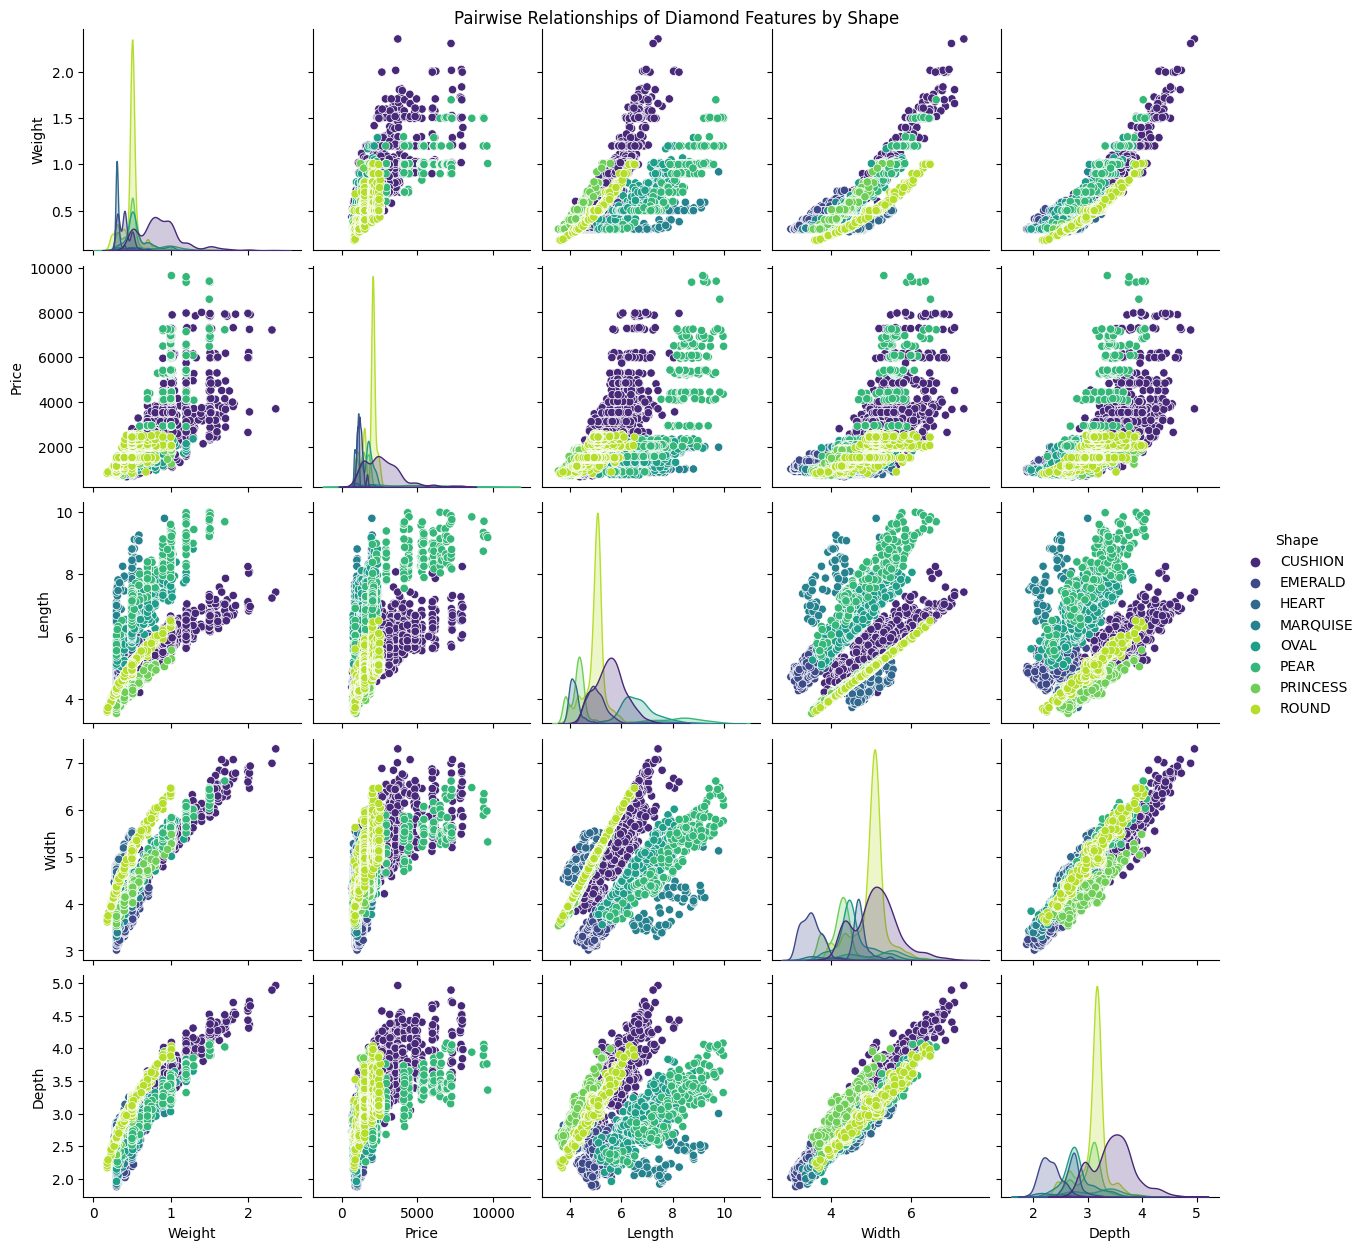

In [38]:
sns.pairplot(filtered_df, hue='Shape', palette="viridis")
plt.suptitle('Pairwise Relationships of Diamond Features by Shape', y=1)
plt.show()

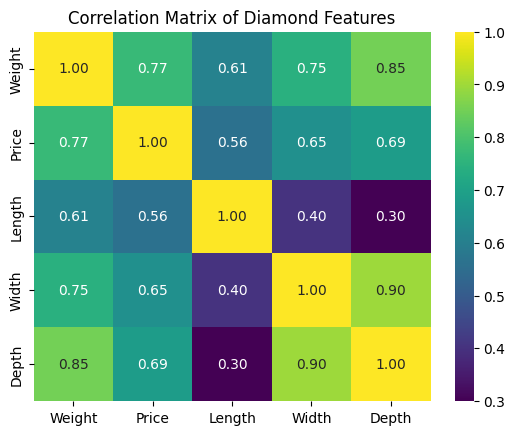

In [39]:
sns.heatmap(filtered_df.corr(numeric_only = True), annot=True, fmt=".2f", cmap="viridis")
plt.title('Correlation Matrix of Diamond Features')
plt.show()

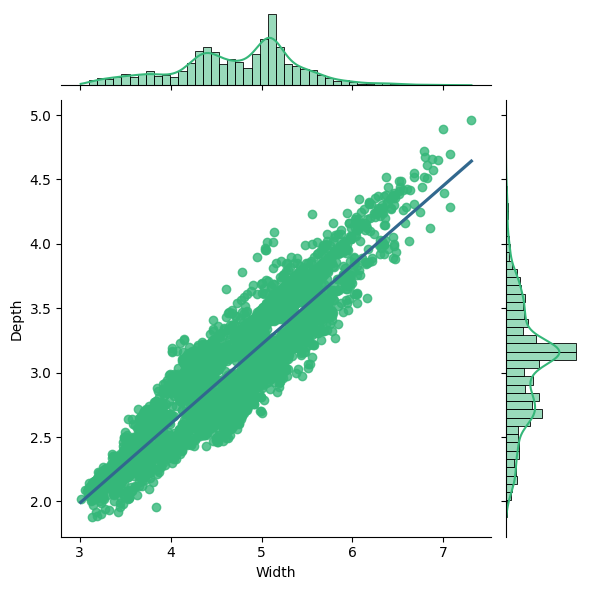

In [40]:
sns.jointplot(data=filtered_df, x="Width", y="Depth", kind="reg", joint_kws={'line_kws':{'color':'#31688e'}}, color="#35b779")
plt.show()

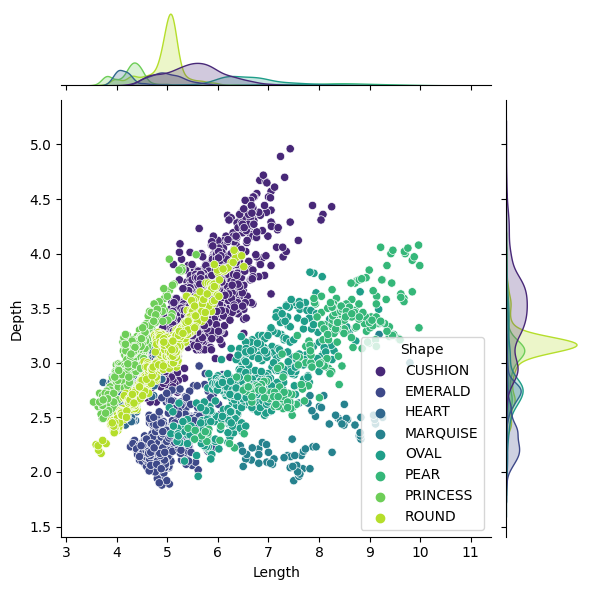

In [41]:
sns.jointplot(data=filtered_df, x="Length", y="Depth", hue='Shape', palette="viridis")
plt.show()

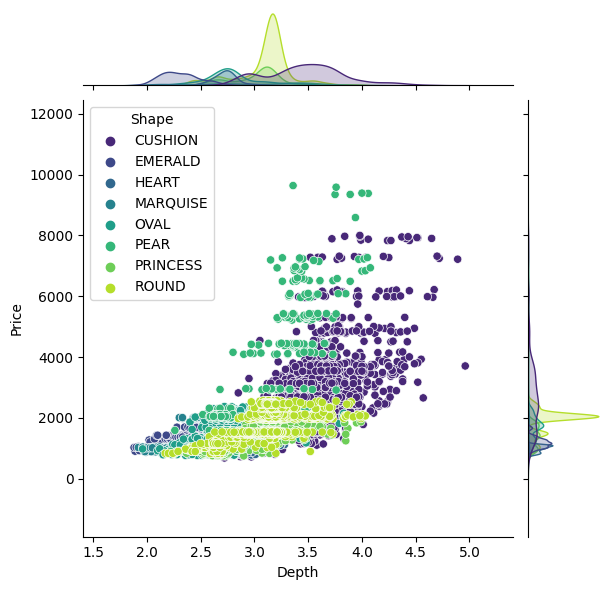

In [42]:
sns.jointplot(data=filtered_df, x="Depth", y="Price", hue='Shape', palette="viridis")
plt.show()

---

In [43]:
describe_numerical(filtered_df.select_dtypes(include=np.number))

,Weight,Price,Length,Width,Depth
count,5839.000000,5.839000e+03,5839.000000,5839.000000,5839.000000
mean,0.591566,1.990317e+03,5.355516,4.732303,3.054754
std,0.267084,1.093389e+03,1.053081,0.664008,0.455899
min,0.180054,6.832200e+02,3.539062,3.009766,1.879883
25%,0.419922,1.275855e+03,4.679688,4.328125,2.730469
50%,0.500000,1.816830e+03,5.101562,4.828125,3.109375
75%,0.709961,2.185785e+03,5.820312,5.148438,3.310547
max,2.359375,9.641690e+03,9.992188,7.308594,4.960938
var,0.071334,1.195499e+06,1.108980,0.440906,0.207844
skew,1.608836,2.470458e+00,1.302887,-0.170057,0.135855


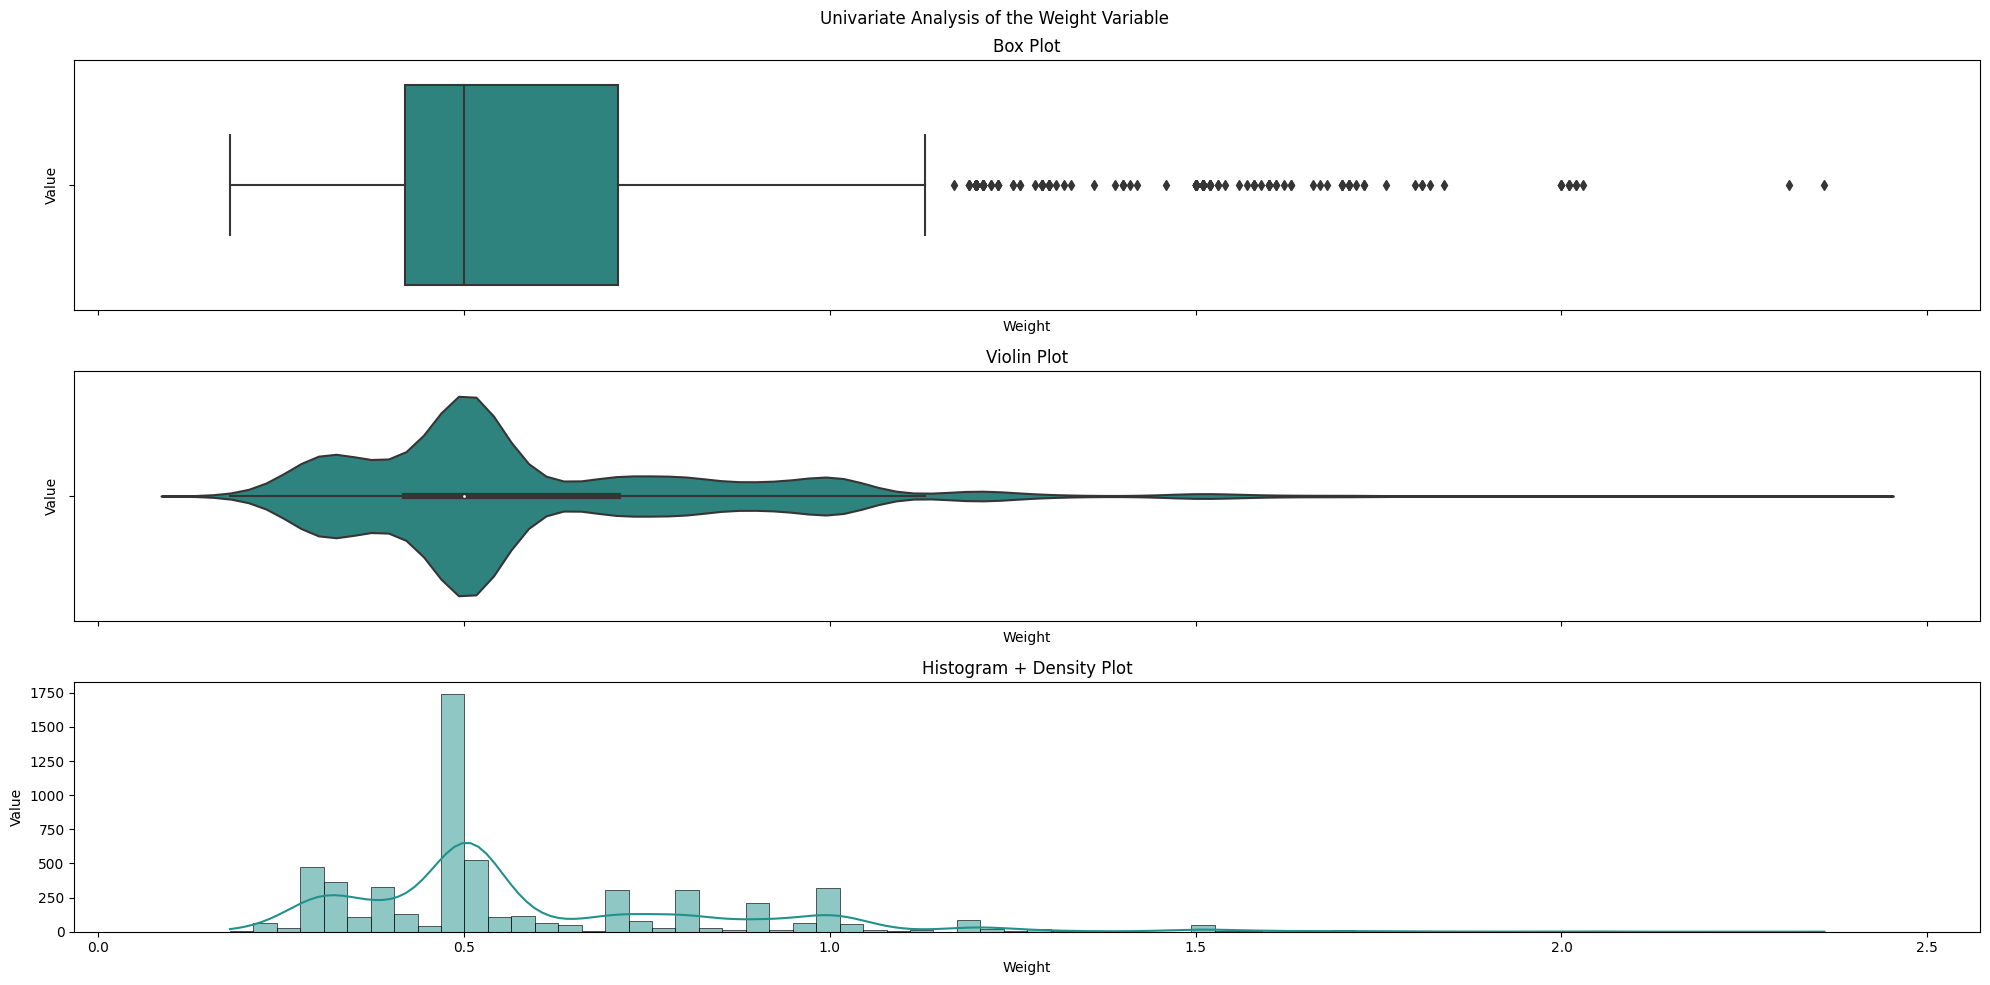

In [44]:
plot_graph_numerical(filtered_df["Weight"])

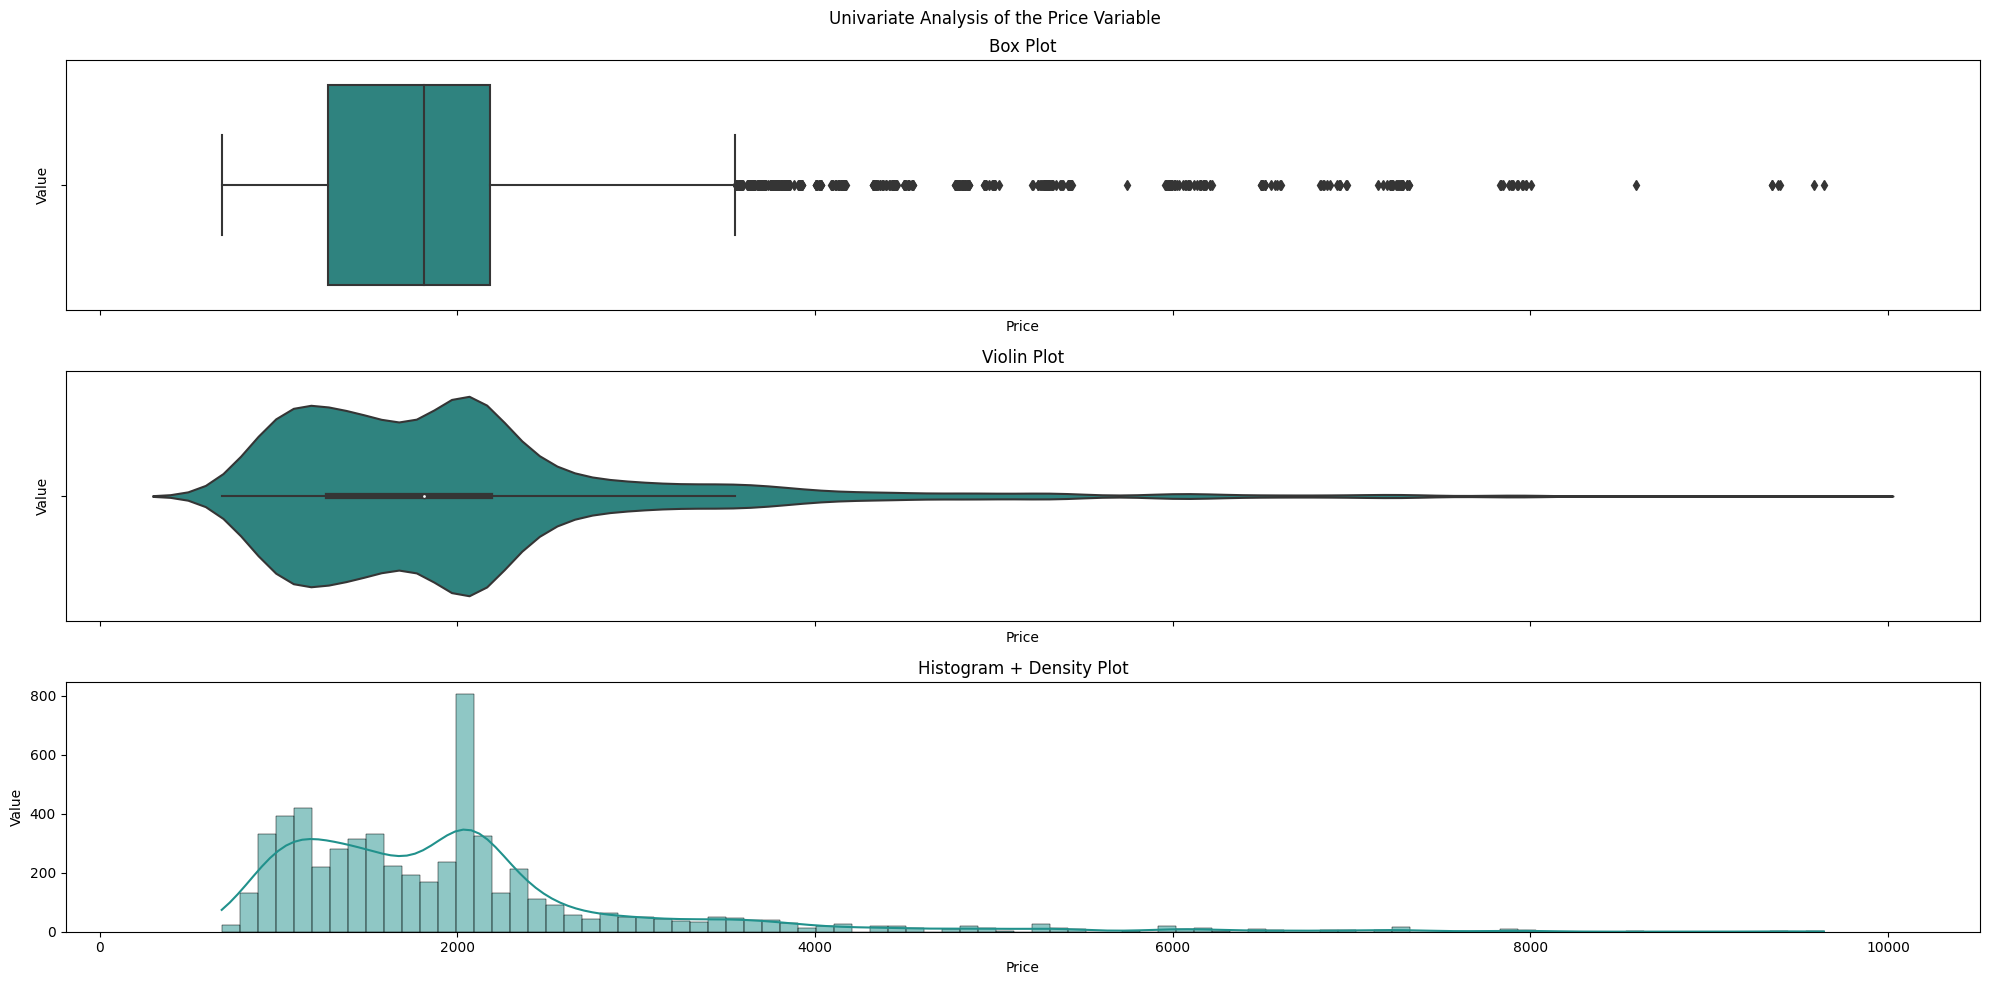

In [45]:
plot_graph_numerical(filtered_df["Price"])

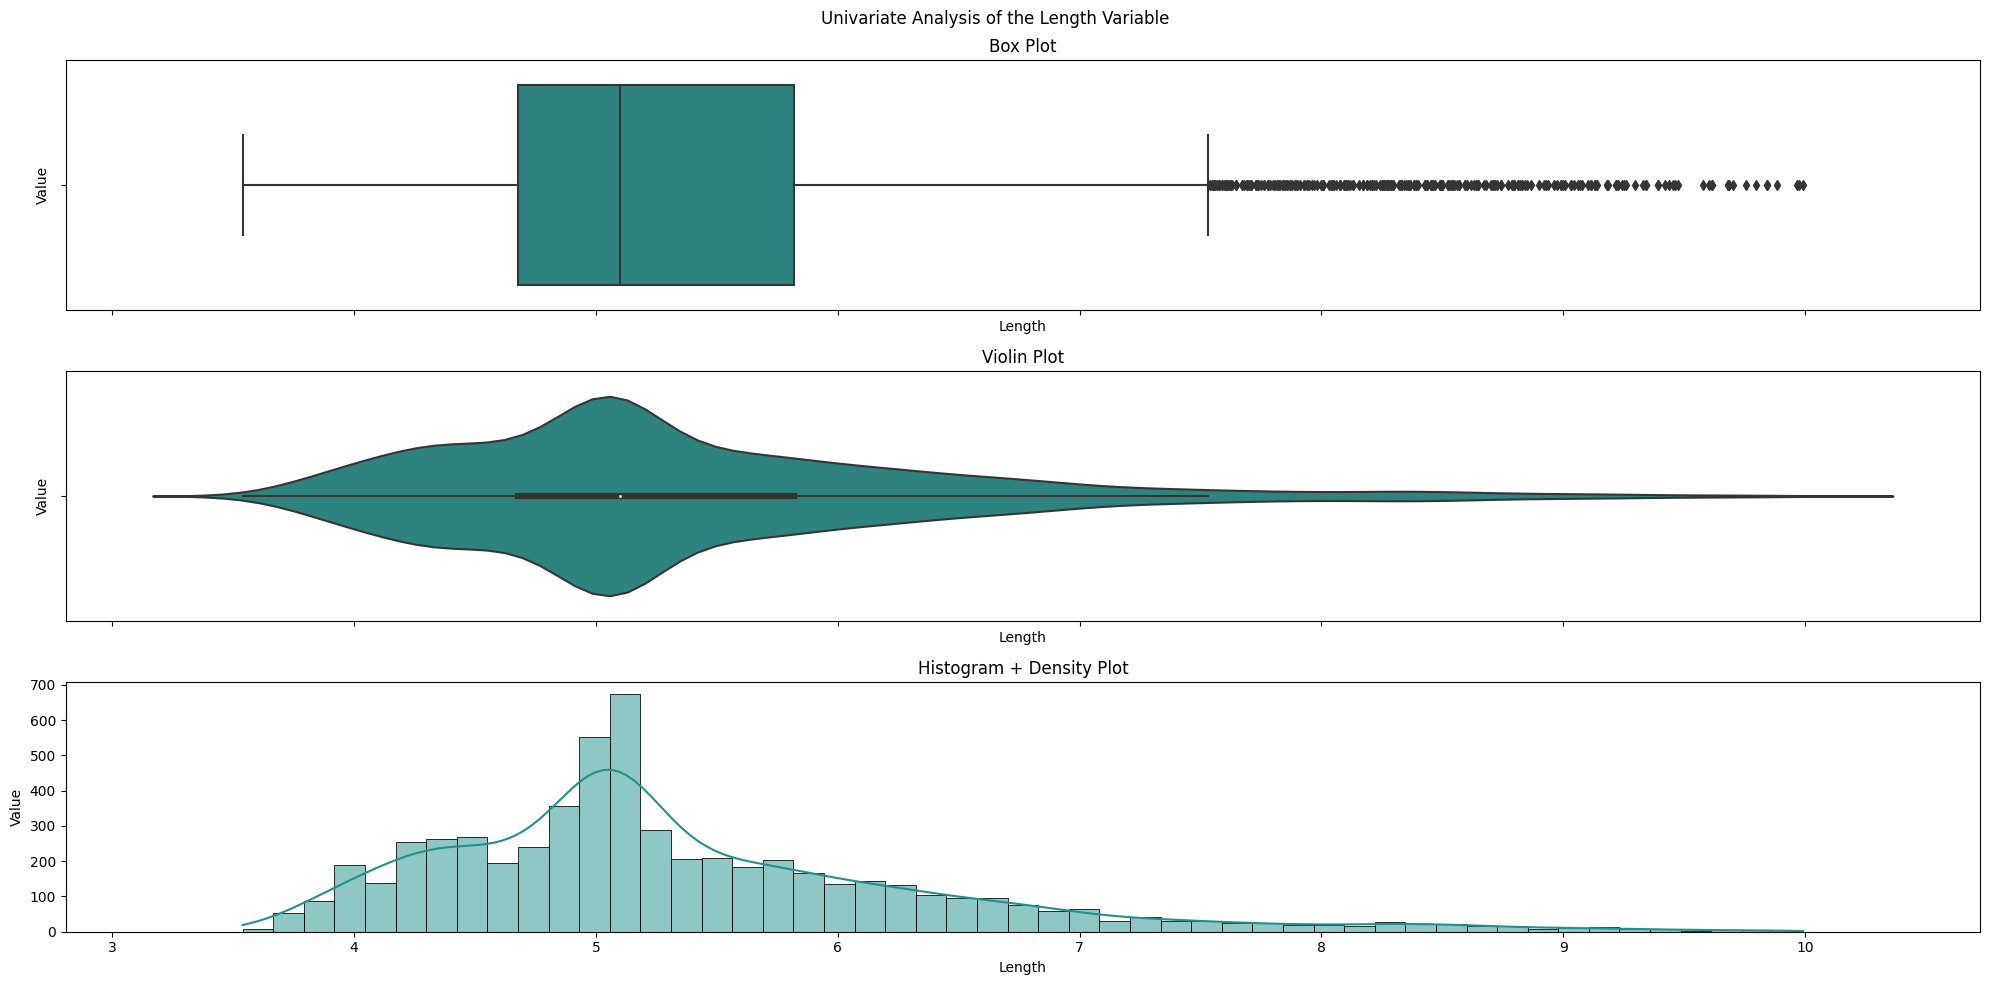

In [46]:
plot_graph_numerical(filtered_df["Length"])

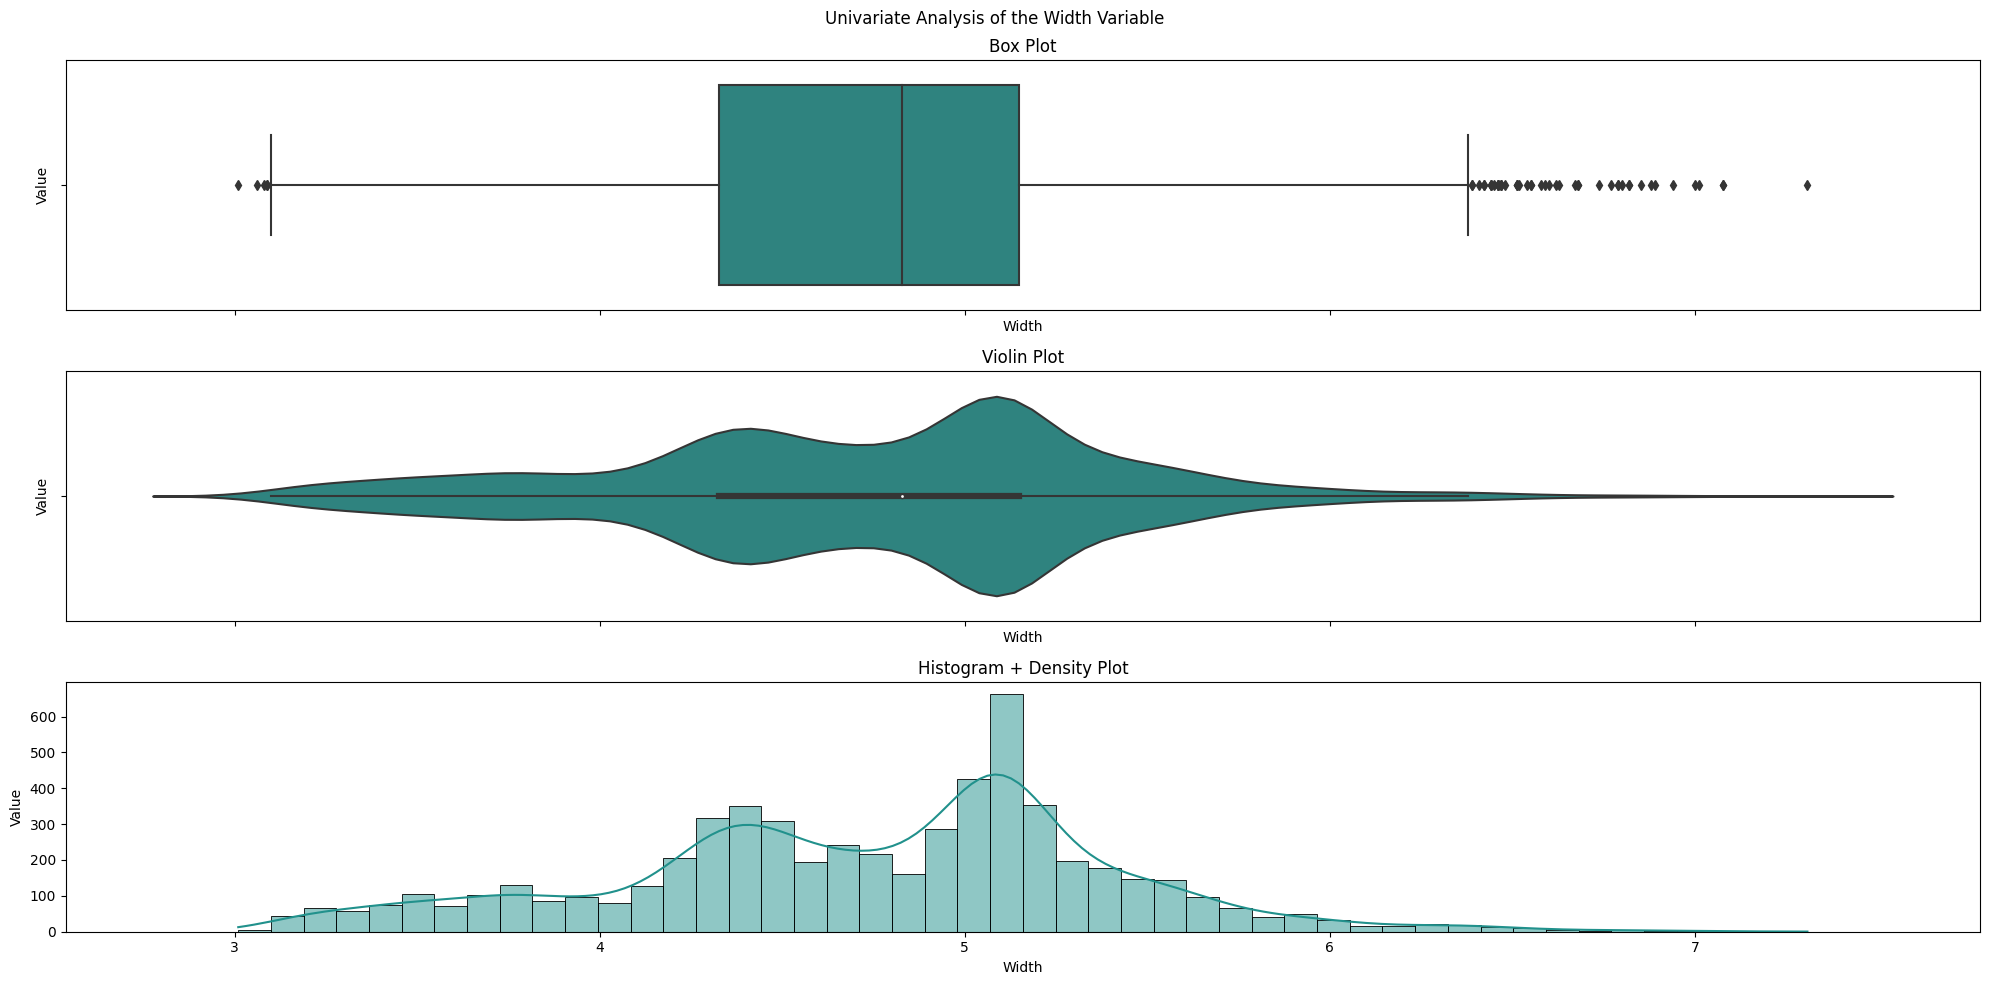

In [47]:
plot_graph_numerical(filtered_df["Width"])

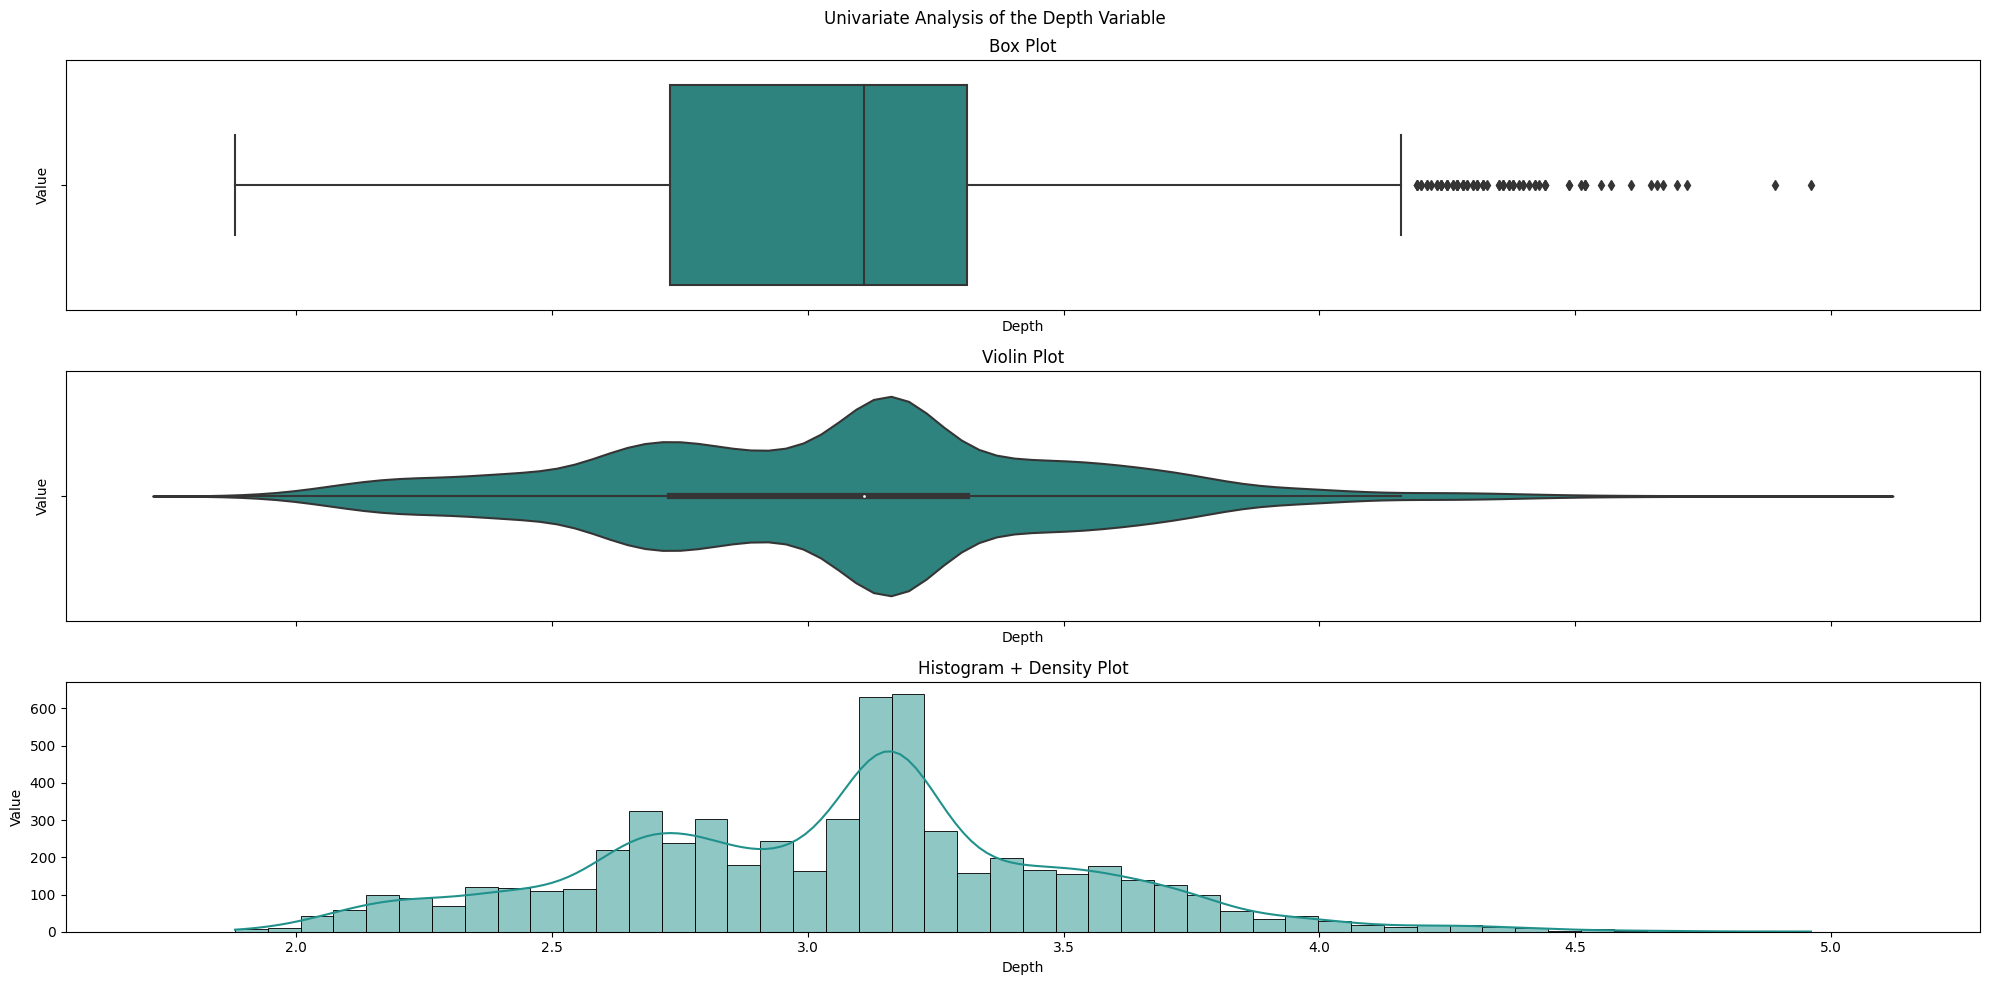

In [48]:
plot_graph_numerical(filtered_df["Depth"])

In [49]:
describe_categorical(filtered_df)

Empty DataFrame
Columns: []
Index: [(Clarity, FL, 0, 0.0), (Clarity, I1, 37, 0.6336701489981161), (Clarity, I2, 6, 0.10275732145915396), (Clarity, I3, 1, 0.017126220243192325), (Clarity, IF, 77, 1.318718958725809), (Clarity, SI1, 1387, 23.754067477307757), (Clarity, SI2, 960, 16.441171433464635), (Clarity, VS1, 1082, 18.5305703031341), (Clarity, VS2, 1277, 21.8701832505566), (Clarity, VVS1, 427, 7.312896043843124), (Clarity, VVS2, 585, 10.018838842267511), (Colour, D, 725, 12.416509676314437), (Colour, E, 892, 15.276588456927556), (Colour, F, 900, 15.413598218873096), (Colour, FANCY, 234, 4.007535536907005), (Colour, G, 684, 11.714334646343552), (Colour, H, 544, 9.316663812296627), (Colour, I, 641, 10.977907175886283), (Colour, J, 505, 8.648741222812125), (Colour, K, 303, 5.189244733687275), (Colour, L, 167, 2.8600787806131187), (Colour, M, 86, 1.4728549409145402), (Colour, N, 45, 0.7706799109436547), (Colour, O, 1, 0.017126220243192325), (Colour, O-P, 12, 0.20551464291830793), (Colour, Q-R, 6, 0.10275732145915396), (Colour, S-T, 15, 0.25689330364788493), (Colour, U-V, 34, 0.5822914882685392), (Colour, W, 1, 0.017126220243192325), (Colour, W-X, 32, 0.5480390477821544), (Colour, Y-Z, 12, 0.20551464291830793), (Cut, EX, 4273, 73.18033909916082), (Cut, F, 17, 0.2911457441342696), (Cut, GD, 301, 5.15499229320089), (Cut, VG, 1248, 21.373522863504025), (Fluorescence, F, 1091, 18.68470628532283), (Fluorescence, M, 434, 7.43277958554547), (Fluorescence, N, 4054, 69.42969686590169), (Fluorescence, SL, 3, 0.05137866072957698), (Fluorescence, ST, 232, 3.97328309642062), (Fluorescence, VS, 17, 0.2911457441342696), (Fluorescence, VSL, 8, 0.1370097619455386), (Polish, EX, 4650, 79.63692413084432), (Polish, F, 1, 0.017126220243192325), (Polish, GD, 63, 1.0789518753211167), (Polish, VG, 1125, 19.266997773591367), (Shape, CUSHION, 1579, 27.042301764000687), (Shape, EMERALD, 550, 9.41942113375578), (Shape, HEART, 345, 5.908545983901353), (Shape, MARQUISE, 68, 1.1645829765370783), (Shape, OVAL, 678, 11.611577324884397), (Shape, PEAR, 234, 4.007535536907005), (Shape, PRINCESS, 624, 10.686761431752013), (Shape, ROUND, 1761, 30.159273848261687), (Symmetry, EX, 1605, 27.487583490323686), (Symmetry, FR, 54, 0.9248158931323858), (Symmetry, GD, 1055, 18.068162356567903), (Symmetry, VG, 3125, 53.51943825997603)]

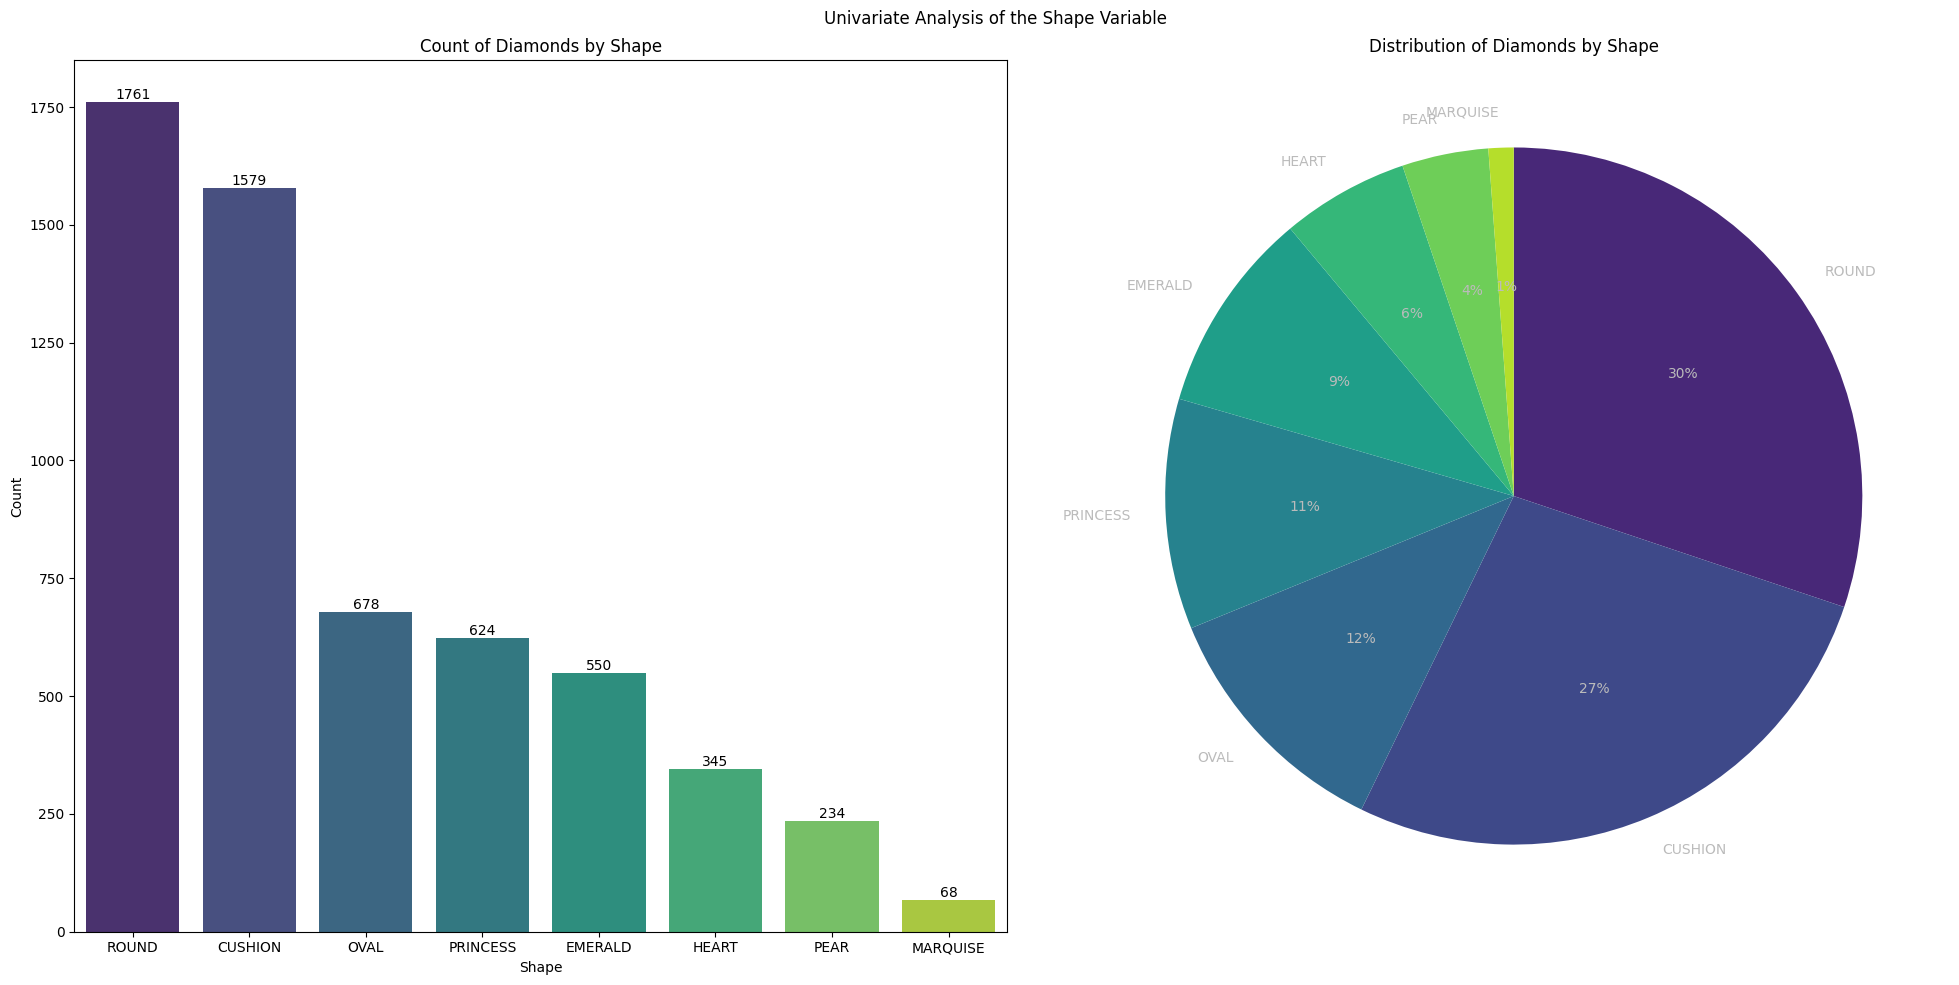

In [50]:
plot_graph_categorical(filtered_df['Shape'])

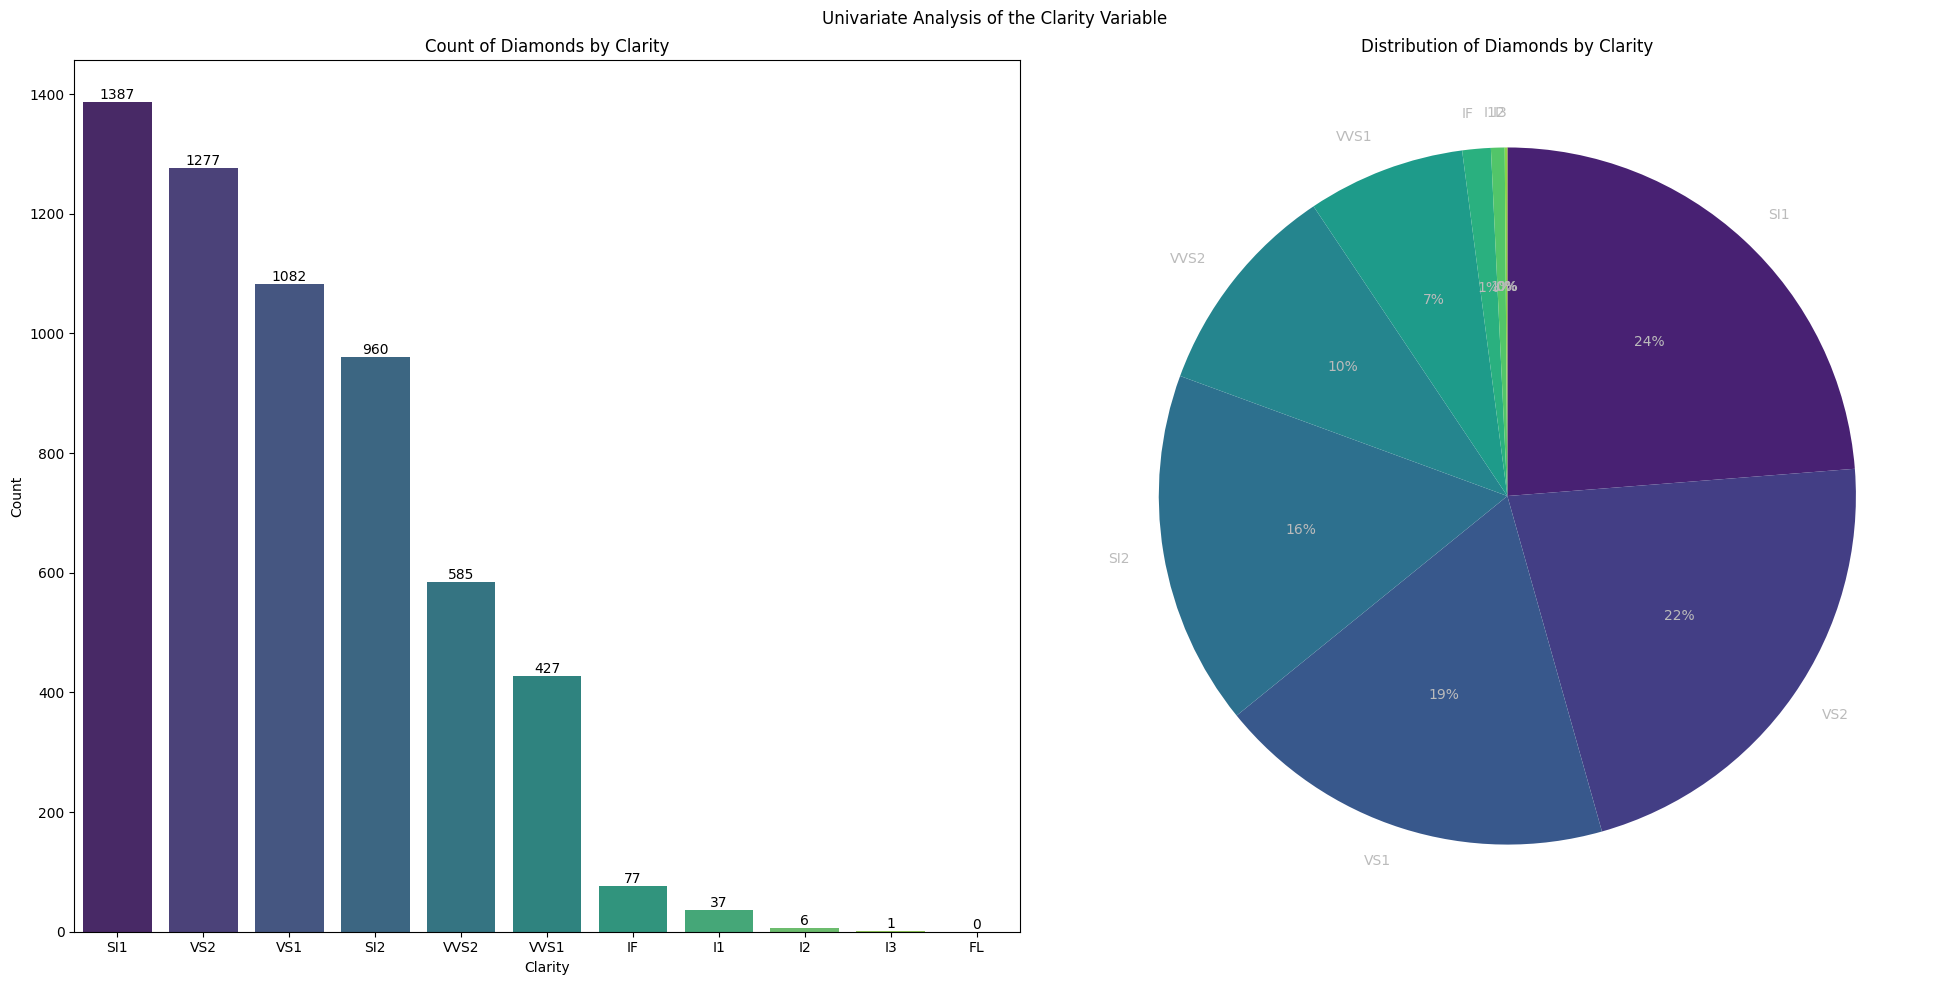

In [51]:
plot_graph_categorical(filtered_df['Clarity'])

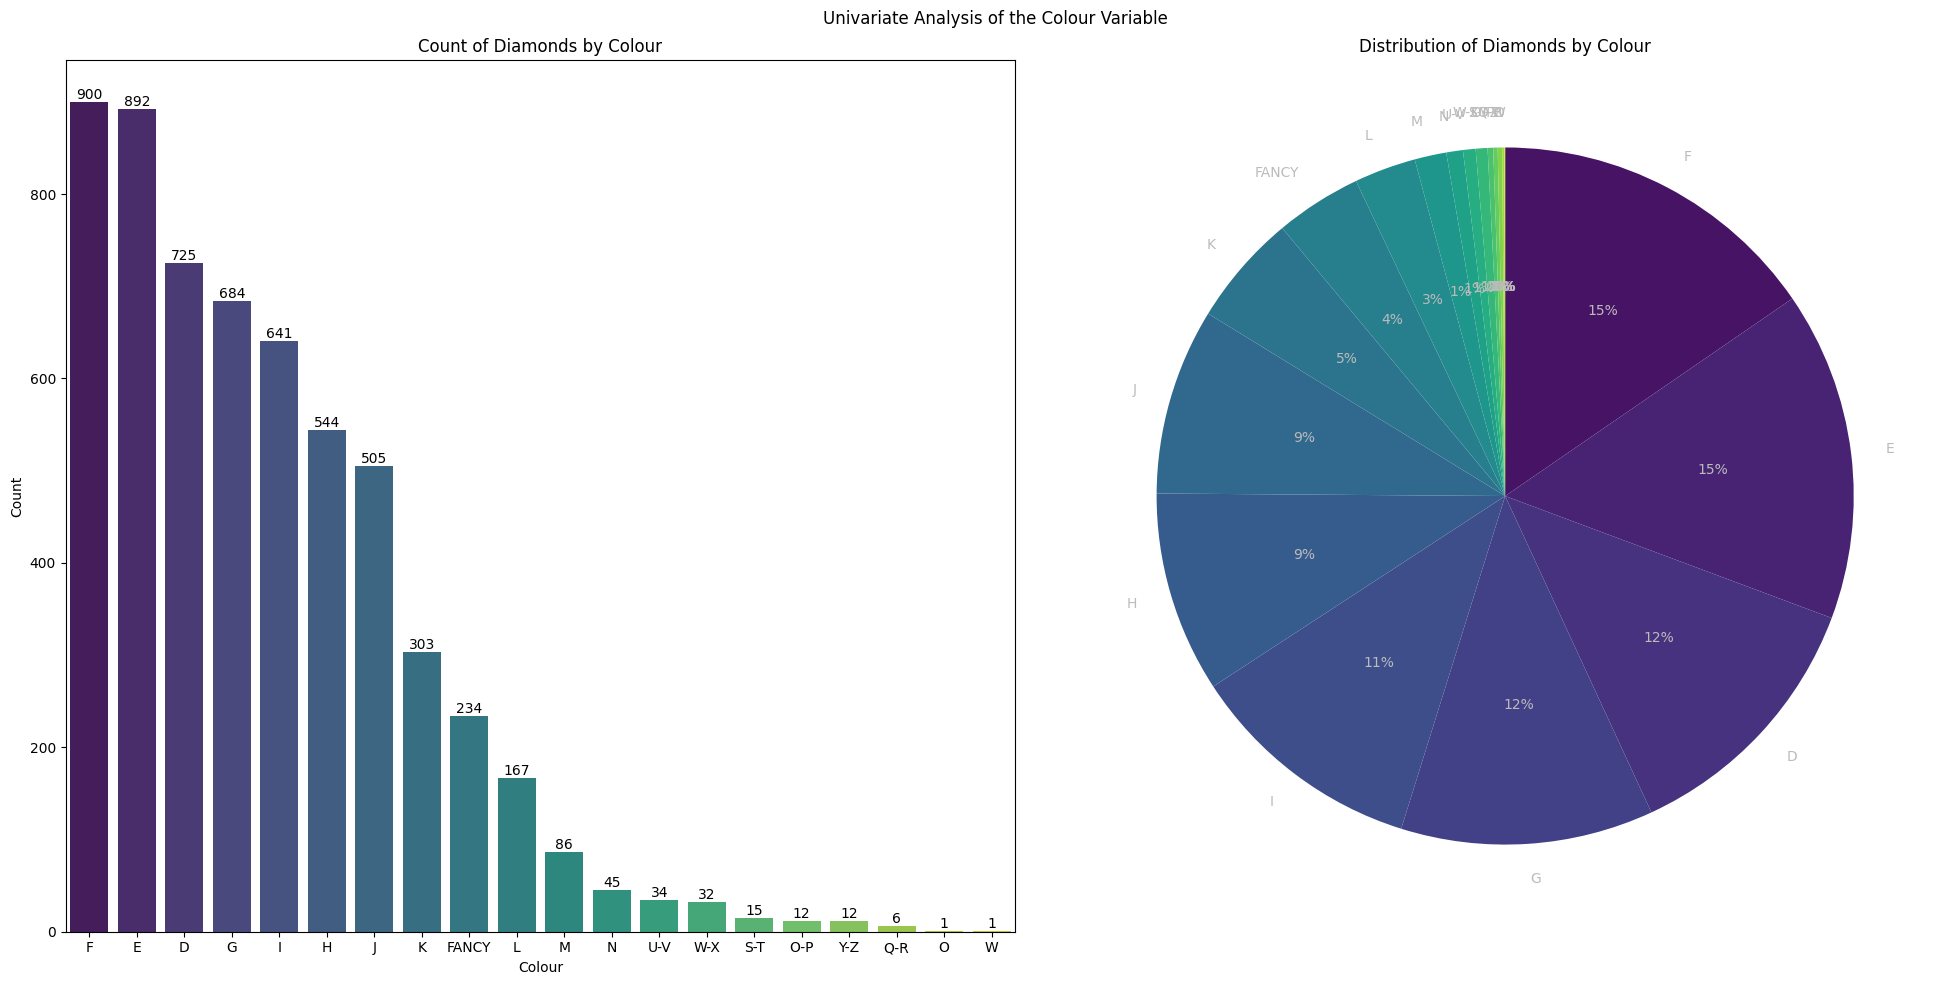

In [52]:
plot_graph_categorical(filtered_df['Colour'])

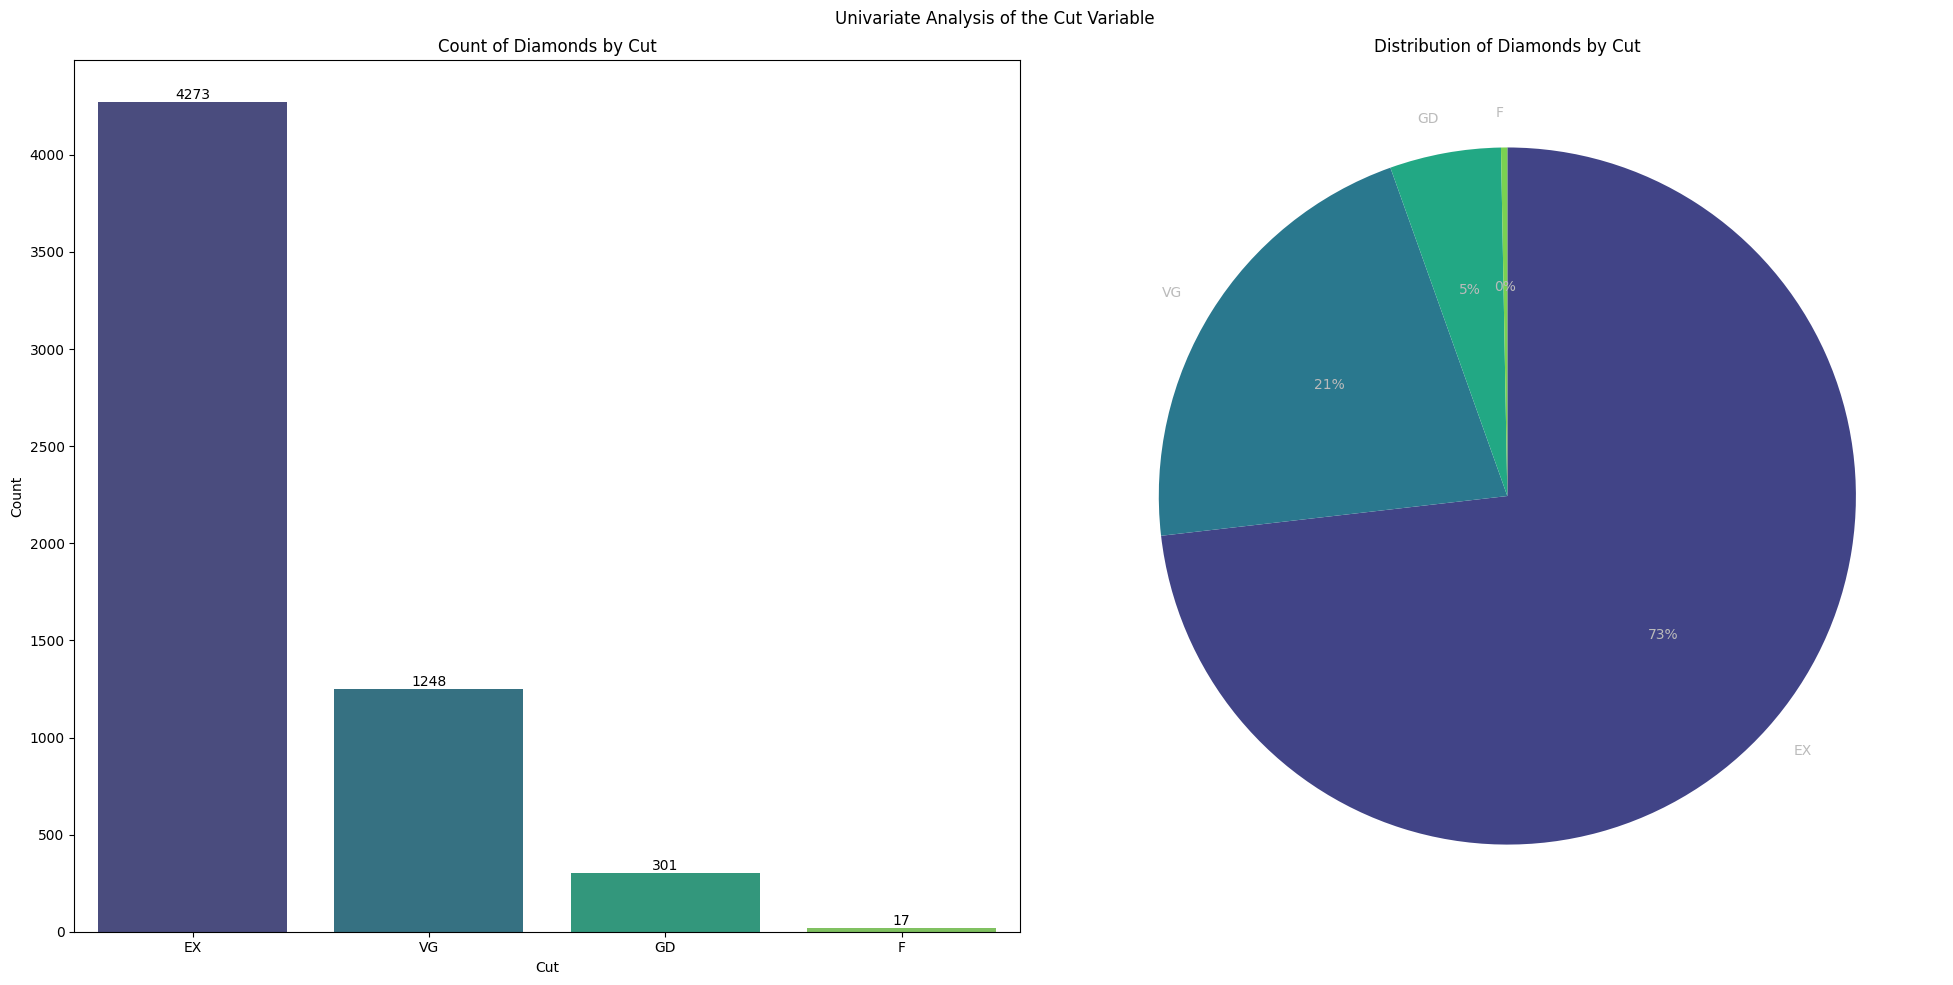

In [53]:
plot_graph_categorical(filtered_df['Cut'])

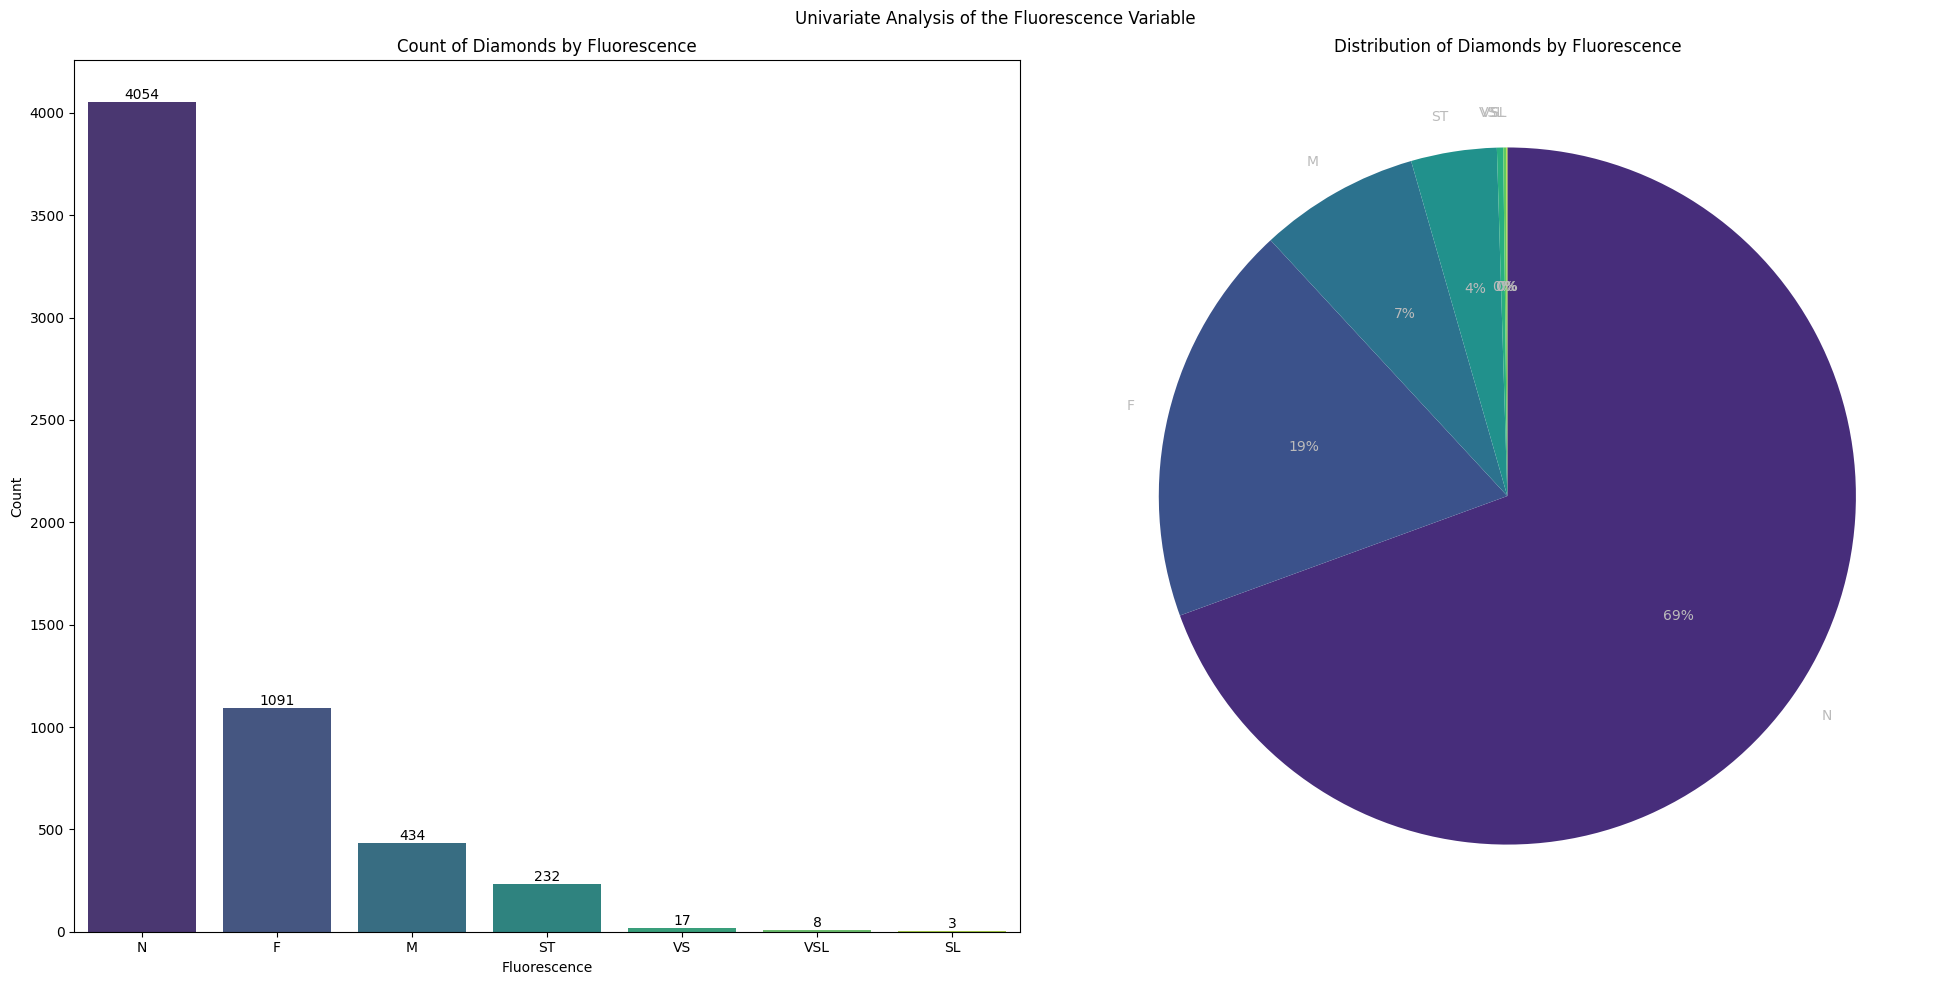

In [54]:
plot_graph_categorical(filtered_df['Fluorescence'])

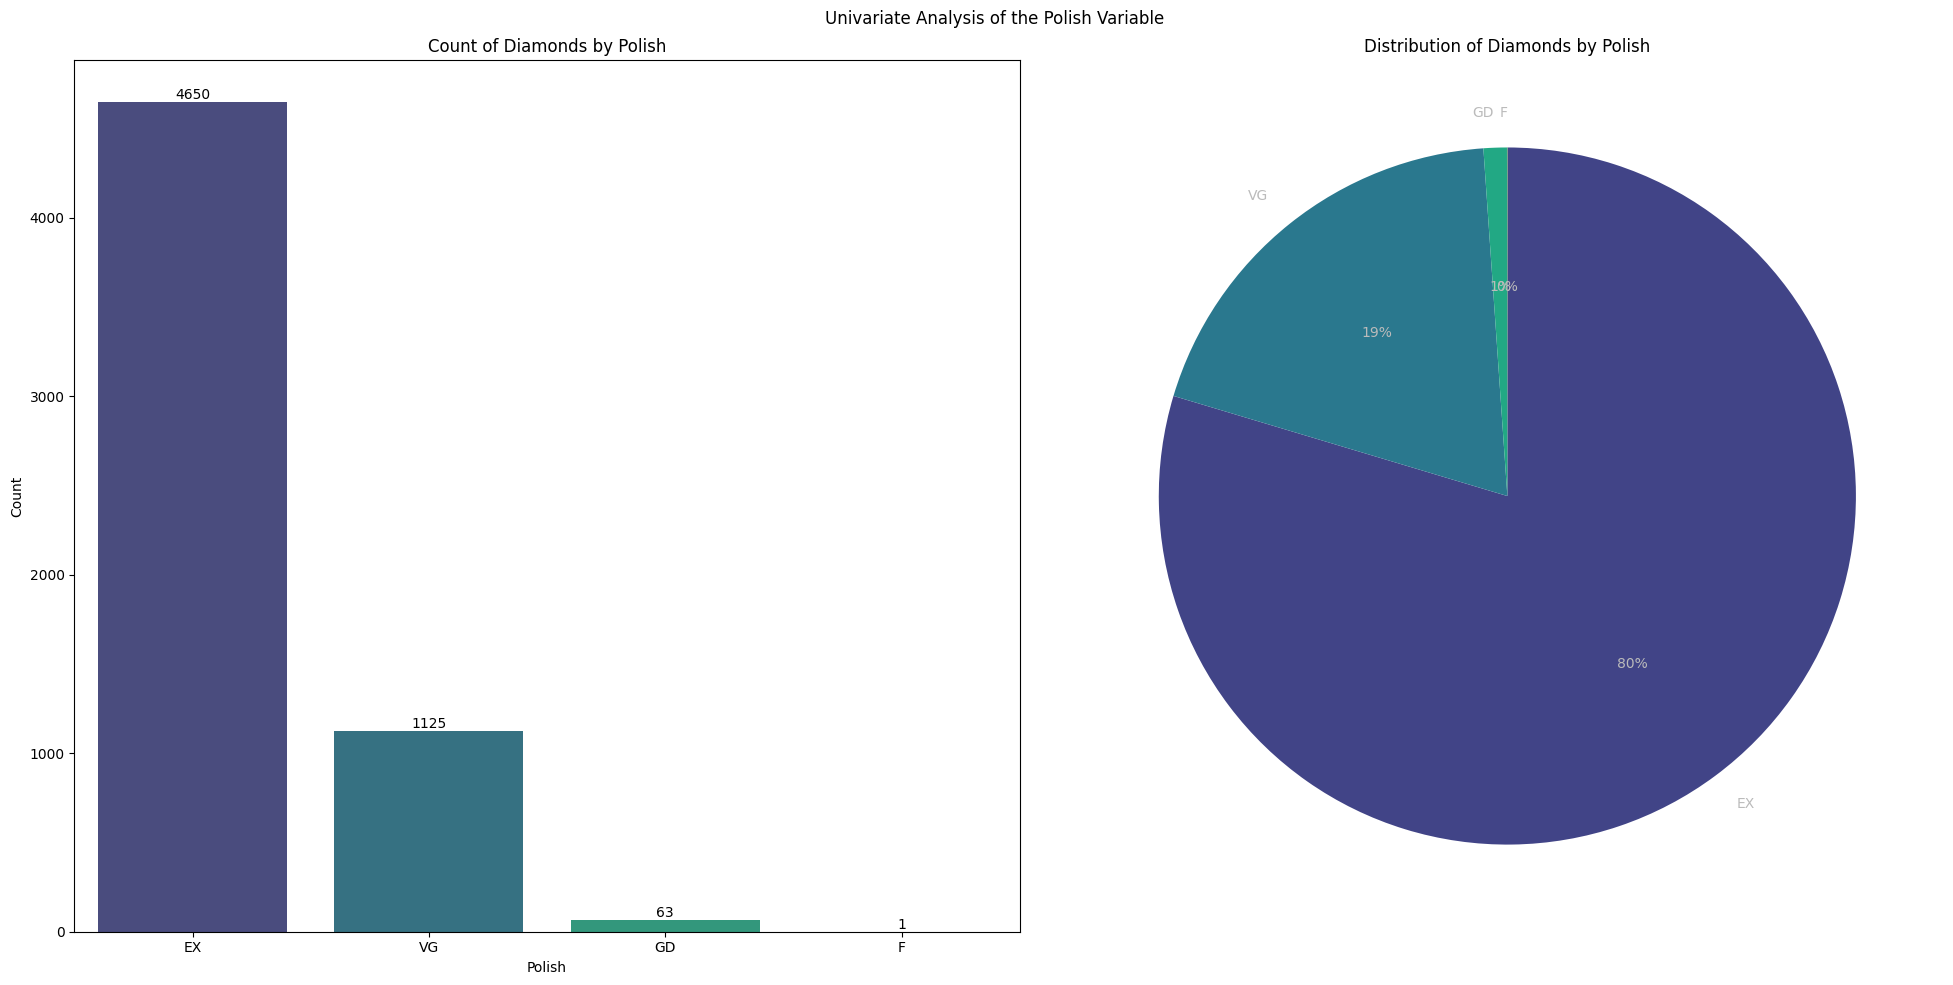

In [55]:
plot_graph_categorical(filtered_df['Polish'])

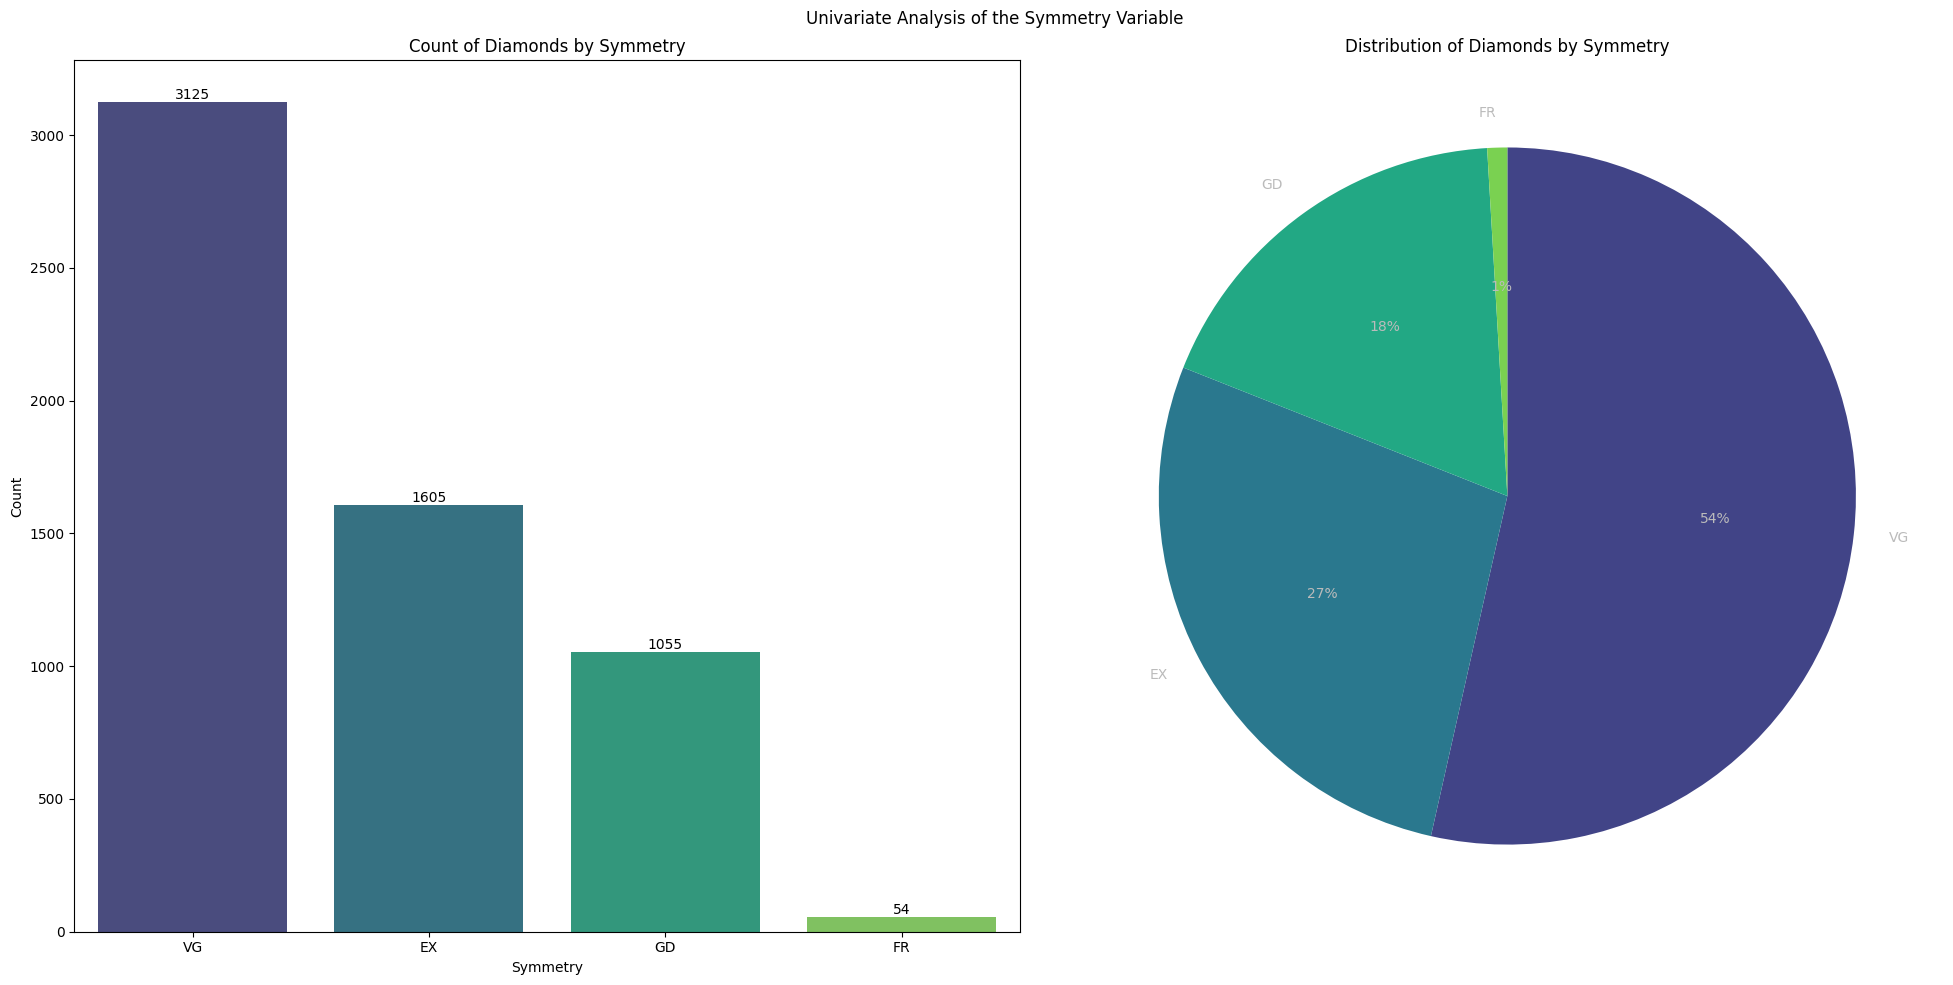

In [56]:
plot_graph_categorical(filtered_df['Symmetry'])

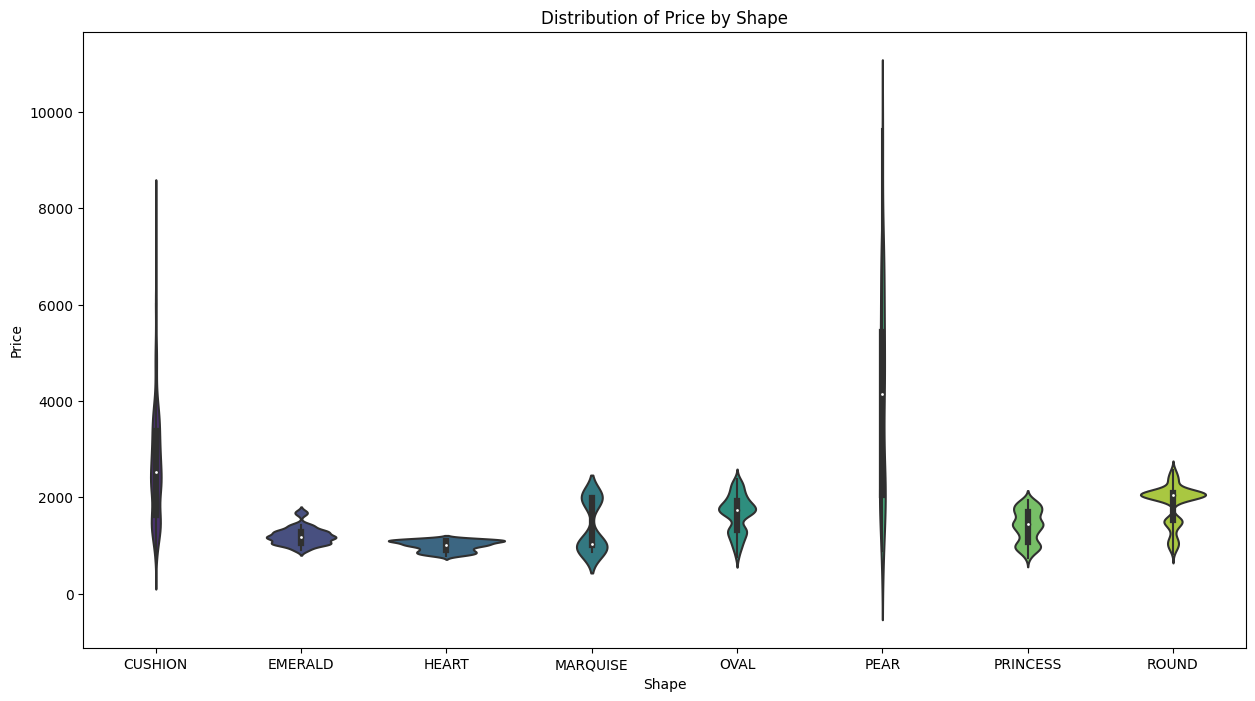

In [57]:
groupby_violinplot(filtered_df, "Shape", "Price")

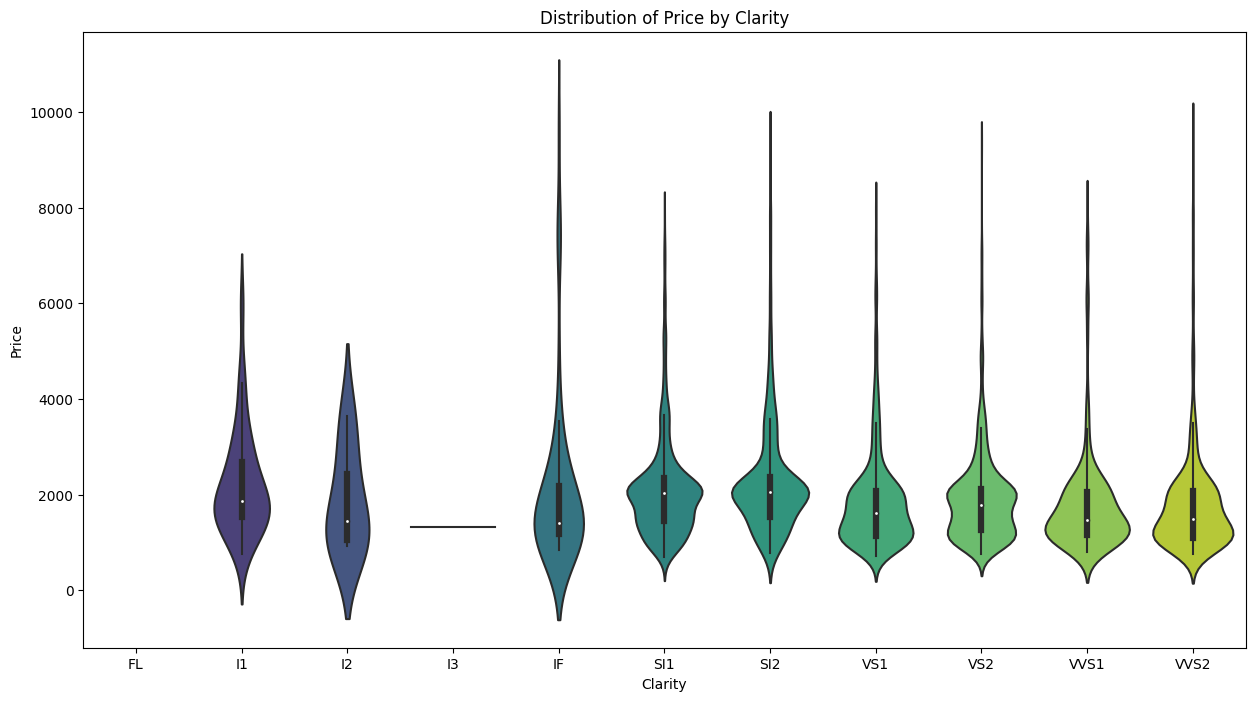

In [58]:
groupby_violinplot(filtered_df, "Clarity", "Price")

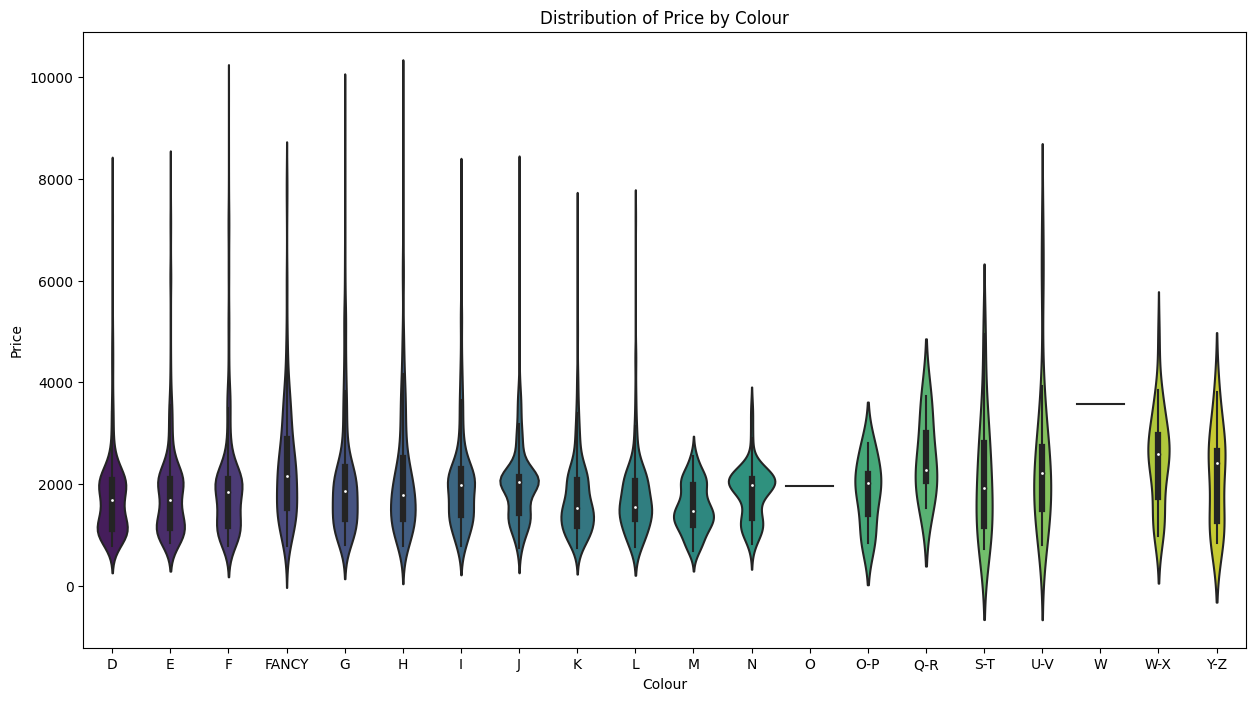

In [59]:
groupby_violinplot(filtered_df, "Colour", "Price")

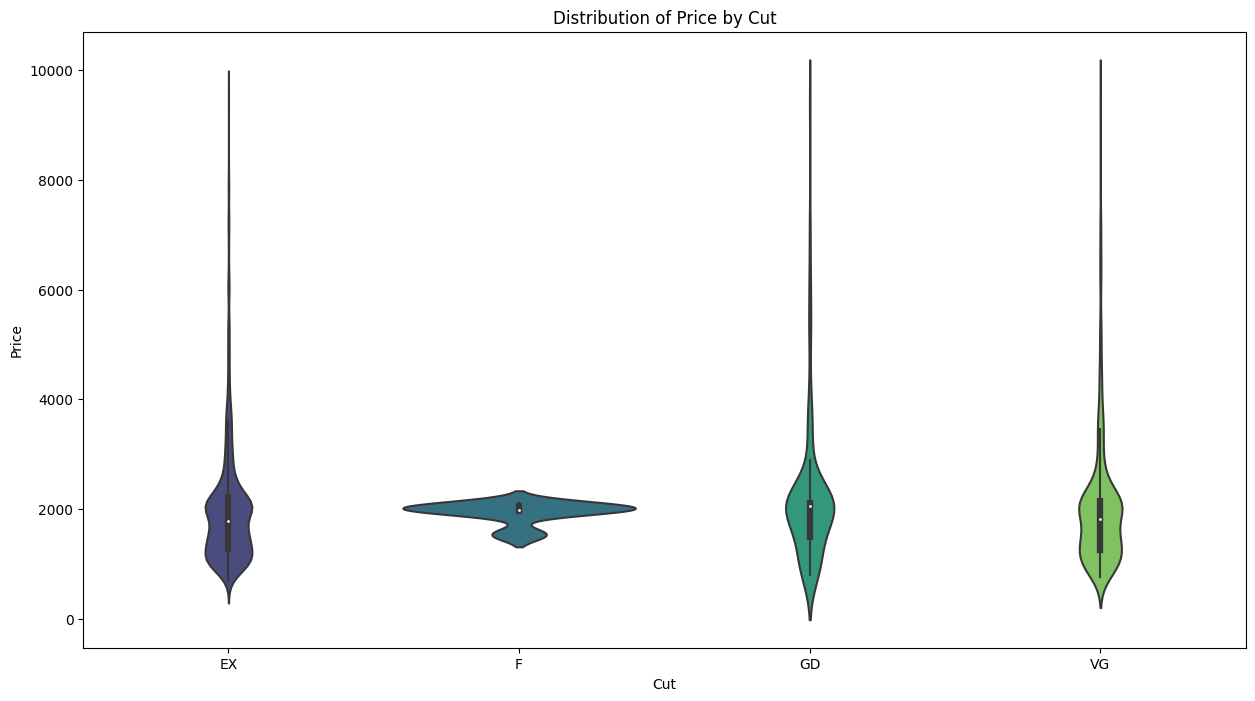

In [60]:
groupby_violinplot(filtered_df, "Cut", "Price")

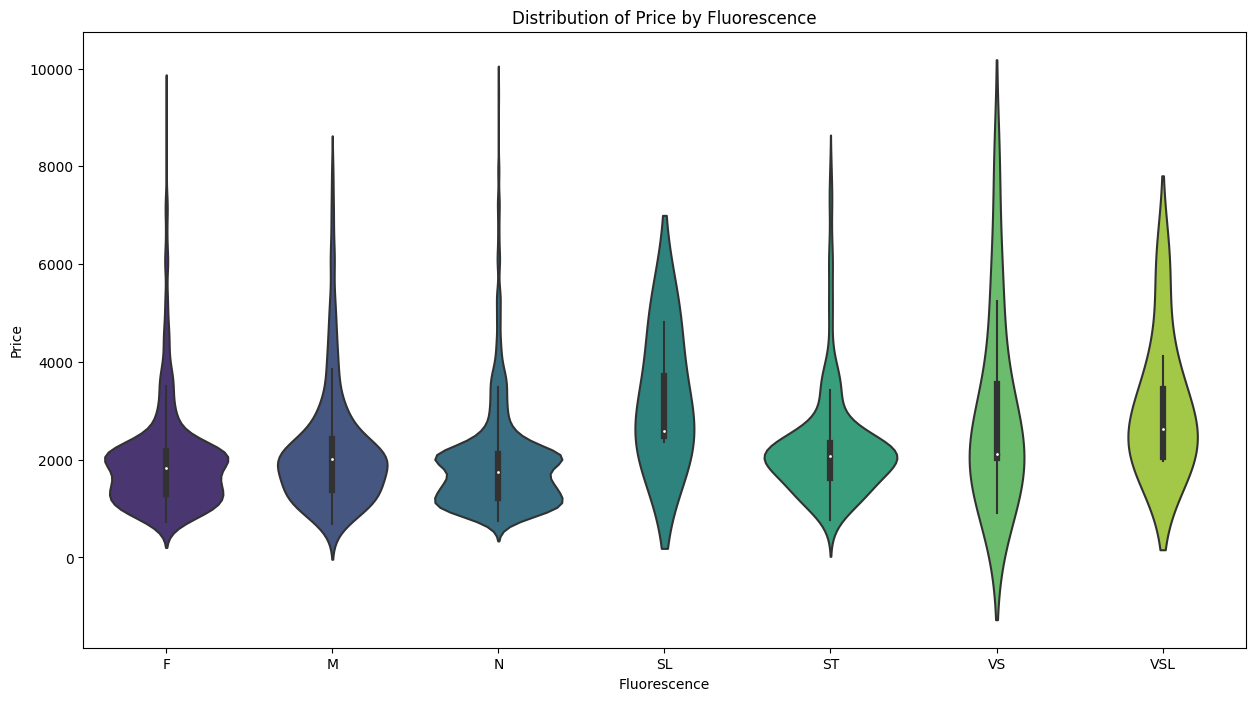

In [61]:
groupby_violinplot(filtered_df, "Fluorescence", "Price")

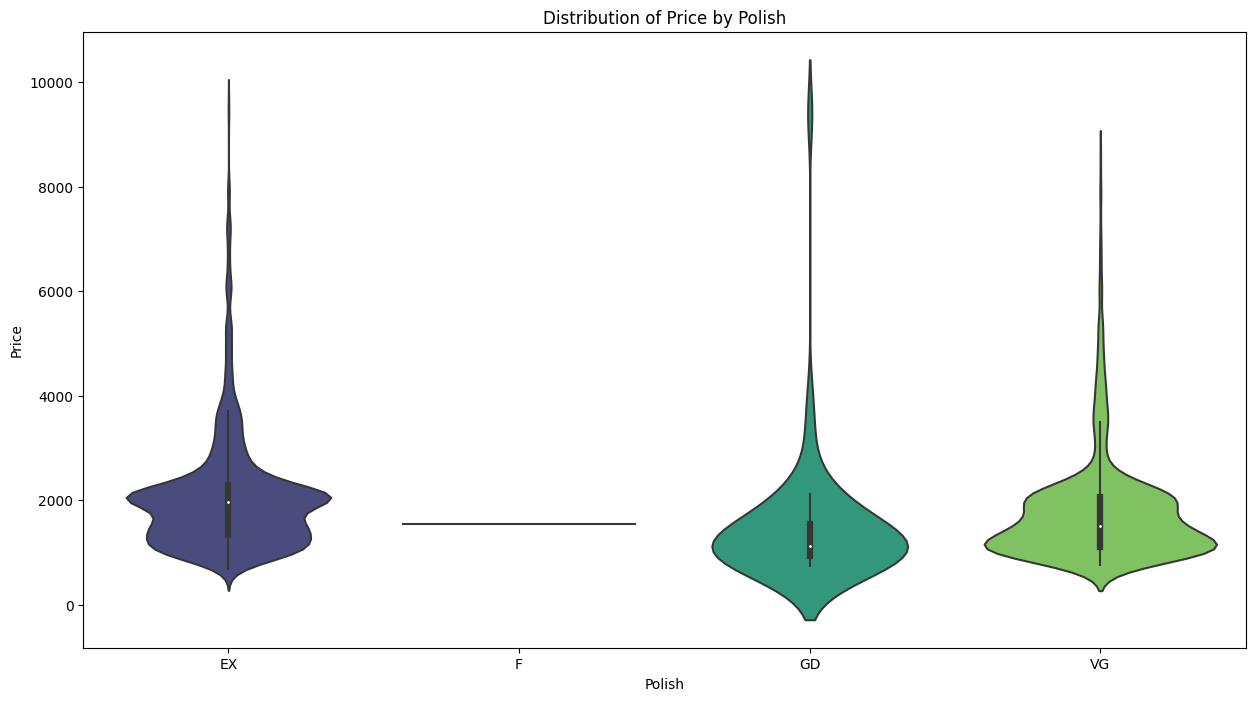

In [62]:
groupby_violinplot(filtered_df, "Polish", "Price")

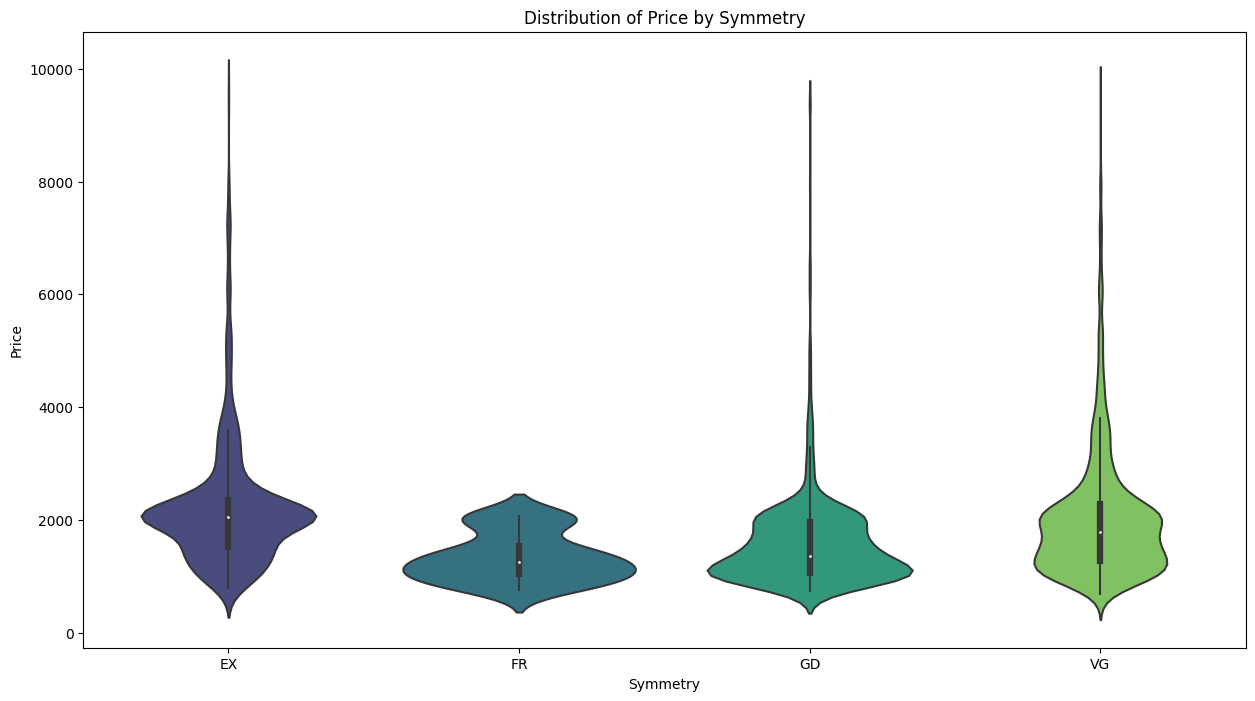

In [63]:
groupby_violinplot(filtered_df, "Symmetry", "Price")

In [64]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5839 entries, 0 to 6338
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Id            5839 non-null   object  
 1   Shape         5839 non-null   category
 2   Weight        5839 non-null   float32 
 3   Clarity       5839 non-null   category
 4   Colour        5839 non-null   category
 5   Cut           5839 non-null   category
 6   Polish        5839 non-null   category
 7   Symmetry      5839 non-null   category
 8   Fluorescence  5839 non-null   category
 9   Price         5839 non-null   float32 
 10  Length        5839 non-null   float32 
 11  Width         5839 non-null   float32 
 12  Depth         5839 non-null   float32 
dtypes: category(7), float32(5), object(1)
memory usage: 247.6+ KB
